# Temporal Dataset Exploration for Time-Aware Recommendation

Notebook này khám phá ba nhóm dataset temporal/recommender-system: MovieLens, Amazon review sample và CASAS smart-home sensor events. Mục tiêu là đánh giá liệu mỗi dataset có đủ `entity/user`, `item/event`, `timestamp` để tạo supervised targets như `next_item`, `next_time`, `delta_time`, và `time_bucket` hay không.

Refactor này giữ logic phân tích chính, nhưng chia output thành nhiều cell nhỏ để đọc và chạy lại dễ hơn.

## 1. Objective and Research Questions

Phần này cố định câu hỏi nghiên cứu trước khi đọc dữ liệu. Với MovieLens/Amazon, ta xem mỗi user như một chuỗi interaction và hỏi liệu có thể học từ lịch sử `X` để dự đoán item kế tiếp và thời điểm kế tiếp. Với CASAS, ta xem sensor stream như chuỗi event-time, không diễn giải trực tiếp thành user-item recommender benchmark.

Câu hỏi chính:

- Dataset có đủ `user/entity`, `item/event`, `timestamp` không?
- Sequence mỗi entity có đủ dài để tạo `next_item`, `next_time`, `delta_time`, `time_bucket` không?
- Dataset nào phù hợp nhất cho time-aware recommender system, và dataset nào chỉ nên dùng như dữ liệu tham khảo cho event-time prediction?

## 2. Imports and Global Settings

Cell này chỉ import thư viện và cấu hình display. Một số optional dependency của pandas có thể lỗi binary trong môi trường cục bộ, nên notebook chủ động block chúng để pandas dùng fallback an toàn.

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Any, Callable, Iterable
import contextlib
import importlib.abc
import io
import os
import sys
import warnings


class BlockBrokenOptionalPandasDeps(importlib.abc.MetaPathFinder):
    """Treat optional pandas binary deps as unavailable if the local install is incompatible."""
    blocked = {"pyarrow", "bottleneck"}

    def find_spec(self, fullname: str, path: object = None, target: object = None) -> object:
        if fullname.split(".")[0] in self.blocked:
            raise ImportError(f"Blocked optional pandas dependency {fullname}")
        return None


os.environ["PANDAS_USE_BOTTLENECK"] = "0"
if not any(isinstance(finder, BlockBrokenOptionalPandasDeps) for finder in sys.meta_path):
    sys.meta_path.insert(0, BlockBrokenOptionalPandasDeps())

import numpy as np
import pandas as pd
from IPython.display import Markdown, display

try:
    with contextlib.redirect_stderr(io.StringIO()):
        import matplotlib.pyplot as plt
    PLOTTING_AVAILABLE = True
except Exception as exc:
    plt = None
    PLOTTING_AVAILABLE = False
    print(f"[WARN] matplotlib could not be imported; plot cells will be skipped. Reason: {exc}")

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
pd.set_option("display.max_rows", 30)

RANDOM_STATE = 42

## 3. Utility Functions

Các helper dưới đây giữ logic phân tích lặp lại: tóm tắt schema, parse timestamp, đo sequence feasibility, tạo target next-event, bucket hóa delta-time và báo cáo temporal split. Helper trả về bảng/dict để cell phía dưới quyết định hiển thị gì, tránh một hàm tự in quá nhiều output.

In [2]:
def find_project_root(start: str | Path | None = None) -> Path:
    """Find project root by walking upward until data/raw and notebooks or .git are found."""
    current = Path(start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "data" / "raw").exists() and ((candidate / "notebooks").exists() or (candidate / ".git").exists()):
            return candidate
    raise FileNotFoundError(f"Cannot find project root from {current}")


def safe_read_file(path: str | Path, reader: Callable[..., pd.DataFrame], *args: Any, dataset_name: str | None = None, **kwargs: Any) -> pd.DataFrame | None:
    """Read one file defensively and return None instead of stopping the notebook."""
    path = Path(path)
    label = dataset_name or path.name
    if not path.exists():
        print(f"[MISSING] {label}: {path}")
        return None
    try:
        df = reader(path, *args, **kwargs)
        print(f"[OK] {label}: {len(df):,} rows, {len(df.columns):,} columns")
        return df
    except Exception as exc:
        print(f"[ERROR] {label}: {exc}")
        return None


def summarize_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """Return compact schema, missingness, cardinality, and one example value per column."""
    rows: list[dict[str, Any]] = []
    for column in df.columns:
        series = df[column]
        non_null = series.dropna()
        # Keep schema output report-friendly instead of printing raw rows.
        rows.append({
            "column": column,
            "dtype": str(series.dtype),
            "missing": int(series.isna().sum()),
            "missing_pct": round(float(series.isna().mean() * 100), 3),
            "n_unique": int(series.nunique(dropna=True)),
            "example_value": non_null.iloc[0] if not non_null.empty else np.nan,
        })
    return pd.DataFrame(rows, columns=["column", "dtype", "missing", "missing_pct", "n_unique", "example_value"])


def infer_unix_unit(values: pd.Series) -> str:
    """Infer seconds/ms/us/ns for numeric Unix timestamps."""
    x = pd.to_numeric(values, errors="coerce").dropna().abs()
    if x.empty:
        return "s"
    median_value = x.median()
    if median_value >= 1e17:
        return "ns"
    if median_value >= 1e14:
        return "us"
    if median_value >= 1e11:
        return "ms"
    return "s"


def analyze_timestamp(df: pd.DataFrame, timestamp_col: str, *, unit: str | None = None, datetime_col: str = "datetime") -> tuple[pd.DataFrame, pd.DataFrame]:
    """Parse timestamp into datetime and return a one-row quality summary."""
    out = df.copy()
    if timestamp_col not in out.columns:
        return out, pd.DataFrame([{"timestamp_col": timestamp_col, "error": "missing timestamp column"}])

    raw = out[timestamp_col]
    # Numeric timestamps need unit inference; string timestamps can be parsed directly.
    used_unit = unit if unit is not None else infer_unix_unit(raw) if pd.api.types.is_numeric_dtype(raw) else None
    if used_unit:
        out[datetime_col] = pd.to_datetime(pd.to_numeric(raw, errors="coerce"), unit=used_unit, errors="coerce")
    else:
        out[datetime_col] = pd.to_datetime(raw, errors="coerce")

    valid = out[datetime_col].dropna()
    min_datetime = valid.min() if not valid.empty else pd.NaT
    max_datetime = valid.max() if not valid.empty else pd.NaT
    time_span_days = np.nan
    if pd.notna(min_datetime) and pd.notna(max_datetime):
        time_span_days = round(float((max_datetime - min_datetime).total_seconds() / 86400), 3)

    summary = pd.DataFrame([{
        "timestamp_col": timestamp_col,
        "unit": used_unit or "datetime/string",
        "n_rows": int(len(out)),
        "missing_raw": int(raw.isna().sum()),
        "invalid_or_missing_parsed": int(out[datetime_col].isna().sum()),
        "valid_rate": round(float(out[datetime_col].notna().mean()), 5) if len(out) else np.nan,
        "min_datetime": min_datetime,
        "max_datetime": max_datetime,
        "time_span_days": time_span_days,
        "is_monotonic_in_file_order": bool(valid.is_monotonic_increasing) if not valid.empty else False,
    }])
    return out, summary


def analyze_sequence_feasibility(df: pd.DataFrame, dataset: str, entity_col: str, item_col: str, datetime_col: str, *, recommendation_like: bool = True) -> tuple[pd.DataFrame, pd.Series]:
    """Measure sequence length and return feasibility fields used across datasets."""
    required = [entity_col, item_col, datetime_col]
    missing = [column for column in required if column not in df.columns]
    if missing:
        row = {
            "dataset": dataset,
            "entity_col": entity_col,
            "item_col": item_col,
            "time_col": datetime_col,
            "n_rows": int(len(df)),
            "n_entities": 0,
            "n_items": 0,
            "median_sequence_length": np.nan,
            "entities_with_2plus_events_pct": np.nan,
            "entities_with_5plus_events_pct": np.nan,
            "can_create_next_item": "No",
            "can_create_next_time": "No",
            "main_limitation": f"Missing columns: {missing}",
        }
        return pd.DataFrame([row]), pd.Series(dtype="int64")

    valid = df.dropna(subset=required)
    lengths = valid.groupby(entity_col, observed=True).size()
    pct2 = float((lengths >= 2).mean() * 100) if not lengths.empty else np.nan
    pct5 = float((lengths >= 5).mean() * 100) if not lengths.empty else np.nan
    median_length = float(lengths.median()) if not lengths.empty else np.nan
    n_items = int(valid[item_col].nunique(dropna=True)) if not valid.empty else 0

    # Next-time only needs ordered repeated entities; next-item also needs item/event variety.
    enough_for_time = pd.notna(pct2) and pct2 >= 50 and len(valid) >= 1000 and pd.notna(median_length) and median_length >= 2
    limited_for_time = pd.notna(pct2) and pct2 > 0 and len(valid) >= 50
    can_time = "Yes" if enough_for_time else "Limited" if limited_for_time else "No"
    can_item = "Yes" if enough_for_time and n_items >= 2 else "Limited" if limited_for_time and n_items >= 2 else "No"

    if not recommendation_like and can_item == "Yes":
        main_limitation = "Event-time sequence is feasible, but this is not a traditional user-item RS dataset."
    elif can_time == "No":
        main_limitation = "Not enough repeated timestamped entities to create reliable next-event targets."
    elif can_time == "Limited":
        main_limitation = "Repeated entities exist, but sample may be sparse or too small for robust training."
    else:
        main_limitation = "Usable for next-event targets; still requires temporal split to avoid leakage."

    row = {
        "dataset": dataset,
        "entity_col": entity_col,
        "item_col": item_col,
        "time_col": datetime_col,
        "n_rows": int(len(valid)),
        "n_entities": int(lengths.size),
        "n_items": n_items,
        "median_sequence_length": median_length,
        "entities_with_2plus_events_pct": round(pct2, 3) if pd.notna(pct2) else np.nan,
        "entities_with_5plus_events_pct": round(pct5, 3) if pd.notna(pct5) else np.nan,
        "can_create_next_item": can_item,
        "can_create_next_time": can_time,
        "main_limitation": main_limitation,
    }
    return pd.DataFrame([row]), lengths


def create_next_event_targets(df: pd.DataFrame, entity_col: str, item_col: str, datetime_col: str) -> pd.DataFrame:
    """Create current event, next event, next timestamp, and delta-time targets per entity."""
    required = [entity_col, item_col, datetime_col]
    missing = [column for column in required if column not in df.columns]
    if missing:
        print(f"[WARN] Cannot create next-event targets; missing columns: {missing}")
        return pd.DataFrame()

    valid = df.dropna(subset=required).sort_values([entity_col, datetime_col], kind="mergesort").reset_index(drop=True)
    if valid.empty:
        print("[WARN] Cannot create next-event targets; no valid timestamped rows.")
        return pd.DataFrame()

    grouped = valid.groupby(entity_col, sort=False, observed=True)
    # Shift within each entity so the current row receives its supervised Y target.
    out = pd.DataFrame({
        "entity_id": valid[entity_col],
        "current_item": valid[item_col],
        "next_item": grouped[item_col].shift(-1),
        "current_time": valid[datetime_col],
        "next_time": grouped[datetime_col].shift(-1),
    }).dropna(subset=["next_item", "next_time"])

    if out.empty:
        print("[WARN] No entity has at least two valid events; next-event target is empty.")
        return out

    delta = out["next_time"] - out["current_time"]
    out["delta_seconds"] = delta.dt.total_seconds()
    out["delta_minutes"] = out["delta_seconds"] / 60
    out["delta_hours"] = out["delta_seconds"] / 3600
    out["delta_days"] = out["delta_seconds"] / 86400
    return out[out["delta_seconds"] >= 0].reset_index(drop=True)


def add_time_bucket(df: pd.DataFrame, delta_col: str = "delta_hours") -> pd.DataFrame:
    """Discretize continuous delta-time into report-friendly prediction buckets."""
    if df.empty or delta_col not in df.columns:
        return df.copy()
    out = df.copy()
    out["time_bucket"] = pd.cut(
        out[delta_col],
        bins=[-np.inf, 1, 6, 24, 24 * 7, 24 * 30, np.inf],
        labels=["< 1 hour", "1-6 hours", "6-24 hours", "1-7 days", "7-30 days", "> 30 days"],
        right=False,
    )
    return out


def sample_next_event_table(next_df: pd.DataFrame, n: int = 10) -> pd.DataFrame:
    """Return a compact X/Y sample without displaying the full target dataframe."""
    if next_df.empty:
        return pd.DataFrame({"message": ["No next-event sample available."]})
    sample = next_df.sort_values(["entity_id", "current_time"]).copy()
    sample["history_length"] = sample.groupby("entity_id", observed=True).cumcount() + 1
    sample = sample.rename(columns={"current_item": "current_item_or_event", "next_item": "next_item_or_event"})
    return sample[["entity_id", "history_length", "current_item_or_event", "current_time", "next_item_or_event", "next_time", "delta_hours", "time_bucket"]].head(n)


def target_quality_summary(next_df: pd.DataFrame) -> pd.DataFrame:
    """Summarize target rows, delta-time, and time buckets in one compact table."""
    if next_df.empty:
        return pd.DataFrame([{"target_rows": 0, "median_delta_hours": np.nan, "max_delta_days": np.nan, "n_time_buckets": 0}])
    return pd.DataFrame([{
        "target_rows": int(len(next_df)),
        "median_delta_hours": round(float(next_df["delta_hours"].median()), 4),
        "p90_delta_hours": round(float(next_df["delta_hours"].quantile(0.9)), 4),
        "max_delta_days": round(float(next_df["delta_days"].max()), 4),
        "n_time_buckets": int(next_df["time_bucket"].nunique(dropna=True)) if "time_bucket" in next_df else 0,
    }])


def temporal_split_report(df: pd.DataFrame, entity_col: str, datetime_col: str) -> dict[str, Any]:
    """Report global temporal split and per-entity leave-last-out feasibility."""
    if entity_col not in df.columns or datetime_col not in df.columns:
        return {"error": "missing entity or datetime column"}
    valid = df.dropna(subset=[entity_col, datetime_col]).sort_values(datetime_col)
    if valid.empty:
        return {"global_train_rows": 0, "global_validation_rows": 0, "global_test_rows": 0, "leave_last_out_entities_valid_2plus": 0, "leave_last_out_entities_valid_3plus_train_val_test": 0}

    # Quantile cutoffs preserve chronological order; do not random split temporal data.
    q80, q90 = valid[datetime_col].quantile(0.8), valid[datetime_col].quantile(0.9)
    train = valid[valid[datetime_col] <= q80]
    validation = valid[(valid[datetime_col] > q80) & (valid[datetime_col] <= q90)]
    test = valid[valid[datetime_col] > q90]
    lengths = valid.groupby(entity_col, observed=True).size()
    return {
        "global_80pct_cutoff": q80,
        "global_90pct_cutoff": q90,
        "global_train_rows": int(len(train)),
        "global_validation_rows": int(len(validation)),
        "global_test_rows": int(len(test)),
        "global_entities_seen_in_train": int(train[entity_col].nunique()),
        "global_entities_seen_in_validation": int(validation[entity_col].nunique()),
        "global_entities_seen_in_test": int(test[entity_col].nunique()),
        "leave_last_out_entities_valid_2plus": int((lengths >= 2).sum()),
        "leave_last_out_entities_valid_3plus_train_val_test": int((lengths >= 3).sum()),
    }


def detect_column(columns: Iterable[str], candidates: list[str], contains: list[str] | None = None) -> str | None:
    """Detect a column by exact lowercase match first, then substring fallback."""
    cols = list(columns)
    lower_to_original = {column.lower(): column for column in cols}
    for candidate in candidates:
        if candidate.lower() in lower_to_original:
            return lower_to_original[candidate.lower()]
    if contains:
        for column in cols:
            if any(token in column.lower() for token in contains):
                return column
    return None


def plot_sequence_lengths(lengths: pd.Series, title: str) -> None:
    """Plot sequence length distribution."""
    if not PLOTTING_AVAILABLE:
        print(f"Skip plot because matplotlib is unavailable: {title}")
        return
    if lengths.empty:
        print(f"No sequence lengths for {title}.")
        return
    plt.figure(figsize=(8, 4))
    plt.hist(lengths, bins=min(50, max(10, int(lengths.nunique()))), color="#4C78A8", edgecolor="white")
    plt.title(title)
    plt.xlabel("Sequence length")
    plt.ylabel("Number of entities")
    plt.tight_layout()
    plt.show()


def plot_delta_distribution(delta_hours: pd.Series, title: str) -> None:
    """Plot log1p(delta_hours) for skewed delta-time distributions."""
    if not PLOTTING_AVAILABLE:
        print(f"Skip plot because matplotlib is unavailable: {title}")
        return
    clean = delta_hours.dropna()
    clean = clean[clean >= 0]
    if clean.empty:
        print(f"No deltas for {title}.")
        return
    plt.figure(figsize=(8, 4))
    plt.hist(np.log1p(clean), bins=50, color="#F58518", edgecolor="white")
    plt.title(title)
    plt.xlabel("log1p(delta_hours)")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


def plot_events_over_time(df: pd.DataFrame, datetime_col: str, title: str, freq: str = "D") -> None:
    """Plot event counts by day or month."""
    if not PLOTTING_AVAILABLE:
        print(f"Skip plot because matplotlib is unavailable: {title}")
        return
    if datetime_col not in df.columns:
        print(f"No datetime column for {title}.")
        return
    valid = df.dropna(subset=[datetime_col])
    if valid.empty:
        print(f"No timestamps for {title}.")
        return
    plt.figure(figsize=(10, 4))
    valid.set_index(datetime_col).resample(freq).size().plot(color="#54A24B")
    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel("Event count")
    plt.tight_layout()
    plt.show()


def plot_time_bucket_distribution(next_df: pd.DataFrame, title: str) -> None:
    """Plot requested next-event time bucket distribution."""
    if not PLOTTING_AVAILABLE:
        print(f"Skip plot because matplotlib is unavailable: {title}")
        return
    if next_df.empty or "time_bucket" not in next_df.columns:
        print(f"No time buckets for {title}.")
        return
    plt.figure(figsize=(8, 4))
    next_df["time_bucket"].value_counts().sort_index().plot(kind="bar", color="#B279A2")
    plt.title(title)
    plt.xlabel("Time bucket")
    plt.ylabel("Count")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


def threshold_coverage_table(lengths: pd.Series) -> pd.DataFrame:
    """Return entity coverage at common minimum sequence lengths."""
    thresholds = [2, 3, 5, 10]
    if lengths.empty:
        return pd.DataFrame({"threshold": thresholds, "entities_count": [0] * len(thresholds), "entities_pct": [0.0] * len(thresholds)})
    return pd.DataFrame({
        "threshold": thresholds,
        "entities_count": [int((lengths >= threshold).sum()) for threshold in thresholds],
        "entities_pct": [round(float((lengths >= threshold).mean() * 100), 3) for threshold in thresholds],
    })


def save_sample_csv(df: pd.DataFrame, path: Path, n: int | None = None) -> None:
    """Save only small summaries or samples to processed output."""
    path.parent.mkdir(parents=True, exist_ok=True)
    out = df.head(n).copy() if n is not None else df.copy()
    out.to_csv(path, index=False)
    print(f"Saved {len(out):,} rows -> {path}")

## 4. Dataset Paths and Loading Helpers

Cell này chỉ khai báo đường dẫn và các reader nhỏ. Nếu file thiếu, các cell sau sẽ báo `[MISSING]` và bỏ qua phần tương ứng thay vì làm notebook crash.

In [3]:
ROOT_DIR = find_project_root()
DATA_RAW = ROOT_DIR / "data" / "raw"
PROCESSED_DIR = ROOT_DIR / "data" / "processed" / "exploration"
MOVIELENS_DIR = DATA_RAW / "movielens"
AMAZON_PATH = DATA_RAW / "amazon_reviews" / "amazon_appliances_5000.csv"
CASAS_DIR = DATA_RAW / "Zenodo"
LASTFM_DIR = DATA_RAW / "lastfm-dataset-1K"
MIND_NEWS_DIR = DATA_RAW / "news"
RETAILROCKET_DIR = DATA_RAW / "RetailRocket"
TAOBAO_DIR = DATA_RAW / "TaoBao"

PATHS = {
    "movielens_ratings": MOVIELENS_DIR / "ratings.dat",
    "movielens_movies": MOVIELENS_DIR / "movies.dat",
    "movielens_users": MOVIELENS_DIR / "users.dat",
    "amazon_appliances": AMAZON_PATH,
    "casas_aruba": CASAS_DIR / "aruba.txt",
    "casas_cairo": CASAS_DIR / "cairo.txt",
    "casas_milan": CASAS_DIR / "milan.txt",
    "casas_tulum1": CASAS_DIR / "tulum1.txt",
    "casas_tulum2": CASAS_DIR / "tulum2.txt",
    "lastfm_events": LASTFM_DIR / "userid-timestamp-artid-artname-traid-traname.tsv",
    "lastfm_profiles": LASTFM_DIR / "userid-profile.tsv",
    "mind_train": MIND_NEWS_DIR / "MINDlarge_train",
    "mind_dev": MIND_NEWS_DIR / "MINDlarge_dev",
    "mind_test": MIND_NEWS_DIR / "MINDlarge_test",
    "retailrocket_events": RETAILROCKET_DIR / "events.csv",
    "retailrocket_category_tree": RETAILROCKET_DIR / "category_tree.csv",
    "retailrocket_item_properties_part1": RETAILROCKET_DIR / "item_properties_part1.csv",
    "retailrocket_item_properties_part2": RETAILROCKET_DIR / "item_properties_part2.csv",
    "taobao_user_behavior": TAOBAO_DIR / "UserBehavior.csv",
}

# Large raw files are sampled by default so the exploration notebook can run on a laptop.
# Set any value to None to read the full file intentionally.
LASTFM_SAMPLE_NROWS = 1_000_000
MIND_BEHAVIOR_SAMPLE_NROWS = 100_000
MIND_NEWS_SAMPLE_NROWS = None
RETAILROCKET_EVENTS_SAMPLE_NROWS = 2_000_000
RETAILROCKET_ITEM_PROPERTIES_SAMPLE_NROWS = 500_000
TAOBAO_SAMPLE_NROWS = 2_000_000

def read_movielens_ratings(path: Path) -> pd.DataFrame:
    """Read MovieLens ratings.dat with schema user_id, item_id, rating, timestamp."""
    return pd.read_csv(path, sep="::", names=["user_id", "item_id", "rating", "timestamp"], engine="python", encoding="latin-1")


def read_movielens_named(path: Path, names: list[str]) -> pd.DataFrame:
    """Read a MovieLens double-colon .dat file with explicit column names."""
    return pd.read_csv(path, sep="::", names=names, engine="python", encoding="latin-1")



def read_lastfm_events(path: Path) -> pd.DataFrame:
    """Read Last.fm 1K listening events with the published no-header schema."""
    names = ["user_id", "timestamp", "artist_id", "artist_name", "track_id", "track_name"]
    nrows = globals().get("LASTFM_SAMPLE_NROWS")
    try:
        return pd.read_csv(path, sep="\t", names=names, header=None, encoding="utf-8", nrows=nrows)
    except UnicodeDecodeError:
        return pd.read_csv(path, sep="\t", names=names, header=None, encoding="latin-1", nrows=nrows)


def load_mind_split(split_dir: Path, split_name: str, behavior_nrows: int | None = None, news_nrows: int | None = None) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Load one MIND split defensively and attach split labels to behaviors/news."""
    behavior_cols = ["impression_id", "user_id", "time", "history", "impressions"]
    news_cols = ["news_id", "category", "subcategory", "title", "abstract", "url", "title_entities", "abstract_entities"]
    split_dir = Path(split_dir)
    behaviors_path = split_dir / "behaviors.tsv"
    news_path = split_dir / "news.tsv"
    if behavior_nrows is None:
        behavior_nrows = globals().get("MIND_BEHAVIOR_SAMPLE_NROWS")
    if news_nrows is None:
        news_nrows = globals().get("MIND_NEWS_SAMPLE_NROWS")

    behaviors = safe_read_file(
        behaviors_path,
        pd.read_csv,
        sep="\t",
        names=behavior_cols,
        header=None,
        nrows=behavior_nrows,
        dataset_name=f"MIND {split_name} behaviors",
    )
    news = safe_read_file(
        news_path,
        pd.read_csv,
        sep="\t",
        names=news_cols,
        header=None,
        nrows=news_nrows,
        dataset_name=f"MIND {split_name} news",
    )

    if behaviors is None:
        behaviors = pd.DataFrame(columns=behavior_cols)
    if news is None:
        news = pd.DataFrame(columns=news_cols)
    if not behaviors.empty:
        behaviors["split"] = split_name
    if not news.empty:
        news["split"] = split_name
    return behaviors, news


def explode_mind_impressions(behaviors: pd.DataFrame) -> pd.DataFrame:
    """Convert MIND impression candidate strings into one row per candidate news impression."""
    columns = ["impression_id", "user_id", "datetime", "news_id", "clicked", "split"]
    required = {"impression_id", "user_id", "datetime", "impressions", "split"}
    if behaviors.empty or not required.issubset(behaviors.columns):
        return pd.DataFrame(columns=columns)

    base = behaviors[["impression_id", "user_id", "datetime", "impressions", "split"]].copy()
    base["candidate"] = base["impressions"].fillna("").astype(str).str.split()
    exploded = base.explode("candidate", ignore_index=True)
    exploded = exploded[exploded["candidate"].notna() & (exploded["candidate"].astype(str).str.len() > 0)].copy()
    if exploded.empty:
        return pd.DataFrame(columns=columns)

    parts = exploded["candidate"].astype(str).str.rsplit("-", n=1, expand=True)
    candidate_news = parts[0]
    label = parts[1] if parts.shape[1] > 1 else pd.Series(np.nan, index=exploded.index)
    has_binary_label = label.isin(["0", "1"])

    exploded["news_id"] = np.where(has_binary_label, candidate_news, exploded["candidate"])
    exploded["clicked"] = pd.to_numeric(label.where(has_binary_label), errors="coerce")
    return exploded[["impression_id", "user_id", "datetime", "news_id", "clicked", "split"]].reset_index(drop=True)



def safe_token_count(x: Any) -> int:
    """Count whitespace-separated tokens in nullable MIND history/impression strings."""
    if pd.isna(x) or str(x).strip() == "":
        return 0
    return len(str(x).split())


def create_next_behavior_targets(
    df: pd.DataFrame,
    entity_col: str,
    item_col: str,
    time_col: str,
    event_col: str,
) -> pd.DataFrame:
    """Create current behavior -> next item/event/time targets for multi-behavior logs."""
    required = [entity_col, item_col, time_col, event_col]
    missing = [column for column in required if column not in df.columns]
    if missing:
        print(f"[WARN] Cannot create next-behavior targets; missing columns: {missing}")
        return pd.DataFrame()
    data = df.dropna(subset=required).sort_values([entity_col, time_col], kind="mergesort").copy()
    if data.empty:
        print("[WARN] Cannot create next-behavior targets; no valid timestamped rows.")
        return pd.DataFrame()
    grouped = data.groupby(entity_col, sort=False, observed=True)
    data["history_length"] = grouped.cumcount() + 1
    data["next_item_or_event"] = grouped[item_col].shift(-1)
    data["next_event_type"] = grouped[event_col].shift(-1)
    data["next_time"] = grouped[time_col].shift(-1)
    data["delta_seconds"] = (data["next_time"] - data[time_col]).dt.total_seconds()
    data["delta_minutes"] = data["delta_seconds"] / 60
    data["delta_hours"] = data["delta_seconds"] / 3600
    data["delta_days"] = data["delta_seconds"] / 86400
    out = data.dropna(subset=["next_item_or_event", "next_time", "delta_hours"]).copy()
    return out[out["delta_hours"] >= 0].reset_index(drop=True)


def plot_transition_counts(transitions: pd.DataFrame, title: str, top_n: int = 20) -> None:
    """Plot top behavior transition counts."""
    if not PLOTTING_AVAILABLE:
        print(f"Skip plot because matplotlib is unavailable: {title}")
        return
    if transitions.empty or "next_event_type" not in transitions.columns:
        print(f"No transitions for {title}.")
        return
    current_col = "event_type" if "event_type" in transitions.columns else "behavior_type" if "behavior_type" in transitions.columns else None
    if current_col is None:
        print(f"No current behavior column for {title}.")
        return
    counts = transitions.groupby([current_col, "next_event_type"], observed=True).size().sort_values(ascending=False).head(top_n)
    if counts.empty:
        print(f"No transition counts for {title}.")
        return
    labels = [f"{a} -> {b}" for a, b in counts.index]
    plt.figure(figsize=(9, 5))
    pd.Series(counts.to_numpy(), index=labels).sort_values().plot(kind="barh", color="#E45756")
    plt.title(title)
    plt.xlabel("Count")
    plt.ylabel("Transition")
    plt.tight_layout()
    plt.show()


def plot_top_value_counts(series: pd.Series, title: str, top_n: int = 20) -> None:
    """Plot a compact top-N categorical distribution."""
    if not PLOTTING_AVAILABLE:
        print(f"Skip plot because matplotlib is unavailable: {title}")
        return
    counts = series.dropna().value_counts().head(top_n)
    if counts.empty:
        print(f"No values for {title}.")
        return
    plt.figure(figsize=(9, 4))
    counts.sort_values().plot(kind="barh", color="#72B7B2")
    plt.title(title)
    plt.xlabel("Count")
    plt.ylabel(series.name or "category")
    plt.tight_layout()
    plt.show()


def parse_casas_file(path: Path, source_home: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Parse CASAS line format while preserving optional multi-word activity labels."""
    rows: list[dict[str, Any]] = []
    errors: list[dict[str, Any]] = []
    if not path.exists():
        print(f"[MISSING] CASAS {source_home}: {path}")
        return pd.DataFrame(), pd.DataFrame()

    with path.open("r", encoding="utf-8", errors="replace") as fh:
        for line_no, line in enumerate(fh, 1):
            stripped = line.strip()
            if not stripped:
                continue
            # maxsplit keeps multi-word activity labels in the final field.
            parts = stripped.split(maxsplit=4)
            if len(parts) < 4:
                errors.append({"line_no": line_no, "line": stripped, "reason": "fewer than 4 tokens"})
                continue
            rows.append({
                "date": parts[0],
                "time": parts[1],
                "sensor_id": parts[2],
                "message": parts[3],
                "activity_raw": parts[4] if len(parts) == 5 else np.nan,
                "source_home": source_home,
            })

    df = pd.DataFrame(rows)
    err = pd.DataFrame(errors)
    if not df.empty:
        # CASAS timestamps are date + time tokens, sometimes separated by tabs.
        df["datetime"] = pd.to_datetime(df["date"] + " " + df["time"], errors="coerce")
    print(f"[OK] CASAS {source_home}: parsed {len(df):,} rows; parse errors={len(err):,}")
    return df, err


path_status = pd.DataFrame([{"dataset": key, "path": str(path), "exists": path.exists()} for key, path in PATHS.items()])
sample_policy = pd.DataFrame([
    {"dataset": "Last.fm 1K", "sample_nrows": LASTFM_SAMPLE_NROWS, "note": "Set to None for full listening log."},
    {"dataset": "MIND behaviors", "sample_nrows_per_split": MIND_BEHAVIOR_SAMPLE_NROWS, "note": "Exploded impressions can be much larger than behavior rows."},
    {"dataset": "MIND news", "sample_nrows": MIND_NEWS_SAMPLE_NROWS, "note": "None reads all news metadata."},
    {"dataset": "RetailRocket events", "sample_nrows": RETAILROCKET_EVENTS_SAMPLE_NROWS, "note": "Set to None for full event log."},
    {"dataset": "RetailRocket item properties", "sample_nrows_per_file": RETAILROCKET_ITEM_PROPERTIES_SAMPLE_NROWS, "note": "Properties are auxiliary; sampling keeps exploration light."},
    {"dataset": "Taobao UserBehavior", "sample_nrows": TAOBAO_SAMPLE_NROWS, "note": "Use chunks or raise limit for deeper exploration."},
])
print(f"ROOT_DIR = {ROOT_DIR}")
print(f"PROCESSED_DIR = {PROCESSED_DIR}")
display(path_status)
display(sample_policy)


ROOT_DIR = Y:\Recommender-System-Dashboard
PROCESSED_DIR = Y:\Recommender-System-Dashboard\data\processed\exploration


,dataset,path,exists
0,movielens_ratings,Y:\Recommender-System-Dashboard\data\raw\movie...,True
1,movielens_movies,Y:\Recommender-System-Dashboard\data\raw\movie...,True
2,movielens_users,Y:\Recommender-System-Dashboard\data\raw\movie...,True
3,amazon_appliances,Y:\Recommender-System-Dashboard\data\raw\amazo...,True
4,casas_aruba,Y:\Recommender-System-Dashboard\data\raw\Zenod...,True
5,casas_cairo,Y:\Recommender-System-Dashboard\data\raw\Zenod...,True
6,casas_milan,Y:\Recommender-System-Dashboard\data\raw\Zenod...,True
7,casas_tulum1,Y:\Recommender-System-Dashboard\data\raw\Zenod...,True
8,casas_tulum2,Y:\Recommender-System-Dashboard\data\raw\Zenod...,True
9,lastfm_events,Y:\Recommender-System-Dashboard\data\raw\lastf...,True


,dataset,sample_nrows,note,sample_nrows_per_split,sample_nrows_per_file
0,Last.fm 1K,1000000.0,Set to None for full listening log.,NaN,NaN
1,MIND behaviors,NaN,Exploded impressions can be much larger than b...,100000.0,NaN
2,MIND news,NaN,None reads all news metadata.,NaN,NaN
3,RetailRocket events,2000000.0,Set to None for full event log.,NaN,NaN
4,RetailRocket item properties,NaN,Properties are auxiliary; sampling keeps explo...,NaN,500000.0
5,Taobao UserBehavior,2000000.0,Use chunks or raise limit for deeper exploration.,NaN,NaN


## 5. MovieLens Exploration

MovieLens là benchmark recommender truyền thống: `user_id` là entity, `item_id` là movie, `timestamp` là thời điểm rating. Phần này kiểm tra schema, timestamp và độ dài chuỗi để xem có thể tách `X` là lịch sử user trước hiện tại hay không.

In [4]:
ratings = safe_read_file(PATHS["movielens_ratings"], read_movielens_ratings, dataset_name="MovieLens ratings")
movies = safe_read_file(PATHS["movielens_movies"], read_movielens_named, ["item_id", "title", "genres"], dataset_name="MovieLens movies")
users = safe_read_file(PATHS["movielens_users"], read_movielens_named, ["user_id", "gender", "age", "occupation", "zip"], dataset_name="MovieLens users")

movielens_schema_summary = pd.DataFrame()
movielens_time_summary = pd.DataFrame()
movielens_sequence_summary = pd.DataFrame()
movielens_next_event_sample = pd.DataFrame()
movielens_next = pd.DataFrame()
movielens_lengths = pd.Series(dtype="int64")
movielens_temporal_report = {}

if ratings is not None:
    display(ratings.head(10))

[OK] MovieLens ratings: 1,000,209 rows, 4 columns
[OK] MovieLens movies: 3,883 rows, 3 columns
[OK] MovieLens users: 6,040 rows, 5 columns


,user_id,item_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291
5,1,1197,3,978302268
6,1,1287,5,978302039
7,1,2804,5,978300719
8,1,594,4,978302268
9,1,919,4,978301368


### MovieLens Schema Summary

Bảng schema cho biết cột nào có missing, cardinality ra sao, và ví dụ giá trị. Đây là bước đầu để xác nhận dataset có đủ `user_id`, `item_id`, `timestamp` cho recommender sequence modeling.

In [5]:
if ratings is not None:
    movielens_schema_summary = summarize_dataframe(ratings)
    display(movielens_schema_summary)

,column,dtype,missing,missing_pct,n_unique,example_value
0,user_id,int64,0,0.0,6040,1
1,item_id,int64,0,0.0,3706,1193
2,rating,int64,0,0.0,5,5
3,timestamp,int64,0,0.0,458455,978300760


### MovieLens Timestamp Analysis

Timestamp hợp lệ là điều kiện bắt buộc để tạo `Y_time`, `Y_delta` và temporal split. MovieLens dùng Unix seconds, nên cell này parse sang `datetime` và hiển thị range thời gian.

In [6]:
if ratings is not None:
    ratings, movielens_time_summary = analyze_timestamp(ratings, "timestamp", unit="s")
    display(movielens_time_summary)
    display(pd.DataFrame([{
        "n_interactions": len(ratings),
        "n_users": ratings["user_id"].nunique(),
        "n_items": ratings["item_id"].nunique(),
        "duplicate_user_item_timestamp": int(ratings.duplicated(["user_id", "item_id", "timestamp"]).sum()),
    }]))

,timestamp_col,unit,n_rows,missing_raw,invalid_or_missing_parsed,valid_rate,min_datetime,max_datetime,time_span_days,is_monotonic_in_file_order
0,timestamp,s,1000209,0,0,1.0,2000-04-25 23:05:32,2003-02-28 17:49:50,1038.781,False


,n_interactions,n_users,n_items,duplicate_user_item_timestamp
0,1000209,6040,3706,0


### MovieLens Sequence Feasibility

Nếu nhiều user có ít nhất 2 interaction, ta có thể tạo cặp `(current event -> next event)`. Nếu nhiều user có ít nhất 5 interaction, dataset càng phù hợp cho mô hình sequence/time-aware phức tạp hơn.

In [7]:
if ratings is not None:
    movielens_sequence_summary, movielens_lengths = analyze_sequence_feasibility(ratings, "MovieLens", "user_id", "item_id", "datetime", recommendation_like=True)
    display(movielens_sequence_summary)
    display(threshold_coverage_table(movielens_lengths))

,dataset,entity_col,item_col,time_col,n_rows,n_entities,n_items,median_sequence_length,entities_with_2plus_events_pct,entities_with_5plus_events_pct,can_create_next_item,can_create_next_time,main_limitation
0,MovieLens,user_id,item_id,datetime,1000209,6040,3706,96.0,100.0,100.0,Yes,Yes,Usable for next-event targets; still requires ...


,threshold,entities_count,entities_pct
0,2,6040,100.0
1,3,6040,100.0
2,5,6040,100.0
3,10,6040,100.0


### MovieLens Sequence Feasibility

Kết quả cho thấy MovieLens có cấu trúc sequence rất tốt cho bài toán time-aware recommendation. Dataset có hơn 1 triệu interaction, 6,040 user và 3,706 item. Khi gom interaction theo `user_id` và sắp xếp theo `datetime`, median sequence length đạt 96, nghĩa là mỗi user thường có lịch sử tương tác khá dài.

Đặc biệt, 100% user có ít nhất 2, 5 và 10 interaction. Điều này cho thấy dataset đủ điều kiện để tạo các cặp huấn luyện dạng `current event -> next event`, từ đó xây dựng các target như `next_item`, `next_time`, hoặc `delta_time`.

Tuy nhiên, kết quả này mới chỉ chứng minh rằng MovieLens đủ dài về mặt sequence. Cần phân tích thêm khoảng cách thời gian giữa các interaction để kiểm tra liệu timestamp có phù hợp cho bài toán dự đoán thời gian chính xác hay nên chuyển sang dự đoán `time bucket`.

### Diễn giải: Cách xây dựng mẫu dữ liệu từ chuỗi tương tác

Kết quả trên cho thấy MovieLens rất phù hợp cho bài toán mô hình hóa theo chuỗi. Tất cả người dùng đều có ít nhất 10 tương tác, và độ dài chuỗi trung vị là 96. Điều này nghĩa là mỗi lịch sử người dùng có thể được chuyển thành nhiều mẫu huấn luyện bằng chiến lược cửa sổ trượt.

Giả sử một người dùng có chuỗi tương tác:

`i1@t1 -> i2@t2 -> i3@t3 -> i4@t4`

Ta có thể tạo các mẫu dự đoán một bước như sau:

* `(user, i1, t1) -> target: (i2, t2)`
* `(user, i2, t2) -> target: (i3, t3)`
* `(user, i3, t3) -> target: (i4, t4)`

Như vậy, một event đã xuất hiện ở vai trò target trong mẫu trước vẫn có thể tiếp tục được dùng làm input cho mẫu kế tiếp. Ta không bỏ qua `t_{i+1}` sau khi nó đã được dùng làm target, mà chỉ dịch cửa sổ chuỗi tiến lên một bước.

Đối với bài toán dự đoán thời gian, thường không nên dự đoán trực tiếp timestamp tuyệt đối `next_time`. Thay vào đó, nên dự đoán khoảng cách thời gian giữa hai tương tác liên tiếp:

`delta_time = next_time - current_time`

hoặc rời rạc hóa thành các nhóm thời gian như `same_session`, `same_day`, `same_week`, hoặc `later`.

Ở mức đơn giản, input của mỗi mẫu có thể bao gồm `user_id`, `current_item`, `current_rating`, `current_time`, cùng các đặc trưng thời gian như giờ trong ngày, thứ trong tuần, tháng và độ dài lịch sử của user. Với mô hình sequence phức tạp hơn, input có thể gồm `k` item gần nhất, `k` rating gần nhất, `k` timestamp gần nhất và các khoảng cách thời gian giữa các tương tác trước đó. Target khi đó có thể là `next_item`, `delta_time`, hoặc `next_time_bucket`.

Tuy nhiên, với MovieLens, cần phân tích thêm phân phối của `delta_time`, vì nhiều rating có thể được tạo trong cùng một phiên sử dụng. Nếu nhiều tương tác liên tiếp có khoảng cách thời gian rất nhỏ, bài toán dự đoán timestamp chính xác có thể kém ý nghĩa hơn so với dự đoán một nhóm thời gian tổng quát.


## 6. MovieLens Next-Event Target Construction

Với MovieLens/Amazon, formulation supervised là:

- `X`: lịch sử user trước thời điểm hiện tại.
- `Y_item`: item tiếp theo (`next_item`).
- `Y_time`: timestamp của interaction tiếp theo (`next_time`).
- `Y_delta`: khoảng thời gian tới interaction tiếp theo.
- `Y_time_bucket`: bucket rời rạc hóa từ `Y_delta`.

Cell tạo target chỉ tạo bảng next-event; các cell sau mới hiển thị sample và plot riêng.

In [8]:
if ratings is not None:
    movielens_next = add_time_bucket(create_next_event_targets(ratings, "user_id", "item_id", "datetime"))
    movielens_next_event_sample = sample_next_event_table(movielens_next, n=10)
    display(target_quality_summary(movielens_next))

,target_rows,median_delta_hours,p90_delta_hours,max_delta_days,n_time_buckets
0,994169,0.0,0.0186,1029.2045,6


### MovieLens Target Sample

Sample này minh họa cách tách `X` và `Y`: mỗi dòng hiện event hiện tại, event kế tiếp, delta-time và time bucket. Chỉ hiển thị 10 dòng để tránh output quá dài.

In [9]:
if ratings is not None:
    display(movielens_next_event_sample)

,entity_id,history_length,current_item_or_event,current_time,next_item_or_event,next_time,delta_hours,time_bucket
0,1,1,3186,2000-12-31 22:00:19,1270.0,2000-12-31 22:00:55,0.010000,< 1 hour
1,1,2,1270,2000-12-31 22:00:55,1721.0,2000-12-31 22:00:55,0.000000,< 1 hour
2,1,3,1721,2000-12-31 22:00:55,1022.0,2000-12-31 22:00:55,0.000000,< 1 hour
3,1,4,1022,2000-12-31 22:00:55,2340.0,2000-12-31 22:01:43,0.013333,< 1 hour
4,1,5,2340,2000-12-31 22:01:43,1836.0,2000-12-31 22:02:52,0.019167,< 1 hour
5,1,6,1836,2000-12-31 22:02:52,3408.0,2000-12-31 22:04:35,0.028611,< 1 hour
6,1,7,3408,2000-12-31 22:04:35,2804.0,2000-12-31 22:11:59,0.123333,< 1 hour
7,1,8,2804,2000-12-31 22:11:59,1207.0,2000-12-31 22:11:59,0.000000,< 1 hour
8,1,9,1207,2000-12-31 22:11:59,1193.0,2000-12-31 22:12:40,0.011389,< 1 hour
9,1,10,1193,2000-12-31 22:12:40,720.0,2000-12-31 22:12:40,0.000000,< 1 hour


### Nhận xét về MovieLens Next-Event Target Construction

Phần này chuyển dữ liệu MovieLens từ dạng interaction rời rạc sang dạng bài toán dự đoán event kế tiếp. Cụ thể, với mỗi user, các rating được sắp xếp theo thời gian `datetime`, sau đó tạo các cặp huấn luyện dạng `current event -> next event`. Vì vậy, mỗi dòng trong bảng target biểu diễn một thời điểm hiện tại của user và event kế tiếp cần dự đoán.

Với 1,000,209 interaction ban đầu và 6,040 user, notebook tạo được 994,169 dòng target. Con số này hợp lý vì với mỗi user có `n` interaction, ta chỉ tạo được `n - 1` mẫu next-event; interaction cuối cùng của mỗi user không có event kế tiếp nên không thể tạo target. Do đó, tổng số mẫu xấp xỉ:

`1,000,209 - 6,040 = 994,169`

Bảng sample minh họa rõ cách tạo dữ liệu bằng cửa sổ trượt. Một event có thể là target của dòng trước, sau đó tiếp tục trở thành input của dòng kế tiếp. Ví dụ, với chuỗi `i1@t1 -> i2@t2 -> i3@t3`, ta tạo hai mẫu: `(i1, t1) -> (i2, t2)` và `(i2, t2) -> (i3, t3)`. Vì vậy, dữ liệu không bỏ qua event ở `t_{i+1}` sau khi nó đã được dùng làm target, mà tiếp tục dùng nó để dự đoán event tiếp theo.

Các cột trong bảng có ý nghĩa như sau: `entity_id` là user, `history_length` là vị trí hiện tại trong lịch sử tương tác của user, `current_item_or_event` là item hiện tại, `current_time` là thời điểm rating hiện tại, `next_item_or_event` là item kế tiếp, `next_time` là thời điểm rating kế tiếp, `delta_hours` là khoảng cách thời gian giữa hai rating liên tiếp, và `time_bucket` là nhóm thời gian được rời rạc hóa từ `delta_hours`.

Kết quả cũng cho thấy MovieLens rất mạnh về mặt số lượng sample và độ dài sequence. Tuy nhiên, phần thời gian cần được diễn giải cẩn thận. `median_delta_hours = 0.0` và `p90_delta_hours ≈ 0.0186`, tức là 90% cặp event liên tiếp cách nhau dưới khoảng 1.1 phút. Điều này cho thấy nhiều rating được tạo rất gần nhau, thậm chí nhiều event có cùng timestamp.

Một lưu ý quan trọng là MovieLens có timestamp, nhưng timestamp này chủ yếu phản ánh thời điểm user nhập rating vào hệ thống, không chắc là thời điểm user thật sự xem phim. Vì vậy, nếu dùng `next_time` như thời điểm xem phim kế tiếp thì có thể gây hiểu sai bản chất dữ liệu. Trong nhiều trường hợp, dữ liệu này phù hợp hơn để mô hình hóa thứ tự rating hoặc hành vi rating trong cùng một phiên, thay vì dự đoán chính xác thời điểm tiêu thụ nội dung.

Do đó, với MovieLens, bài toán `next_item prediction` là khá phù hợp vì sequence user-item rõ ràng và đủ dài. Ngược lại, bài toán dự đoán timestamp chính xác `next_time` cần thận trọng. Một hướng hợp lý hơn là dự đoán `delta_time` hoặc `time_bucket`, ví dụ `< 1 hour`, `same day`, `same week`, hoặc `later`, thay vì dự đoán trực tiếp timestamp tuyệt đối.

### MovieLens Plots

Các plot được tách riêng: sequence length, delta-time và time bucket. Đọc plot này để xem phân phối thời gian có lệch mạnh hay không và bucket nào chiếm ưu thế.

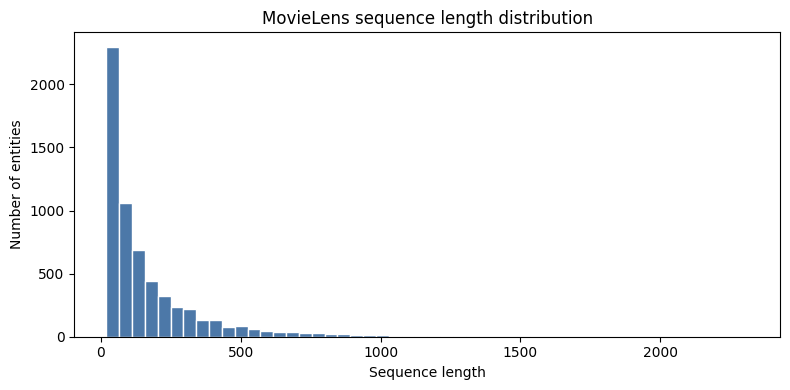

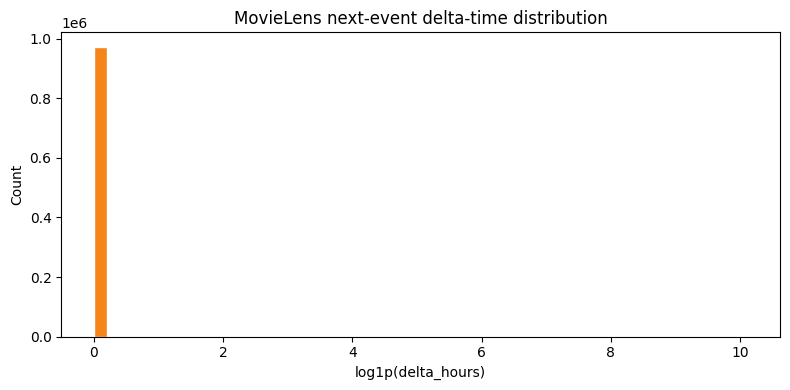

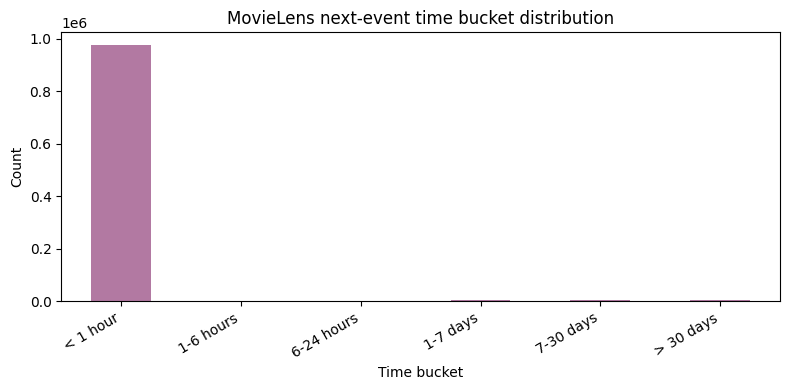

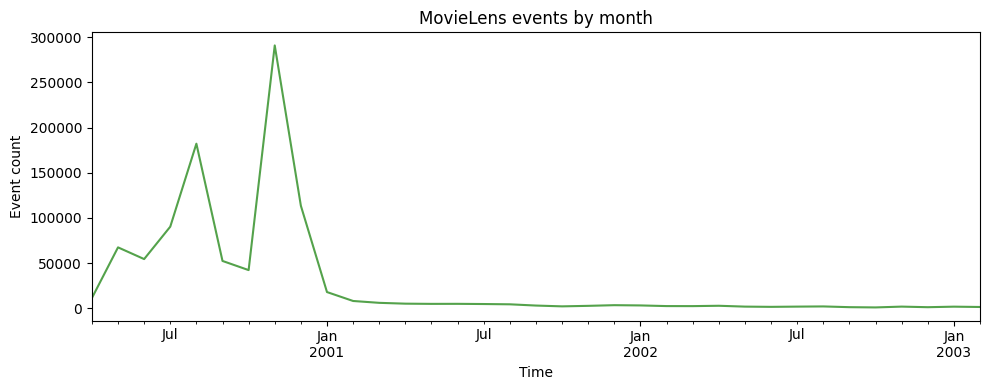

In [10]:
if ratings is not None and not movielens_next.empty:
    plot_sequence_lengths(movielens_lengths, "MovieLens sequence length distribution")
    plot_delta_distribution(movielens_next["delta_hours"], "MovieLens next-event delta-time distribution")
    plot_time_bucket_distribution(movielens_next, "MovieLens next-event time bucket distribution")
    plot_events_over_time(ratings, "datetime", "MovieLens events by month", freq="M")

### Nhận xét về các phân phối của MovieLens

Các biểu đồ trên cung cấp thêm bằng chứng về mức độ phù hợp và hạn chế của MovieLens cho bài toán time-aware recommendation.

Thứ nhất, phân phối độ dài sequence cho thấy MovieLens có cấu trúc user-item sequence khá tốt. Phần lớn user có nhiều rating, và một số user có lịch sử rất dài. Điều này cho phép tạo nhiều mẫu huấn luyện dạng `current event -> next event` hoặc `history -> next event`. Tuy nhiên, phân phối sequence length bị lệch phải mạnh: một số ít user có số lượng tương tác rất lớn, trong khi phần lớn user có độ dài thấp hơn nhiều. Vì vậy, khi xây dựng mô hình sequence, nên cân nhắc giới hạn history bằng `last_k_items` hoặc kiểm tra hiệu năng theo từng nhóm user có lịch sử ngắn và dài.

Thứ hai, phân phối `delta_time` giữa hai event liên tiếp cho thấy phần lớn các rating xảy ra rất gần nhau. Hầu hết giá trị `log1p(delta_hours)` tập trung sát 0, phù hợp với thống kê trước đó rằng `median_delta_hours = 0.0` và `p90_delta_hours ≈ 0.0186`. Điều này nghĩa là 90% cặp event liên tiếp cách nhau dưới khoảng 1.1 phút. Đây là một tín hiệu quan trọng: mặc dù MovieLens có timestamp, timestamp này chủ yếu phản ánh thời điểm user nhập rating vào hệ thống, không chắc là thời điểm user thật sự xem phim. Một user có thể xem nhiều phim ở các thời điểm khác nhau, nhưng sau đó rating hàng loạt trong cùng một phiên, khiến nhiều interaction có timestamp rất gần nhau hoặc trùng nhau.

Thứ ba, phân phối `time_bucket` cho thấy target thời gian bị mất cân bằng rất mạnh. Gần như toàn bộ mẫu rơi vào bucket `< 1 hour`, trong khi các bucket như `1-6 hours`, `6-24 hours`, `1-7 days`, `7-30 days`, và `> 30 days` có số lượng nhỏ hơn rất nhiều. Do đó, nếu dùng `time_bucket` làm target phân loại, mô hình có thể đạt accuracy cao chỉ bằng cách dự đoán lớp phổ biến nhất. Trong trường hợp này, nên đánh giá bằng các metric như `macro-F1`, `balanced accuracy`, `per-class recall`, hoặc confusion matrix thay vì chỉ dùng accuracy.

Thứ tư, biểu đồ số lượng event theo tháng cho thấy phân phối thời gian của MovieLens không đều. Dữ liệu tập trung mạnh ở giai đoạn đầu, đặc biệt quanh năm 2000, sau đó số lượng rating giảm rõ rệt trong các năm tiếp theo. Điều này cho thấy tồn tại temporal distribution shift. Vì vậy, với bài toán time-aware, nên ưu tiên temporal split thay vì random split, ví dụ dùng giai đoạn sớm để train, giai đoạn giữa để validation và giai đoạn muộn để test.

Tóm lại, MovieLens rất phù hợp để nghiên cứu `next-item prediction` và sequence recommendation vì user history đủ dài và có thể tạo nhiều mẫu next-event. Tuy nhiên, việc dự đoán chính xác `next_time` cần được diễn giải thận trọng. Timestamp trong MovieLens nên được xem là thời điểm rating được ghi nhận, không chắc là thời điểm tiêu thụ nội dung. Do đó, hướng hợp lý hơn là dùng MovieLens cho `next_item prediction`, hoặc dự đoán thời gian ở mức khái quát hơn như `delta_time`, `time_bucket`, hoặc tách riêng bài toán `within-session` và `cross-session`.

## 7. Amazon Exploration

Amazon review sample là user-item-event dataset nhưng thường sparse theo user, nhất là khi chỉ lấy sample nhỏ. Phần này tự phát hiện cột user/item/timestamp để kiểm tra schema và đánh giá liệu sample đủ repeated users cho target next-event hay chỉ nên dùng để test pipeline.

In [11]:
amazon = safe_read_file(PATHS["amazon_appliances"], pd.read_csv, dataset_name="Amazon Appliances")
amazon_schema_summary = pd.DataFrame()
amazon_time_summary = pd.DataFrame()
amazon_sequence_summary = pd.DataFrame()
amazon_next_event_sample = pd.DataFrame()
amazon_next = pd.DataFrame()
amazon_lengths = pd.Series(dtype="int64")
amazon_temporal_report = {}
amazon_column_mapping = pd.DataFrame()

if amazon is not None:
    display(amazon.head(10))
    detected_user = detect_column(amazon.columns, ["user_id", "reviewer_id", "reviewerID", "customer_id"], ["user"])
    detected_item = detect_column(amazon.columns, ["parent_asin", "asin", "item_id", "product_id"], ["asin", "item", "product"])
    detected_time = detect_column(amazon.columns, ["timestamp", "unixReviewTime", "review_time", "reviewTime"], ["time", "date"])
    detected_rating = detect_column(amazon.columns, ["rating", "overall", "stars", "score"], ["rating", "star"])
    amazon_column_mapping = pd.DataFrame([{"user_col": detected_user, "item_col": detected_item, "timestamp_col": detected_time, "rating_col": detected_rating}])
    display(amazon_column_mapping)
    if detected_user and detected_item and detected_time:
        rename_map = {detected_user: "user_id", detected_item: "item_id", detected_time: "timestamp"}
        if detected_rating:
            rename_map[detected_rating] = "rating"
        amazon = amazon.rename(columns=rename_map)

[OK] Amazon Appliances: 5,000 rows, 10 columns


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5.0,Work great,work great. use a new one every month,[],B01N0TQ0OH,B01N0TQ0OH,AGKHLEW2SOWHNMFQIJGBECAF7INQ,1519317108692,0,True
1,5.0,excellent product,Little on the thin side,[],B07DD2DMXB,B07DD37QPZ,AHWWLSPCJMALVHDDVSUGICL6RUCA,1664746863446,0,True
2,5.0,Happy customer!,"Quick delivery, fixed the issue!",[],B082W3Z9YK,B082W3Z9YK,AHZIJGKEWRTAEOZ673G5B3SNXEGQ,1607225435363,0,True
3,5.0,Amazing value,I wasn't sure whether these were worth it or n...,[],B078W2BJY8,B078W2BJY8,AFGUPTDFAWOHHL4LZDV27ERDNOYQ,1534104184306,0,True
4,5.0,Dryer parts,Easy to install got the product expected to re...,[],B08C9LPCQV,B08C9LPCQV,AELFJFAXQERUSMTXJQ6SYFFRDWMA,1620176603754,0,True
5,5.0,DO NOT purchase this ice machine.,After buying this ice machine just 15 months a...,[],B08D6RFV6D,B099ZKQJHK,AEUH4EH6XHROLT7UZPUYU2YKTYMA,1663078878875,0,True
6,2.0,They don't fit properly,Not the best quality,[],B001TH7GZA,B001TH7H0O,AHCV2CNCOCG6WECDROOUYPDZIFEQ,1610219023865,0,True
7,5.0,Five Stars,Part came quickly and fit my LG dryer. Thanks!,[],B00AF7WZTM,B00AF7WZTM,AH6PLOGWYIVIWLJTY756BHNFD4YA,1480334300000,0,True
8,5.0,Five Stars,Always arrive in a fast manner. Descriptions ...,[],B001H05AXY,B001H05AXY,AGCIVNDDRX3PXIUINEG4NCRGWCRA,1427130850000,0,True
9,2.0,Company is phenomenal.,The company responded very quickly. Refunded p...,[],B085C6C7WH,B085C6C7WH,AFUOYIZBU3MTBOLYKOJE5Z35MBDA,1630449561325,0,True


,user_col,item_col,timestamp_col,rating_col
0,user_id,parent_asin,timestamp,rating


### Amazon Schema Summary

Bảng schema giúp xác nhận cột đã detect có đúng ý nghĩa hay không. Với Amazon, `parent_asin`/`asin` có thể đóng vai trò item, còn timestamp thường là Unix milliseconds trong sample hiện tại.

In [12]:
if amazon is not None:
    amazon_schema_summary = summarize_dataframe(amazon)
    display(amazon_schema_summary)

,column,dtype,missing,missing_pct,n_unique,example_value
0,rating,float64,0,0.00,5,5.0
1,title,object,1,0.02,3750,Work great
2,text,object,1,0.02,4817,work great. use a new one every month
3,images,object,0,0.00,250,[]
4,asin,object,0,0.00,3371,B01N0TQ0OH
5,item_id,object,0,0.00,3123,B01N0TQ0OH
6,user_id,object,0,0.00,3124,AGKHLEW2SOWHNMFQIJGBECAF7INQ
7,timestamp,int64,0,0.00,4999,1519317108692
8,helpful_vote,int64,0,0.00,50,0
9,verified_purchase,bool,0,0.00,2,True


### Amazon Timestamp Analysis

Cell này parse timestamp tự động theo unit. Nếu timestamp hợp lệ nhưng user repeat thấp, dataset vẫn chỉ phù hợp để kiểm tra schema/pipeline hơn là train mô hình time-aware đáng tin cậy.

In [13]:
if amazon is not None and {"user_id", "item_id", "timestamp"}.issubset(amazon.columns):
    amazon, amazon_time_summary = analyze_timestamp(amazon, "timestamp")
    display(amazon_time_summary)
    display(pd.DataFrame([{"n_reviews": len(amazon), "n_users": amazon["user_id"].nunique(), "n_items": amazon["item_id"].nunique()}]))
elif amazon is not None:
    print("[WARN] Amazon is missing detected user_id/item_id/timestamp columns; target construction will be skipped.")

,timestamp_col,unit,n_rows,missing_raw,invalid_or_missing_parsed,valid_rate,min_datetime,max_datetime,time_span_days,is_monotonic_in_file_order
0,timestamp,ms,5000,0,0,1.0,2007-03-29 23:05:20,2023-03-17 07:53:04.630,5831.366,False


,n_reviews,n_users,n_items
0,5000,3124,3123


### Amazon Sequence Feasibility

Bảng này là nơi quyết định Amazon sample có đủ repeated users hay không. Nếu `entities_with_2plus_events_pct` thấp, vẫn có thể dùng Amazon để kiểm tra pipeline nhưng không nên xem là benchmark chính.

In [14]:
if amazon is not None and {"user_id", "item_id", "datetime"}.issubset(amazon.columns):
    amazon_sequence_summary, amazon_lengths = analyze_sequence_feasibility(amazon, "Amazon Appliances", "user_id", "item_id", "datetime", recommendation_like=True)
    display(amazon_sequence_summary)
    display(threshold_coverage_table(amazon_lengths))

,dataset,entity_col,item_col,time_col,n_rows,n_entities,n_items,median_sequence_length,entities_with_2plus_events_pct,entities_with_5plus_events_pct,can_create_next_item,can_create_next_time,main_limitation
0,Amazon Appliances,user_id,item_id,datetime,5000,3124,3123,1.0,28.905,3.777,Limited,Limited,"Repeated entities exist, but sample may be spa..."


,threshold,entities_count,entities_pct
0,2,903,28.905
1,3,379,12.132
2,5,118,3.777
3,10,19,0.608


### Nhận xét về Amazon Exploration

Phần Amazon Exploration cho thấy Amazon review sample có schema phù hợp với bài toán recommendation. Dataset có các cột quan trọng như `user_id`, `item_id`, `rating`, `timestamp`, `verified_purchase`, `helpful_vote`, `title` và `text`. Mỗi dòng có thể được xem là một event, trong đó một user review hoặc rating một item tại một thời điểm cụ thể. So với MovieLens, Amazon có thêm nhiều thông tin phụ như nội dung review, số vote hữu ích và trạng thái verified purchase, nên có tiềm năng mở rộng feature tốt hơn nếu sử dụng bản dữ liệu lớn.

Phân tích timestamp cho thấy cột `timestamp` hợp lệ: toàn bộ 5,000 dòng đều parse được, không có timestamp bị thiếu hoặc lỗi. Dữ liệu trải dài từ năm 2007 đến 2023, tương ứng khoảng hơn 5,800 ngày. Điều này cho thấy Amazon có span thời gian dài và có thể phù hợp với các bài toán nghiên cứu hành vi dài hạn. Tuy nhiên, dữ liệu gốc không được sắp xếp theo thời gian (`is_monotonic_in_file_order = False`), vì vậy trước khi tạo sequence cần bắt buộc sort theo `user_id` và `datetime`.

Điểm hạn chế lớn nhất của sample này là độ lặp lại theo user rất thấp. Dataset có 5,000 review nhưng có tới 3,124 user và 3,123 item. Median sequence length chỉ bằng 1, nghĩa là user điển hình chỉ xuất hiện một lần trong sample. Chỉ 28.905% user có ít nhất 2 interaction, 3.777% user có ít nhất 5 interaction, và chỉ 0.608% user có ít nhất 10 interaction. Điều này cho thấy phần lớn user không đủ lịch sử để tạo target dạng next-event.

Với bài toán sequence hoặc time-aware recommendation, user có 1 interaction không thể tạo mẫu `current event -> next event`, vì không có event kế tiếp. User có 2 interaction chỉ tạo được 1 mẫu huấn luyện. Do đó, sample Amazon 5,000 dòng hiện tại quá sparse để dùng làm benchmark chính cho next-item hoặc next-time prediction.

Tóm lại, Amazon sample có schema và timestamp tốt, nhưng chưa đủ dense theo user để huấn luyện mô hình sequence đáng tin cậy. Dataset này phù hợp hơn để kiểm tra pipeline, kiểm tra quá trình parse timestamp, mapping user/item và tạo target next-event. Nếu muốn dùng Amazon làm benchmark chính, cần sử dụng bản dữ liệu lớn hơn hoặc lọc các user có nhiều interaction, ví dụ giữ user có ít nhất 5 hoặc 10 review, sau đó đánh giá lại sequence feasibility.

## 8. Amazon Next-Event Target Construction

Formulation giống MovieLens: `X` là lịch sử review trước đó, `Y_item` là item kế tiếp, `Y_time` là thời điểm review kế tiếp, `Y_delta` và `Y_time_bucket` lấy từ khoảng cách thời gian. Với sample sparse, target có thể rất ít hoặc rỗng.

In [15]:
if amazon is not None and {"user_id", "item_id", "datetime"}.issubset(amazon.columns):
    amazon_next = add_time_bucket(create_next_event_targets(amazon, "user_id", "item_id", "datetime"))
    amazon_next_event_sample = sample_next_event_table(amazon_next, n=10)
    display(target_quality_summary(amazon_next))

,target_rows,median_delta_hours,p90_delta_hours,max_delta_days,n_time_buckets
0,1876,5127.41,29303.1614,4827.4728,6


### Amazon Target Sample and Plots

Chỉ hiển thị sample 10 dòng. Nếu sample rỗng, nguyên nhân thường là không đủ user có từ 2 interaction trở lên.

,entity_id,history_length,current_item_or_event,current_time,next_item_or_event,next_time,delta_hours,time_bucket
0,AE2BH7Z4M243LVUXAFCCNPBW2HEA,1,B0BLLHNY92,2019-05-19 23:26:58.908,B0BHNSLKNZ,2019-12-27 22:15:54.538,5326.815453,> 30 days
1,AE2BH7Z4M243LVUXAFCCNPBW2HEA,2,B0BHNSLKNZ,2019-12-27 22:15:54.538,B07Z1GBH8J,2020-11-28 19:47:26.111,8085.525437,> 30 days
2,AE2BH7Z4M243LVUXAFCCNPBW2HEA,3,B07Z1GBH8J,2020-11-28 19:47:26.111,B001TH7GZU,2020-11-28 22:57:27.213,3.166973,1-6 hours
3,AE2EUSV2YAM6MV62P4JCC3XBKWTQ,1,B004Q3XO7I,2014-10-28 01:57:09.000,B0C85M2F4G,2021-12-23 15:37:24.028,62725.670841,> 30 days
4,AE2EUSV2YAM6MV62P4JCC3XBKWTQ,2,B0C85M2F4G,2021-12-23 15:37:24.028,B08YR8KB69,2022-11-01 23:50:29.994,7520.218324,> 30 days
5,AE2FSM3CYL5L6GYJOBHYMWV66FAA,1,B0921424L1,2022-03-06 19:20:42.704,B0BPFM7JSG,2022-03-06 19:35:16.877,0.242826,< 1 hour
6,AE2KTZVOMXO3XBRSERKGSBX4Q4IA,1,B01KKUFW34,2021-04-15 18:28:51.019,B08XP29S76,2021-08-14 23:44:24.300,2909.259245,> 30 days
7,AE2ODZ4VYQ5FNNCONSHSNZM7PHSQ,1,B008B7VI1Y,2014-12-16 18:42:55.000,B01LYYTRHQ,2018-12-04 20:42:12.252,34777.988126,> 30 days
8,AE2ODZ4VYQ5FNNCONSHSNZM7PHSQ,2,B01LYYTRHQ,2018-12-04 20:42:12.252,B0100A3H54,2018-12-28 18:04:29.738,573.371524,7-30 days
9,AE2SZWQIRUD2BJOOLNIKG2EGRJVA,1,B074WCLFPV,2017-01-17 23:52:44.000,B000E1385Y,2017-01-18 00:52:49.000,1.001389,1-6 hours


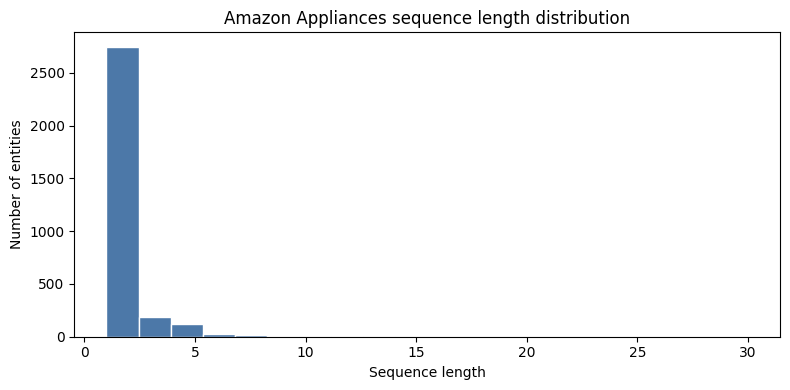

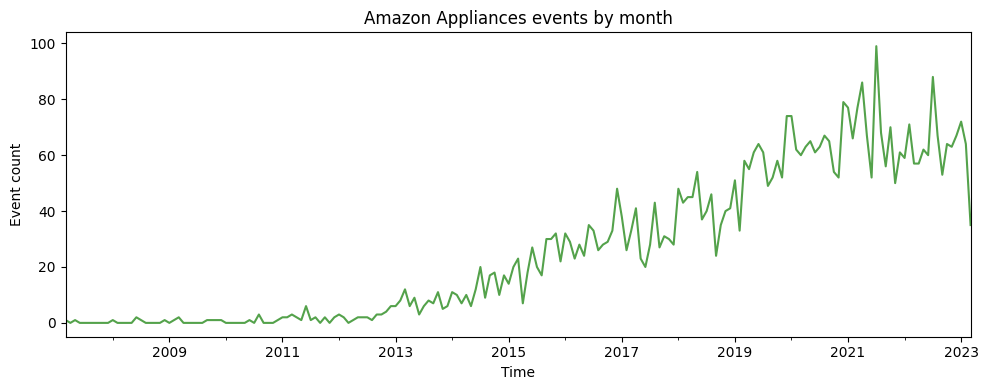

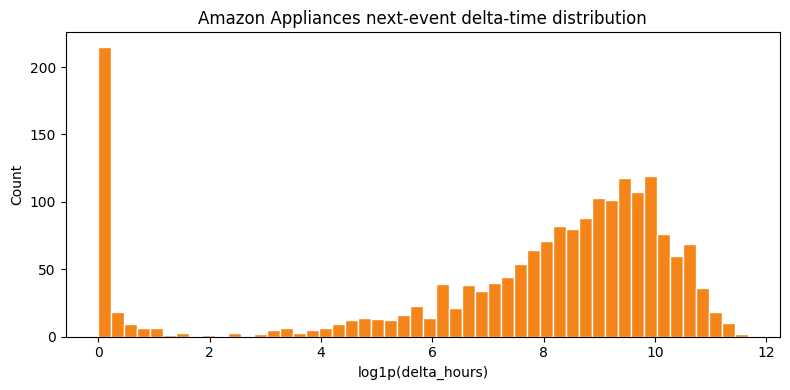

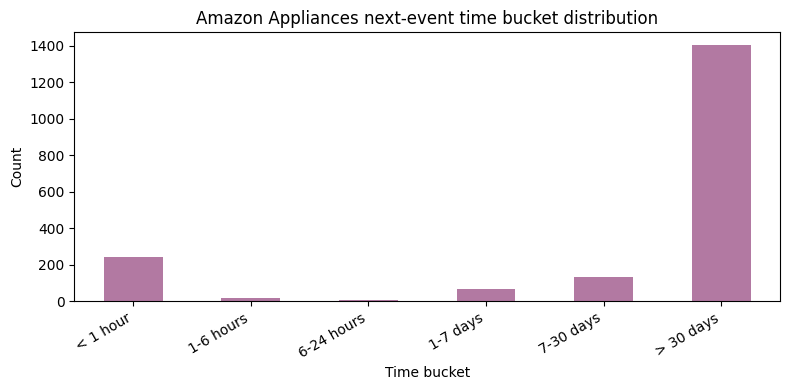

In [16]:
if amazon is not None and {"user_id", "item_id", "datetime"}.issubset(amazon.columns):
    display(amazon_next_event_sample)
    plot_sequence_lengths(amazon_lengths, "Amazon Appliances sequence length distribution")
    plot_events_over_time(amazon, "datetime", "Amazon Appliances events by month", freq="M")
    if not amazon_next.empty:
        plot_delta_distribution(amazon_next["delta_hours"], "Amazon Appliances next-event delta-time distribution")
        plot_time_bucket_distribution(amazon_next, "Amazon Appliances next-event time bucket distribution")

### Nhận xét về Amazon Next-Event Target Construction

Phần này chuyển Amazon Appliances sample sang dạng bài toán dự đoán event kế tiếp, tương tự như MovieLens. Với mỗi user, các review được sắp xếp theo `datetime`, sau đó tạo các mẫu `current event -> next event`. Một event có thể là target của dòng trước và tiếp tục trở thành input của dòng sau, đúng theo cơ chế sliding window.

Từ 5,000 review ban đầu, notebook tạo được 1,876 mẫu next-event. Con số này thấp hơn nhiều so với MovieLens vì Amazon sample bị sparse mạnh theo user. Nhiều user chỉ xuất hiện một lần nên không thể tạo target event kế tiếp. Điều này cho thấy sample hiện tại có thể dùng để kiểm tra pipeline, nhưng chưa phù hợp để làm benchmark chính cho sequence recommendation.

Khác với MovieLens, phân phối thời gian của Amazon có khoảng cách giữa các event lớn hơn nhiều. `median_delta_hours = 5127.41`, tương đương khoảng 213 ngày, và `p90_delta_hours = 29303.16`, tương đương hơn 3 năm. Điều này cho thấy review kế tiếp của cùng một user thường xảy ra sau nhiều tháng hoặc nhiều năm, thay vì chỉ sau vài giây hoặc vài phút như MovieLens.

Bảng sample cũng minh họa rõ đặc điểm này. Một số cặp review liên tiếp cách nhau rất lâu và rơi vào bucket `> 30 days`, trong khi một số ít cặp review xảy ra gần nhau hơn, ví dụ trong `1-6 hours` hoặc `< 1 hour`. Do đó, Amazon có phân phối thời gian đa dạng hơn và có ý nghĩa hơn cho bài toán dự đoán khoảng cách thời gian giữa các tương tác.

Biểu đồ sequence length cho thấy phần lớn user có rất ít review trong sample. Đây là hạn chế lớn nhất của Amazon sample hiện tại. Với bài toán next-event, user có một interaction không thể tạo mẫu huấn luyện, còn user có hai interaction chỉ tạo được một mẫu. Vì vậy, mặc dù Amazon có timestamp và schema phù hợp, sample 5,000 dòng này chưa đủ dense để huấn luyện mô hình sequence đáng tin cậy.

Biểu đồ event theo tháng cho thấy số lượng review tăng dần theo thời gian, đặc biệt từ giai đoạn sau năm 2015. Điều này cho thấy tồn tại temporal distribution shift. Nếu dùng Amazon để train mô hình time-aware, nên ưu tiên temporal split thay vì random split để tránh leakage giữa quá khứ và tương lai.

Biểu đồ time bucket cho thấy phần lớn target rơi vào bucket `> 30 days`. Điều này hợp lý với dữ liệu review sản phẩm, vì user thường không review nhiều sản phẩm liên tục trong thời gian rất ngắn. Tuy nhiên, target bucket vẫn bị mất cân bằng, nên nếu dùng `time_bucket` làm target phân loại, cần đánh giá bằng `macro-F1`, `balanced accuracy`, `per-class recall` hoặc confusion matrix thay vì chỉ dùng accuracy.

Tóm lại, Amazon Appliances sample có timestamp hợp lệ và khoảng cách thời gian giữa các event có ý nghĩa thực tế hơn MovieLens. Tuy nhiên, sample hiện tại quá sparse theo user nên không nên dùng làm benchmark chính. Dataset này phù hợp để kiểm tra pipeline và chứng minh rằng formulation `current event -> next event` có thể áp dụng cho dữ liệu review sản phẩm. Nếu muốn dùng Amazon nghiêm túc, cần lấy bản dữ liệu lớn hơn hoặc lọc các user có nhiều interaction trước khi xây dựng mô hình.

## 9. CASAS Exploration

CASAS là smart-home sensor/event dataset. Nó có timestamp và event sequence rất mạnh, nhưng không phải user-item recommender dataset truyền thống. Ở đây `source_home` là entity, `sensor_id` là event/item-like token, và `datetime` là thời điểm event.

In [17]:
casas_datasets: dict[str, pd.DataFrame] = {}
casas_errors: dict[str, pd.DataFrame] = {}
casas_next_by_home: dict[str, pd.DataFrame] = {}

for home in ["aruba", "cairo", "milan", "tulum1", "tulum2"]:
    df_home, err_home = parse_casas_file(PATHS[f"casas_{home}"], home)
    casas_datasets[home] = df_home
    casas_errors[home] = err_home

casas = pd.concat([df for df in casas_datasets.values() if not df.empty], ignore_index=True) if any(not df.empty for df in casas_datasets.values()) else pd.DataFrame()
casas_schema_summary = pd.DataFrame()
casas_time_summary = pd.DataFrame()
casas_sequence_summary = pd.DataFrame()
casas_next_event_sample = pd.DataFrame()
casas_next = pd.DataFrame()
casas_lengths = pd.Series(dtype="int64")
casas_temporal_report = {}

print(f"Combined CASAS rows: {len(casas):,}")
if not casas.empty:
    display(casas.head(10))

[OK] CASAS aruba: parsed 1,719,558 rows; parse errors=0
[OK] CASAS cairo: parsed 726,534 rows; parse errors=0
[OK] CASAS milan: parsed 433,665 rows; parse errors=0
[OK] CASAS tulum1: parsed 486,912 rows; parse errors=0
[OK] CASAS tulum2: parsed 1,085,900 rows; parse errors=0
Combined CASAS rows: 4,452,569


,date,time,sensor_id,message,activity_raw,source_home,datetime
0,2010-11-04,00:03:50.209589,M003,ON,Sleeping begin,aruba,2010-11-04 00:03:50.209589
1,2010-11-04,00:03:57.399391,M003,OFF,NaN,aruba,2010-11-04 00:03:57.399391
2,2010-11-04,00:15:08.984841,T002,21.5,NaN,aruba,2010-11-04 00:15:08.984841
3,2010-11-04,00:30:19.185547,T003,21,NaN,aruba,2010-11-04 00:30:19.185547
4,2010-11-04,00:30:19.385336,T004,21,NaN,aruba,2010-11-04 00:30:19.385336
5,2010-11-04,00:35:22.24587,T005,20.5,NaN,aruba,2010-11-04 00:35:22.245870
6,2010-11-04,00:40:25.428962,T005,21,NaN,aruba,2010-11-04 00:40:25.428962
7,2010-11-04,00:45:28.658171,T005,20.5,NaN,aruba,2010-11-04 00:45:28.658171
8,2010-11-04,01:05:42.269469,T001,20,NaN,aruba,2010-11-04 01:05:42.269469
9,2010-11-04,01:15:48.936777,T002,21,NaN,aruba,2010-11-04 01:15:48.936777


### CASAS Schema Summary

Schema CASAS đã được chuẩn hóa thành `date`, `time`, `sensor_id`, `message`, `activity_raw`, `source_home`, `datetime`. Activity labels có thể thiếu hoặc là trạng thái begin/end; vì vậy target chính ở đây là next sensor event/time.

In [18]:
if not casas.empty:
    casas_schema_summary = summarize_dataframe(casas)
    display(casas_schema_summary)

,column,dtype,missing,missing_pct,n_unique,example_value
0,date,object,0,0.000,476,2010-11-04
1,time,object,0,0.000,4424373,00:03:50.209589
2,sensor_id,object,0,0.000,42,M003
3,message,object,0,0.000,99,ON
4,activity_raw,object,4405410,98.941,108,Sleeping begin
5,source_home,object,0,0.000,5,aruba
6,datetime,datetime64[ns],4249,0.095,4437112,2010-11-04 00:03:50.209589


### CASAS Timestamp and Diagnostics

Cell này gom diagnostic ngắn theo từng home: valid timestamp rate, range thời gian, parse errors, số sensor và mức thiếu activity. Chi tiết event-level không được in toàn bộ.

In [19]:
if not casas.empty:
    diagnostic_rows = []
    for home, df_home in casas_datasets.items():
        if df_home.empty:
            continue
        valid_dt = df_home["datetime"].dropna()
        diagnostic_rows.append({
            "home": home,
            "n_rows": len(df_home),
            "valid_rate": round(float(df_home["datetime"].notna().mean()), 5),
            "min_datetime": valid_dt.min() if not valid_dt.empty else pd.NaT,
            "max_datetime": valid_dt.max() if not valid_dt.empty else pd.NaT,
            "parse_error_rows": len(casas_errors.get(home, pd.DataFrame())),
            "n_sensors": df_home["sensor_id"].nunique(dropna=True),
            "activity_labels": df_home["activity_raw"].nunique(dropna=True),
            "activity_missing_pct": round(float(df_home["activity_raw"].isna().mean() * 100), 3),
        })
    casas_time_summary = pd.DataFrame(diagnostic_rows)
    display(casas_time_summary)

,home,n_rows,valid_rate,min_datetime,max_datetime,parse_error_rows,n_sensors,activity_labels,activity_missing_pct
0,aruba,1719558,1.00000,2010-11-04 00:03:50.209589,2011-06-11 23:58:10.004834,0,41,25,99.247
1,cairo,726534,0.99999,2009-06-10 00:00:00.024668,2009-08-05 23:59:14.053191,0,32,26,99.835
2,milan,433665,0.99026,2009-10-16 00:01:04.000059,2010-01-06 12:48:47.000021,0,33,30,98.915
3,tulum1,486912,0.99999,2009-04-02 07:12:05.002864,2009-07-31 23:56:02.017108,0,20,20,99.379
4,tulum2,1085900,0.99999,2009-09-25 12:49:51.007914,2010-03-28 17:09:16.046637,0,36,35,97.672


### CASAS Sequence Feasibility

CASAS thường có sequence rất dài theo từng home, nên phù hợp với event-time prediction. Tuy nhiên nó không có nhiều user và không phải item recommendation benchmark; đọc `main_limitation` theo hướng đó.

In [20]:
if not casas.empty:
    casas_sequence_summary, casas_lengths = analyze_sequence_feasibility(casas, "CASAS combined", "source_home", "sensor_id", "datetime", recommendation_like=False)
    display(casas_sequence_summary)
    display(threshold_coverage_table(casas_lengths))
    display(casas.groupby("source_home").size().rename("events_per_home").reset_index())

,dataset,entity_col,item_col,time_col,n_rows,n_entities,n_items,median_sequence_length,entities_with_2plus_events_pct,entities_with_5plus_events_pct,can_create_next_item,can_create_next_time,main_limitation
0,CASAS combined,source_home,sensor_id,datetime,4448320,5,42,726527.0,100.0,100.0,Yes,Yes,"Event-time sequence is feasible, but this is n..."


,threshold,entities_count,entities_pct
0,2,5,100.0
1,3,5,100.0
2,5,5,100.0
3,10,5,100.0


,source_home,events_per_home
0,aruba,1719558
1,cairo,726534
2,milan,433665
3,tulum1,486912
4,tulum2,1085900


### Nhận xét về CASAS Exploration

CASAS là smart-home sensor/event dataset, khác bản chất so với MovieLens và Amazon. Trong MovieLens/Amazon, `entity` thường là user và `item` là phim/sản phẩm. Còn trong CASAS, `source_home` được xem như entity, `sensor_id` được xem như event hoặc item-like token, và `datetime` là thời điểm sensor event xảy ra. Vì vậy, CASAS phù hợp hơn với bài toán dự đoán event kế tiếp trong chuỗi cảm biến, thay vì bài toán recommender system truyền thống.

Về schema, dữ liệu đã được chuẩn hóa thành các cột chính gồm `date`, `time`, `sensor_id`, `message`, `activity_raw`, `source_home` và `datetime`. Các cột `date`, `time`, `sensor_id`, `message`, `source_home` gần như không bị thiếu. Cột `datetime` cũng có tỷ lệ hợp lệ rất cao, chỉ thiếu khoảng 0.095%. Điều này cho thấy dữ liệu có chất lượng timestamp tốt và có thể dùng để xây dựng chuỗi event theo thời gian.

Một điểm cần chú ý là cột `activity_raw` bị thiếu rất nhiều, khoảng 98.941%. Điều này cho thấy activity label không phải lúc nào cũng có sẵn; nhiều dòng chỉ là sensor event thô mà không có nhãn hoạt động tương ứng. Vì vậy, nếu dùng CASAS trong notebook này, target chính nên là `next sensor event` hoặc `next event time`, không nên lấy `activity_raw` làm target chính nếu chưa xử lý thêm nhãn activity.

Phần diagnostic theo từng home cho thấy dữ liệu được ghép từ 5 home: `aruba`, `cairo`, `milan`, `tulum1` và `tulum2`. Mỗi home có số lượng event rất lớn, từ hơn 433 nghìn đến hơn 1.7 triệu event. Tỷ lệ timestamp hợp lệ của từng home đều rất cao, xấp xỉ 99% đến 100%. Số lượng sensor dao động từ 20 đến 41 sensor tùy home. Điều này chứng minh CASAS có chuỗi thời gian rất dài và giàu tín hiệu ở mức event.

Phần sequence feasibility cho thấy CASAS có tổng cộng hơn 4.4 triệu dòng sau khi ghép, 5 entity tương ứng với 5 home, và 42 sensor khác nhau. Median sequence length đạt hơn 726 nghìn event, lớn hơn rất nhiều so với MovieLens và Amazon. Đồng thời, 100% home có ít nhất 2, 5 và 10 event. Điều này nghĩa là CASAS cực kỳ phù hợp để tạo dữ liệu dạng `current event -> next event` hoặc `history -> next event`.

Tuy nhiên, chính vì chỉ có 5 entity nên CASAS không giống recommender dataset thông thường. Trong recommender system, ta thường có rất nhiều user và item để học preference cá nhân. Với CASAS, mỗi `source_home` giống một môi trường hoặc một chuỗi sensor riêng, không phải một user theo nghĩa recommendation. Do đó, mô hình học trên CASAS chủ yếu học pattern vận hành của sensor trong nhà thông minh, ví dụ sensor nào thường kích hoạt tiếp theo và sau bao lâu, thay vì học user preference đối với item.

Do đó, CASAS nên được xem là dataset phụ cho bài toán temporal event modeling. Nó rất tốt để kiểm tra khả năng dự đoán `next_event`, `next_sensor`, `delta_time`, hoặc `time_bucket`, nhưng không nên dùng làm benchmark chính cho recommender system. Nếu đưa CASAS vào báo cáo, cần ghi rõ rằng đây là auxiliary event-time dataset, không phải user-item recommendation benchmark.

Tóm lại, CASAS có timestamp rất tốt, sequence cực dài và số lượng event lớn, nên phù hợp cho event-time prediction. Nhưng do chỉ có 5 entity và entity là `source_home`, không phải user cá nhân, CASAS không phù hợp để đánh giá recommendation theo nghĩa truyền thống. Dataset này hữu ích để chứng minh pipeline có thể mở rộng sang dữ liệu temporal event sequence, nhưng kết luận chính về recommender system vẫn nên dựa trên MovieLens và Amazon.

## 10. CASAS Next-Event Target Construction

Với CASAS:

- `X`: chuỗi sensor event trước đó.
- `Y_event`: sensor event tiếp theo.
- `Y_time`: thời điểm event tiếp theo.

CASAS chỉ nên dùng như dataset tham khảo cho event-time prediction hoặc IoT activity/event modeling, không phải direct recommender-system benchmark.

In [21]:
if not casas.empty:
    casas_next = add_time_bucket(create_next_event_targets(casas, "source_home", "sensor_id", "datetime"))
    casas_next_event_sample = sample_next_event_table(casas_next, n=10)
    display(target_quality_summary(casas_next))
    display(casas_next_event_sample)

,target_rows,median_delta_hours,p90_delta_hours,max_delta_days,n_time_buckets
0,4448315,0.0004,0.0022,31.2066,6


,entity_id,history_length,current_item_or_event,current_time,next_item_or_event,next_time,delta_hours,time_bucket
0,aruba,1,M003,2010-11-04 00:03:50.209589,M003,2010-11-04 00:03:57.399391,0.001997,< 1 hour
1,aruba,2,M003,2010-11-04 00:03:57.399391,T002,2010-11-04 00:15:08.984841,0.186552,< 1 hour
2,aruba,3,T002,2010-11-04 00:15:08.984841,T003,2010-11-04 00:30:19.185547,0.252834,< 1 hour
3,aruba,4,T003,2010-11-04 00:30:19.185547,T004,2010-11-04 00:30:19.385336,0.000055,< 1 hour
4,aruba,5,T004,2010-11-04 00:30:19.385336,T005,2010-11-04 00:35:22.245870,0.084128,< 1 hour
5,aruba,6,T005,2010-11-04 00:35:22.245870,T005,2010-11-04 00:40:25.428962,0.084218,< 1 hour
6,aruba,7,T005,2010-11-04 00:40:25.428962,T005,2010-11-04 00:45:28.658171,0.084230,< 1 hour
7,aruba,8,T005,2010-11-04 00:45:28.658171,T001,2010-11-04 01:05:42.269469,0.337114,< 1 hour
8,aruba,9,T001,2010-11-04 01:05:42.269469,T002,2010-11-04 01:15:48.936777,0.168519,< 1 hour
9,aruba,10,T002,2010-11-04 01:15:48.936777,T003,2010-11-04 01:30:59.100184,0.252823,< 1 hour


### Nhận xét về CASAS Next-Event Target Construction

Phần này chuyển CASAS thành bài toán dự đoán event kế tiếp theo thời gian. Với mỗi `source_home`, các sensor event được sắp xếp theo `datetime`, sau đó tạo các mẫu dạng `current event -> next event`. Ở đây, `entity_id` là từng home, `current_item_or_event` là sensor hiện tại, `next_item_or_event` là sensor kế tiếp, `current_time` và `next_time` là thời điểm xảy ra hai event liên tiếp.

CASAS tạo được 4,448,315 target rows, gần bằng tổng số event ban đầu trừ đi số lượng home. Điều này hợp lý vì với mỗi chuỗi event của một home, nếu có `n` event thì có thể tạo `n - 1` mẫu next-event. Do mỗi home có chuỗi rất dài, số lượng mẫu huấn luyện sinh ra rất lớn.

Bảng sample cho thấy cách sliding window được áp dụng tương tự MovieLens và Amazon. Ví dụ, trong home `aruba`, event `M003` tại `2010-11-04 00:03:50` được dùng để dự đoán event `M003` tiếp theo tại `00:03:57`. Sau đó event `M003` tại `00:03:57` lại trở thành input để dự đoán event `T002` tại `00:15:08`. Như vậy, một event có thể là target của dòng trước và tiếp tục là input của dòng sau.

Kết quả thời gian cho thấy CASAS có khoảng cách giữa các event rất ngắn. `median_delta_hours = 0.0004`, tương đương khoảng 1.44 giây, và `p90_delta_hours = 0.0022`, tương đương khoảng 7.92 giây. Điều này phản ánh đúng bản chất dữ liệu smart-home sensor: các sensor có thể kích hoạt liên tục trong thời gian rất ngắn khi có chuyển động, thay đổi nhiệt độ, mở/tắt thiết bị hoặc các tín hiệu môi trường khác.

Hầu hết sample trong bảng rơi vào bucket `< 1 hour`. Tuy nhiên, khác với MovieLens, khoảng cách thời gian ngắn trong CASAS là hợp lý hơn về mặt bản chất dữ liệu, vì sensor event thật sự có thể xảy ra liên tiếp trong vài giây hoặc vài phút. Trong MovieLens, timestamp ngắn thường phản ánh thời điểm user nhập rating hàng loạt, không chắc là thời điểm user thật sự xem phim. Còn trong CASAS, timestamp gần hơn với thời điểm event thực tế được ghi nhận bởi sensor.

Tuy vậy, CASAS không nên được xem là recommender-system benchmark trực tiếp. Dataset này chỉ có 5 entity tương ứng với 5 home, không có nhiều user cá nhân và cũng không có item theo nghĩa sản phẩm/phim. Vì vậy, mô hình trên CASAS chủ yếu học pattern chuyển tiếp giữa các sensor, ví dụ sensor nào thường được kích hoạt tiếp theo và sau bao lâu, thay vì học user preference đối với item.

Do đó, CASAS phù hợp nhất để làm dataset tham khảo cho `event-time prediction`, `next sensor prediction`, hoặc IoT activity/event modeling. Nó rất mạnh để kiểm tra pipeline xử lý chuỗi thời gian dài và dự đoán event kế tiếp, nhưng không nên dùng làm benchmark chính cho recommender system. Trong báo cáo, cần ghi rõ CASAS là auxiliary temporal event dataset, còn MovieLens/Amazon mới gần với setting user-item recommendation hơn.

### CASAS Plots

Plot CASAS được chạy trên combined stream và tách khỏi phần tạo target. Với dữ liệu sensor, delta-time thường rất lệch về các khoảng ngắn.

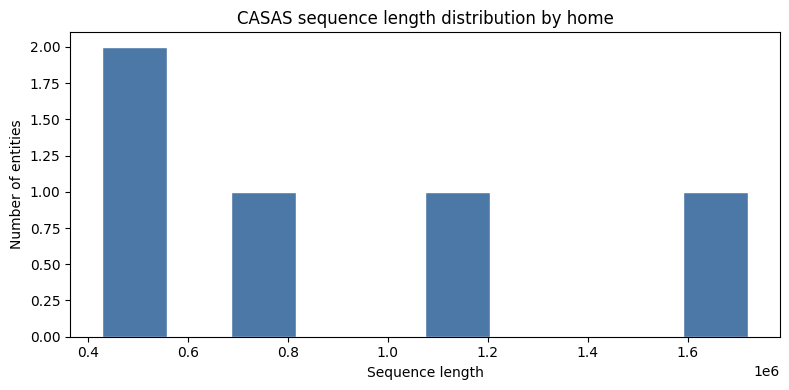

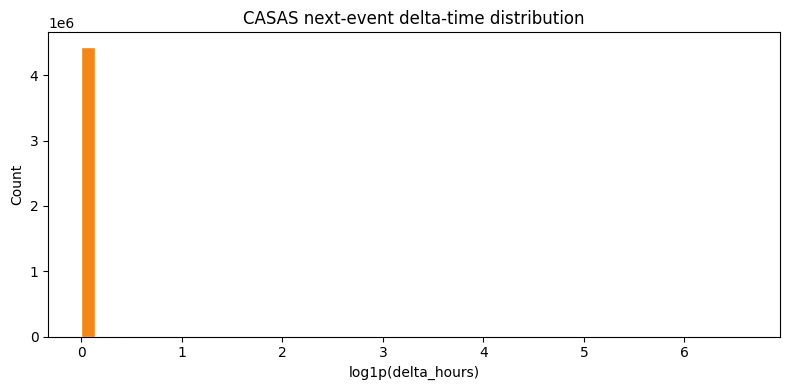

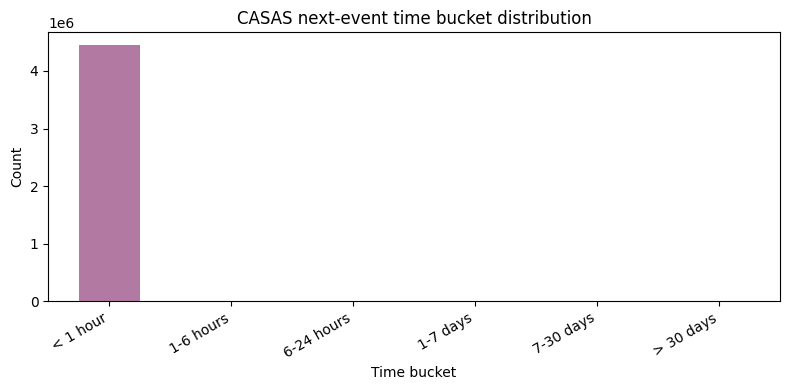

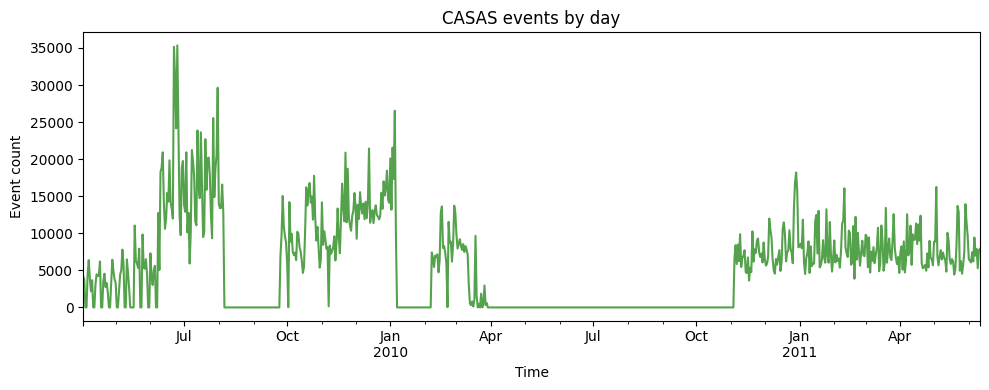

In [22]:
if not casas.empty and not casas_next.empty:
    plot_sequence_lengths(casas_lengths, "CASAS sequence length distribution by home")
    plot_delta_distribution(casas_next["delta_hours"], "CASAS next-event delta-time distribution")
    plot_time_bucket_distribution(casas_next, "CASAS next-event time bucket distribution")
    plot_events_over_time(casas, "datetime", "CASAS events by day", freq="D")

### Nhận xét về các phân phối của CASAS

Các biểu đồ trên cho thấy CASAS có đặc điểm rất khác MovieLens và Amazon. Đây là dataset smart-home sensor event, trong đó `source_home` đóng vai trò entity, `sensor_id` đóng vai trò event/item-like token, và `datetime` là thời điểm sensor được ghi nhận.

Biểu đồ sequence length theo home cho thấy mỗi home có chuỗi event rất dài, từ vài trăm nghìn đến hơn 1.7 triệu event. Điều này chứng minh CASAS cực kỳ phù hợp để tạo dữ liệu dạng `current event -> next event` hoặc `history -> next event`. Khác với Amazon sample, CASAS không gặp vấn đề thiếu repeated interaction; mỗi home đều có rất nhiều event để tạo target.

Tuy nhiên, số lượng entity trong CASAS chỉ là 5 home. Điều này là hạn chế lớn nếu đặt trong ngữ cảnh recommender system, vì recommender system thường cần nhiều user để học preference cá nhân. Ở CASAS, mô hình chủ yếu học pattern chuyển tiếp giữa các sensor trong từng môi trường nhà thông minh, thay vì học sở thích user đối với item.

Biểu đồ `delta_time` cho thấy phần lớn khoảng cách giữa hai event liên tiếp rất nhỏ. Hầu hết giá trị `log1p(delta_hours)` tập trung sát 0. Điều này phù hợp với thống kê trước đó: `median_delta_hours = 0.0004`, tương đương khoảng 1.44 giây, và `p90_delta_hours = 0.0022`, tương đương khoảng 7.92 giây. Như vậy, phần lớn sensor event xảy ra liên tiếp trong vài giây.

Biểu đồ `time_bucket` cũng cho thấy gần như toàn bộ sample rơi vào bucket `< 1 hour`. Với CASAS, điều này hợp lý hơn so với MovieLens. Trong MovieLens, timestamp thường là thời điểm user nhập rating, không chắc là thời điểm user thật sự xem phim. Còn trong CASAS, timestamp là thời điểm sensor thật sự ghi nhận event, nên khoảng cách thời gian ngắn phản ánh đúng bản chất dữ liệu IoT/smart-home: các sensor có thể kích hoạt liên tục khi có chuyển động, thay đổi nhiệt độ hoặc trạng thái thiết bị.

Biểu đồ event theo ngày cho thấy số lượng event không ổn định theo thời gian. Có nhiều giai đoạn event count rất cao, nhưng cũng có các khoảng gần như bằng 0. Điều này có thể đến từ sự khác biệt giữa các home, khoảng thời gian ghi nhận khác nhau, hoặc giai đoạn cảm biến không hoạt động/không có dữ liệu. Vì vậy, nếu dùng CASAS để train model, cần chú ý temporal split và kiểm tra dữ liệu theo từng `source_home`, thay vì chỉ nhìn dataset sau khi gộp.

Tóm lại, CASAS có sequence cực dài, timestamp đáng tin cậy và số lượng target rất lớn, nên rất phù hợp cho các bài toán `next sensor prediction`, `next event-time prediction`, hoặc IoT event modeling. Tuy nhiên, vì chỉ có 5 entity và entity là home chứ không phải user cá nhân, CASAS không nên được xem là benchmark recommender system trực tiếp. Dataset này nên được dùng như auxiliary temporal event dataset để chứng minh pipeline có thể xử lý chuỗi event thời gian rất dài.

## 11. Last.fm 1K Exploration

Last.fm 1K là music listening log dataset. Khác với MovieLens, timestamp trong Last.fm thường gần với thời điểm user thật sự nghe nhạc hơn là thời điểm nhập rating. Vì vậy dataset này có tiềm năng tốt hơn cho bài toán next-event, next-artist/track và next-listening-time prediction.

### 11.1 Load Last.fm

Đọc file listening log không header, đặt schema chuẩn, parse timestamp về `datetime`, rồi tạo `item_id`/`item_name` ở mức track với fallback sang artist khi track bị thiếu. File Last.fm khá lớn, nên notebook đọc sample `LASTFM_SAMPLE_NROWS` mặc định (1,000,000 dòng) để tránh quá tải RAM; đặt biến này thành `None` nếu muốn đọc full dataset.


In [23]:
lastfm = safe_read_file(PATHS["lastfm_events"], read_lastfm_events, dataset_name="Last.fm 1K events")
lastfm_schema_summary = pd.DataFrame()
lastfm_time_summary = pd.DataFrame()
lastfm_sequence_summary = pd.DataFrame()
lastfm_artist_sequence_summary = pd.DataFrame()
lastfm_next_event_sample = pd.DataFrame()
lastfm_next = pd.DataFrame()
lastfm_artist_next = pd.DataFrame()
lastfm_lengths = pd.Series(dtype="int64")
lastfm_artist_lengths = pd.Series(dtype="int64")
lastfm_temporal_report = {}

if lastfm is not None:
    display(pd.DataFrame([{"sample_nrows_limit": LASTFM_SAMPLE_NROWS, "loaded_rows": len(lastfm)}]))
    parsed_datetime = pd.to_datetime(lastfm["timestamp"], errors="coerce", utc=True)
    lastfm["datetime"] = parsed_datetime.dt.tz_convert(None)
    lastfm["item_id"] = lastfm["track_id"].where(lastfm["track_id"].notna(), lastfm["artist_id"])
    lastfm["item_name"] = lastfm["track_name"].where(lastfm["track_name"].notna(), lastfm["artist_name"])
    display(lastfm.head(10))
    display(summarize_dataframe(lastfm))

[OK] Last.fm 1K events: 1,000,000 rows, 6 columns


,sample_nrows_limit,loaded_rows
0,1000000,1000000


,user_id,timestamp,artist_id,artist_name,track_id,track_name,datetime,item_id,item_name
0,user_000001,2009-05-04T23:08:57Z,f1b1cf71-bd35-4e99-8624-24a6e15f133a,Deep Dish,NaN,Fuck Me Im Famous (Pacha Ibiza)-09-28-2007,2009-05-04 23:08:57,f1b1cf71-bd35-4e99-8624-24a6e15f133a,Fuck Me Im Famous (Pacha Ibiza)-09-28-2007
1,user_000001,2009-05-04T13:54:10Z,a7f7df4a-77d8-4f12-8acd-5c60c93f4de8,坂本龍一,NaN,Composition 0919 (Live_2009_4_15),2009-05-04 13:54:10,a7f7df4a-77d8-4f12-8acd-5c60c93f4de8,Composition 0919 (Live_2009_4_15)
2,user_000001,2009-05-04T13:52:04Z,a7f7df4a-77d8-4f12-8acd-5c60c93f4de8,坂本龍一,NaN,Mc2 (Live_2009_4_15),2009-05-04 13:52:04,a7f7df4a-77d8-4f12-8acd-5c60c93f4de8,Mc2 (Live_2009_4_15)
3,user_000001,2009-05-04T13:42:52Z,a7f7df4a-77d8-4f12-8acd-5c60c93f4de8,坂本龍一,NaN,Hibari (Live_2009_4_15),2009-05-04 13:42:52,a7f7df4a-77d8-4f12-8acd-5c60c93f4de8,Hibari (Live_2009_4_15)
4,user_000001,2009-05-04T13:42:11Z,a7f7df4a-77d8-4f12-8acd-5c60c93f4de8,坂本龍一,NaN,Mc1 (Live_2009_4_15),2009-05-04 13:42:11,a7f7df4a-77d8-4f12-8acd-5c60c93f4de8,Mc1 (Live_2009_4_15)
5,user_000001,2009-05-04T13:38:31Z,a7f7df4a-77d8-4f12-8acd-5c60c93f4de8,坂本龍一,NaN,To Stanford (Live_2009_4_15),2009-05-04 13:38:31,a7f7df4a-77d8-4f12-8acd-5c60c93f4de8,To Stanford (Live_2009_4_15)
6,user_000001,2009-05-04T13:33:28Z,a7f7df4a-77d8-4f12-8acd-5c60c93f4de8,坂本龍一,NaN,Improvisation (Live_2009_4_15),2009-05-04 13:33:28,a7f7df4a-77d8-4f12-8acd-5c60c93f4de8,Improvisation (Live_2009_4_15)
7,user_000001,2009-05-04T13:23:45Z,a7f7df4a-77d8-4f12-8acd-5c60c93f4de8,坂本龍一,NaN,Glacier (Live_2009_4_15),2009-05-04 13:23:45,a7f7df4a-77d8-4f12-8acd-5c60c93f4de8,Glacier (Live_2009_4_15)
8,user_000001,2009-05-04T13:19:22Z,a7f7df4a-77d8-4f12-8acd-5c60c93f4de8,坂本龍一,NaN,Parolibre (Live_2009_4_15),2009-05-04 13:19:22,a7f7df4a-77d8-4f12-8acd-5c60c93f4de8,Parolibre (Live_2009_4_15)
9,user_000001,2009-05-04T13:13:38Z,a7f7df4a-77d8-4f12-8acd-5c60c93f4de8,坂本龍一,NaN,Bibo No Aozora (Live_2009_4_15),2009-05-04 13:13:38,a7f7df4a-77d8-4f12-8acd-5c60c93f4de8,Bibo No Aozora (Live_2009_4_15)


,column,dtype,missing,missing_pct,n_unique,example_value
0,user_id,object,0,0.000,41,user_000001
1,timestamp,object,0,0.000,993607,2009-05-04T23:08:57Z
2,artist_id,object,31609,3.161,19088,f1b1cf71-bd35-4e99-8624-24a6e15f133a
3,artist_name,object,0,0.000,23007,Deep Dish
4,track_id,object,134384,13.438,126986,f7c1f8f8-b935-45ed-8fc8-7def69d92a10
5,track_name,object,0,0.000,133150,Fuck Me Im Famous (Pacha Ibiza)-09-28-2007
6,datetime,datetime64[ns],0,0.000,993607,2009-05-04 23:08:57
7,item_id,object,31609,3.161,133871,f1b1cf71-bd35-4e99-8624-24a6e15f133a
8,item_name,object,0,0.000,133150,Fuck Me Im Famous (Pacha Ibiza)-09-28-2007


### 11.2 Last.fm Schema Summary

`user_id` là entity; `track_id` hoặc `artist_id` là item/event; `datetime` là thời điểm nghe nhạc. Dataset này gần với real consumption timestamp hơn MovieLens, nhưng cần kiểm tra missing ở `track_id`, `artist_id`, `track_name`, và `artist_name` trước khi chọn item granularity.

In [24]:
if lastfm is not None:
    lastfm_schema_summary = summarize_dataframe(lastfm)
    display(lastfm_schema_summary)
    display(pd.DataFrame([{
        "track_id_missing_pct": round(float(lastfm["track_id"].isna().mean() * 100), 3),
        "artist_id_missing_pct": round(float(lastfm["artist_id"].isna().mean() * 100), 3),
        "track_name_missing_pct": round(float(lastfm["track_name"].isna().mean() * 100), 3),
        "artist_name_missing_pct": round(float(lastfm["artist_name"].isna().mean() * 100), 3),
    }]))

,column,dtype,missing,missing_pct,n_unique,example_value
0,user_id,object,0,0.000,41,user_000001
1,timestamp,object,0,0.000,993607,2009-05-04T23:08:57Z
2,artist_id,object,31609,3.161,19088,f1b1cf71-bd35-4e99-8624-24a6e15f133a
3,artist_name,object,0,0.000,23007,Deep Dish
4,track_id,object,134384,13.438,126986,f7c1f8f8-b935-45ed-8fc8-7def69d92a10
5,track_name,object,0,0.000,133150,Fuck Me Im Famous (Pacha Ibiza)-09-28-2007
6,datetime,datetime64[ns],0,0.000,993607,2009-05-04 23:08:57
7,item_id,object,31609,3.161,133871,f1b1cf71-bd35-4e99-8624-24a6e15f133a
8,item_name,object,0,0.000,133150,Fuck Me Im Famous (Pacha Ibiza)-09-28-2007


,track_id_missing_pct,artist_id_missing_pct,track_name_missing_pct,artist_name_missing_pct
0,13.438,3.161,0.0,0.0


### Nhận xét về Last.fm Schema

Last.fm có schema phù hợp cho bài toán temporal recommendation vì mỗi dòng biểu diễn một listening event của user tại một thời điểm cụ thể. Các cột chính gồm `user_id`, `datetime`, `artist_id`, `artist_name`, `track_id` và `track_name`. Khác với MovieLens, timestamp trong Last.fm gần với thời điểm user thật sự nghe nhạc hơn là thời điểm nhập rating, nên dataset này có ý nghĩa tốt hơn cho các bài toán như `next_track`, `next_artist`, `delta_time` và `next_listening_time`.

Trong notebook hiện tại, `item_id` được tạo bằng cách ưu tiên `track_id` và fallback sang `artist_id` khi `track_id` bị thiếu. Cách này giúp giảm tỷ lệ missing của item từ 13.438% ở `track_id` xuống còn 3.161% ở `item_id`. Tuy nhiên, cần lưu ý rằng `item_id` khi đó có mixed granularity: phần lớn là track-level nhưng một số dòng là artist-level. Khi chuyển sang modeling, nên cân nhắc tách riêng hai setting: track-level recommendation và artist-level recommendation.

Một điểm quan trọng là sample hiện tại đọc 1,000,000 dòng đầu nhưng chỉ có 41 user. Vì Last.fm 1K có nhiều user hơn, điều này cho thấy sample có thể bị lệch nếu file được sắp theo `user_id`. Do đó, các kết quả feasibility hiện tại đủ để kiểm tra pipeline nhưng chưa nên xem là đại diện cho toàn bộ dataset. Khi làm modeling hoặc báo cáo chính thức, nên đọc full dataset hoặc sample theo user thay vì lấy các dòng đầu tiên.

### 11.3 Last.fm Timestamp Analysis

Timestamp Last.fm có ý nghĩa hơn MovieLens cho temporal behavior vì nó gắn gần hơn với thời điểm nghe nhạc thật. Tuy nhiên, listening log thường có nhiều event liên tiếp rất gần nhau, nên cần kiểm tra burst/session trước khi diễn giải `delta_time`.

In [25]:
if lastfm is not None:
    _, lastfm_time_summary = analyze_timestamp(lastfm, "datetime")
    display(lastfm_time_summary)
    display(pd.DataFrame([{
        "n_events": len(lastfm),
        "n_users": lastfm["user_id"].nunique(),
        "n_artists": lastfm["artist_id"].nunique(dropna=True),
        "n_tracks": lastfm["track_id"].nunique(dropna=True),
        "n_items": lastfm["item_id"].nunique(dropna=True),
    }]))

,timestamp_col,unit,n_rows,missing_raw,invalid_or_missing_parsed,valid_rate,min_datetime,max_datetime,time_span_days,is_monotonic_in_file_order
0,datetime,datetime/string,1000000,0,0,1.0,2005-02-28 23:20:27,2009-06-19 17:12:30,1571.744,False


,n_events,n_users,n_artists,n_tracks,n_items
0,1000000,41,19088,126986,133871


### 11.4 Last.fm Sequence Feasibility

Đo độ dài chuỗi theo user ở item-level chính và thêm artist-level để dự phòng khi track-level quá sparse hoặc item space quá lớn.

In [26]:
if lastfm is not None and {"user_id", "item_id", "datetime"}.issubset(lastfm.columns):
    lastfm_valid = lastfm.dropna(subset=["user_id", "item_id", "datetime"])
    lastfm_sequence_summary, lastfm_lengths = analyze_sequence_feasibility(
        lastfm_valid,
        "Last.fm 1K",
        "user_id",
        "item_id",
        "datetime",
        recommendation_like=True,
    )
    display(lastfm_sequence_summary)
    display(threshold_coverage_table(lastfm_lengths))

if lastfm is not None and {"user_id", "artist_id", "datetime"}.issubset(lastfm.columns):
    lastfm_artist_valid = lastfm.dropna(subset=["user_id", "artist_id", "datetime"])
    lastfm_artist_sequence_summary, lastfm_artist_lengths = analyze_sequence_feasibility(
        lastfm_artist_valid,
        "Last.fm 1K artist-level",
        "user_id",
        "artist_id",
        "datetime",
        recommendation_like=True,
    )
    display(lastfm_artist_sequence_summary)
    display(threshold_coverage_table(lastfm_artist_lengths))

,dataset,entity_col,item_col,time_col,n_rows,n_entities,n_items,median_sequence_length,entities_with_2plus_events_pct,entities_with_5plus_events_pct,can_create_next_item,can_create_next_time,main_limitation
0,Last.fm 1K,user_id,item_id,datetime,968391,41,133871,17641.0,100.0,100.0,Yes,Yes,Usable for next-event targets; still requires ...


,threshold,entities_count,entities_pct
0,2,41,100.0
1,3,41,100.0
2,5,41,100.0
3,10,41,100.0


,dataset,entity_col,item_col,time_col,n_rows,n_entities,n_items,median_sequence_length,entities_with_2plus_events_pct,entities_with_5plus_events_pct,can_create_next_item,can_create_next_time,main_limitation
0,Last.fm 1K artist-level,user_id,artist_id,datetime,968391,41,19088,17641.0,100.0,100.0,Yes,Yes,Usable for next-event targets; still requires ...


,threshold,entities_count,entities_pct
0,2,41,100.0
1,3,41,100.0
2,5,41,100.0
3,10,41,100.0


### Nhận xét về Last.fm Timestamp và Sequence Feasibility

Last.fm có timestamp hợp lệ hoàn toàn trong sample hiện tại (`valid_rate = 1.0`) và trải dài trên hơn 1,500 ngày. Đây là điểm mạnh quan trọng so với MovieLens, vì timestamp của Last.fm gần với thời điểm user thật sự nghe nhạc hơn, trong khi timestamp của MovieLens chủ yếu phản ánh thời điểm user nhập rating.

Kết quả sequence feasibility cho thấy Last.fm rất phù hợp để tạo dữ liệu dạng `current event -> next event`. Trong sample 1,000,000 dòng hiện tại, tất cả user đều có ít nhất 10 event, và median sequence length đạt 17,641. Điều này cho thấy mỗi user có lịch sử nghe nhạc rất dài, đủ để xây dựng các bài toán như `next_track`, `next_artist`, `delta_time`, hoặc `time_bucket`.

Tuy nhiên, cần diễn giải kết quả này cẩn thận. Sample hiện tại chỉ chứa 41 user, dù dataset Last.fm 1K về lý thuyết có nhiều user hơn. Điều này có thể xảy ra vì notebook đang đọc 1,000,000 dòng đầu và file có thể được sắp xếp theo `user_id`. Nếu đúng như vậy, sample hiện tại không đại diện cho toàn bộ dataset mà chỉ phản ánh một nhóm user đầu tiên có lịch sử rất dài.

Ngoài item-level chính, notebook cũng kiểm tra artist-level. Artist-level có số item ít hơn track-level, do đó có thể là lựa chọn ổn hơn cho baseline nếu track-level quá sparse hoặc item space quá lớn. Khi chuyển sang modeling, nên cân nhắc chạy song song hai setting: `next_artist prediction` làm baseline đơn giản và `next_track prediction` làm setting chi tiết hơn.

Tóm lại, Last.fm là candidate rất mạnh cho temporal recommendation vì có event thật, timestamp tốt và sequence dài. Nhưng kết quả hiện tại nên được xem là sample-level feasibility. Nếu dùng Last.fm làm dataset chính, nên đọc full dataset hoặc sample theo user để tránh bias do lấy các dòng đầu tiên.

### 11.5 Last.fm Next-Event Target Construction

Tạo supervised rows dạng current listening event → next listening event. `delta_hours` đo khoảng cách giữa hai lượt nghe liên tiếp và `time_bucket` giúp biến next-time thành mục tiêu phân loại thô.

In [27]:
if lastfm is not None and {"user_id", "item_id", "datetime"}.issubset(lastfm.columns):
    lastfm_next = add_time_bucket(
        create_next_event_targets(
            lastfm.dropna(subset=["user_id", "item_id", "datetime"]),
            "user_id",
            "item_id",
            "datetime",
        )
    )
    lastfm_next_event_sample = sample_next_event_table(lastfm_next, n=10)
    display(target_quality_summary(lastfm_next))
    display(lastfm_next_event_sample)

if lastfm is not None and {"user_id", "artist_id", "datetime"}.issubset(lastfm.columns):
    lastfm_artist_next = add_time_bucket(
        create_next_event_targets(
            lastfm.dropna(subset=["user_id", "artist_id", "datetime"]),
            "user_id",
            "artist_id",
            "datetime",
        )
    )
    display(pd.DataFrame([{
        "target_level": "artist_id",
        "target_rows": len(lastfm_artist_next),
        "median_delta_hours": round(float(lastfm_artist_next["delta_hours"].median()), 4) if not lastfm_artist_next.empty else np.nan,
    }]))

,target_rows,median_delta_hours,p90_delta_hours,max_delta_days,n_time_buckets
0,968350,0.0667,0.1383,701.0389,6


,entity_id,history_length,current_item_or_event,current_time,next_item_or_event,next_time,delta_hours,time_bucket
0,user_000001,1,c4633ab1-e715-477f-8685-afa5f2058e42,2006-08-13 13:59:20,bc2765af-208c-44c5-b3b0-cf597a646660,2006-08-13 14:03:29,0.069167,< 1 hour
1,user_000001,2,bc2765af-208c-44c5-b3b0-cf597a646660,2006-08-13 14:03:29,aa9c5a80-5cbe-42aa-a966-eb3cfa37d832,2006-08-13 14:10:43,0.120556,< 1 hour
2,user_000001,3,aa9c5a80-5cbe-42aa-a966-eb3cfa37d832,2006-08-13 14:10:43,d9b1c1da-7e47-4f97-a135-77260f2f559d,2006-08-13 14:17:40,0.115833,< 1 hour
3,user_000001,4,d9b1c1da-7e47-4f97-a135-77260f2f559d,2006-08-13 14:17:40,120bb01c-03e4-465f-94a0-dce5e9fac711,2006-08-13 14:19:06,0.023889,< 1 hour
4,user_000001,5,120bb01c-03e4-465f-94a0-dce5e9fac711,2006-08-13 14:19:06,777ac51f-8ffc-4c44-92b6-a2c75cbc6915,2006-08-13 14:23:03,0.065833,< 1 hour
5,user_000001,6,777ac51f-8ffc-4c44-92b6-a2c75cbc6915,2006-08-13 14:23:03,328913b8-f31f-4abf-976e-7641174f680b,2006-08-13 14:44:23,0.355556,< 1 hour
6,user_000001,7,328913b8-f31f-4abf-976e-7641174f680b,2006-08-13 14:44:23,8e81302a-6cde-4818-8703-43b5356ce0a0,2006-08-13 14:55:14,0.180833,< 1 hour
7,user_000001,8,8e81302a-6cde-4818-8703-43b5356ce0a0,2006-08-13 14:55:14,1c0377bb-c00b-4bbe-b4b2-615f13324adc,2006-08-13 14:59:59,0.079167,< 1 hour
8,user_000001,9,1c0377bb-c00b-4bbe-b4b2-615f13324adc,2006-08-13 14:59:59,8f916d23-0510-4ad5-9a7f-8a076c3f14ca,2006-08-13 15:05:20,0.089167,< 1 hour
9,user_000001,10,8f916d23-0510-4ad5-9a7f-8a076c3f14ca,2006-08-13 15:05:20,873aae8b-3d7f-4d41-8c30-6e4a368b6d00,2006-08-13 15:07:25,0.034722,< 1 hour


,target_level,target_rows,median_delta_hours
0,artist_id,968350,0.0667


### Nhận xét về Last.fm Next-Event Target Construction

Phần này chuyển Last.fm listening log thành bài toán supervised learning dạng `current listening event -> next listening event`. Với sample hiện tại, notebook tạo được 968,350 target rows, cho thấy dữ liệu có thể sinh ra số lượng lớn mẫu huấn luyện cho bài toán next-event prediction.

Khoảng cách thời gian giữa hai event liên tiếp khá ngắn: `median_delta_hours = 0.0667`, tương đương khoảng 4 phút, và `p90_delta_hours = 0.1383`, tương đương khoảng 8.3 phút. Điều này cho thấy phần lớn event kế tiếp xảy ra trong cùng một listening session. Khác với MovieLens, đây không nhất thiết là hạn chế, vì timestamp của Last.fm phản ánh thời điểm nghe nhạc thực tế chứ không phải thời điểm nhập rating. Do đó, các event gần nhau vẫn có ý nghĩa hành vi thật.

Bảng sample minh họa rõ cách tạo target bằng sliding window. Một bài hát hoặc artist ở thời điểm hiện tại được dùng để dự đoán bài hát hoặc artist kế tiếp. Event kế tiếp sau khi là target của dòng trước sẽ tiếp tục trở thành input cho dòng sau. Cách này phù hợp với bài toán sequence recommendation.

Trong phần này, target đang được xây dựng ở artist-level. Đây là lựa chọn hợp lý cho baseline vì artist-level có item space nhỏ hơn và ít sparse hơn track-level. Track-level recommendation có thể được thử sau nếu muốn bài toán chi tiết hơn, nhưng sẽ khó hơn vì số lượng track lớn và có nhiều track ID bị thiếu.

Tuy nhiên, cần lưu ý rằng kết quả hiện tại được tính trên sample 1,000,000 dòng đầu, chỉ gồm 41 user. Nếu file Last.fm được sắp xếp theo user, sample này có thể chưa đại diện cho toàn bộ Last.fm 1K. Vì vậy, kết quả này đủ để chứng minh feasibility của pipeline, nhưng khi chuyển sang modeling nên đọc full dataset hoặc sample theo user.

Tóm lại, Last.fm là candidate mạnh cho temporal recommendation. Dataset này đặc biệt phù hợp với `next_artist prediction`, `next_track prediction`, và within-session listening recommendation. Nếu muốn dự đoán thời gian quay lại nghe nhạc sau một khoảng nghỉ dài, nên tách riêng within-session và cross-session thay vì trộn tất cả event vào một target chung.

### 11.6 Last.fm Plots

Các plot dưới đây kiểm tra sequence length, delta-time, time bucket và event volume theo tháng để đánh giá độ phù hợp cho temporal recommendation.

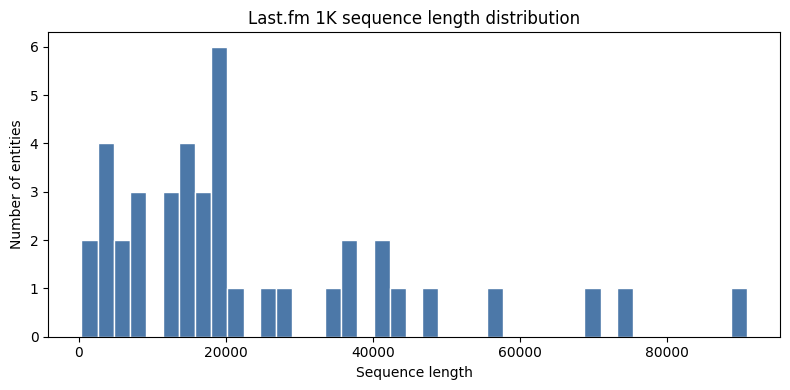

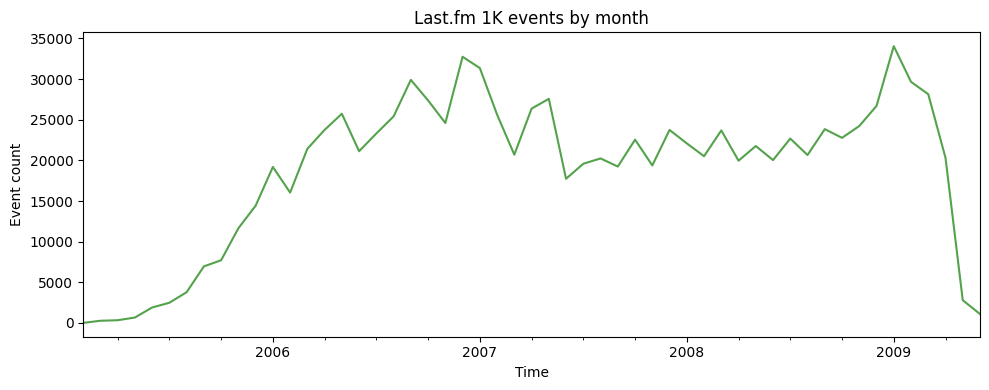

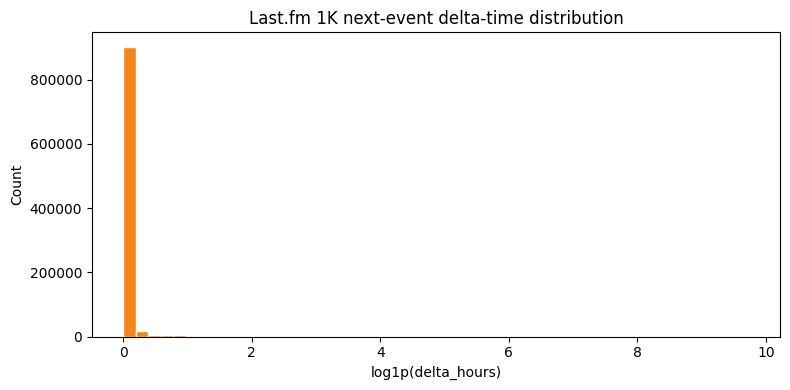

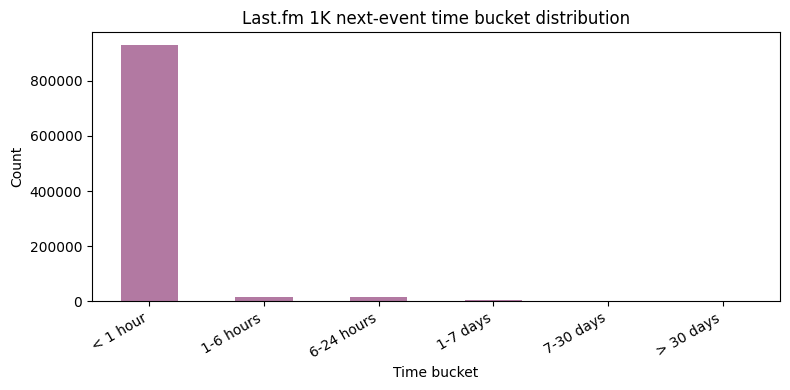

In [28]:
if lastfm is not None:
    plot_sequence_lengths(lastfm_lengths, "Last.fm 1K sequence length distribution")
    plot_events_over_time(lastfm, "datetime", "Last.fm 1K events by month", freq="M")
    if not lastfm_next.empty:
        plot_delta_distribution(lastfm_next["delta_hours"], "Last.fm 1K next-event delta-time distribution")
        plot_time_bucket_distribution(lastfm_next, "Last.fm 1K next-event time bucket distribution")

### Nhận xét về các phân phối của Last.fm

Các biểu đồ trên cho thấy Last.fm có đặc điểm rất phù hợp với bài toán temporal sequence recommendation, đặc biệt là dự đoán event kế tiếp trong cùng phiên nghe nhạc.

Biểu đồ sequence length cho thấy các user trong sample hiện tại có lịch sử nghe nhạc rất dài. Nhiều user có hàng chục nghìn listening events, thậm chí có user vượt trên 80,000 event. Điều này cho phép tạo số lượng lớn mẫu huấn luyện dạng `current event -> next event` hoặc `history -> next event`. Tuy nhiên, cần lưu ý rằng sample hiện tại chỉ gồm 41 user do notebook đọc 1,000,000 dòng đầu. Vì vậy, phân phối sequence length này phản ánh sample hiện tại, chưa chắc đại diện cho toàn bộ Last.fm 1K.

Biểu đồ event theo tháng cho thấy dữ liệu trải dài từ khoảng năm 2005 đến 2009, với số lượng event tăng dần ở giai đoạn đầu, duy trì khá cao trong giai đoạn 2006–2009, sau đó giảm mạnh ở cuối khoảng thời gian quan sát. Điều này cho thấy có temporal distribution shift và có thể do cách sample 1,000,000 dòng đầu, hoặc do hoạt động của nhóm user được lấy mẫu thay đổi theo thời gian. Nếu dùng Last.fm để modeling, nên dùng temporal split hoặc leave-last-out theo user thay vì random split.

Biểu đồ delta-time cho thấy phần lớn khoảng cách giữa hai event liên tiếp rất nhỏ. Hầu hết giá trị `log1p(delta_hours)` tập trung gần 0. Điều này phù hợp với thống kê trước đó: `median_delta_hours = 0.0667`, tức khoảng 4 phút, và `p90_delta_hours = 0.1383`, tức khoảng 8.3 phút. Đây là dấu hiệu cho thấy phần lớn event kế tiếp xảy ra trong cùng một listening session.

Biểu đồ time bucket cũng cho thấy đa số sample rơi vào bucket `< 1 hour`. Khác với MovieLens, điều này không nhất thiết là hạn chế. Trong MovieLens, timestamp ngắn thường phản ánh việc user nhập nhiều rating trong cùng một lúc, không chắc là thời điểm xem phim thật. Còn trong Last.fm, timestamp là listening log, nên các event cách nhau vài phút có thể phản ánh hành vi nghe nhạc thật: user nghe bài này rồi chuyển sang bài tiếp theo.

Tuy nhiên, nếu mục tiêu nghiên cứu là `next_time prediction`, không nên trộn toàn bộ within-session và cross-session event vào cùng một bài toán. Với Last.fm, nên tách hai setting: `within-session next-track/next-artist prediction` cho các event cách nhau ngắn, và `cross-session return-time prediction` cho các khoảng nghỉ dài hơn. Cách này giúp bài toán rõ ràng hơn và tránh để model chỉ học rằng event tiếp theo thường xảy ra trong vài phút.

Tóm lại, Last.fm là candidate mạnh cho temporal recommendation vì có event thật, timestamp có ý nghĩa và sequence dài. Dataset này đặc biệt phù hợp với `next_artist prediction`, `next_track prediction` và session-based listening recommendation. Tuy nhiên, các kết quả hiện tại nên được xem là sample-level feasibility vì notebook mới đọc 1,000,000 dòng đầu, chỉ bao phủ 41 user.

### 11.7 Last.fm Session Diagnostic

Kiểm tra liệu các event nghe nhạc liên tiếp chủ yếu là within-session hay cross-session. Last.fm phù hợp hơn MovieLens cho temporal recommendation vì timestamp thường phản ánh thời điểm nghe nhạc thực tế, không phải thời điểm nhập rating. Tuy nhiên, nếu phần lớn delta time nhỏ hơn 30 phút hoặc 1 giờ, nhiều event có thể thuộc cùng một listening session.

In [29]:
if "lastfm_next" in globals() and lastfm_next is not None and not lastfm_next.empty:
    lastfm_session_diagnostic = pd.DataFrame([{
        "dataset": "Last.fm 1K",
        "target_rows": len(lastfm_next),
        "within_30min_pct": round(float((lastfm_next["delta_hours"] < 0.5).mean() * 100), 3),
        "within_1hour_pct": round(float((lastfm_next["delta_hours"] < 1).mean() * 100), 3),
        "over_1day_pct": round(float((lastfm_next["delta_hours"] >= 24).mean() * 100), 3),
        "median_delta_hours": round(float(lastfm_next["delta_hours"].median()), 4),
        "p90_delta_hours": round(float(lastfm_next["delta_hours"].quantile(0.9)), 4),
    }])
    display(lastfm_session_diagnostic)
else:
    print("[WARN] lastfm_next is missing or empty; skip Last.fm session diagnostic.")

,dataset,target_rows,within_30min_pct,within_1hour_pct,over_1day_pct,median_delta_hours,p90_delta_hours
0,Last.fm 1K,968350,95.042,95.929,0.598,0.0667,0.1383


### Nhận xét về Last.fm Session Diagnostic

Session diagnostic cho thấy phần lớn các next-event trong Last.fm xảy ra trong khoảng thời gian rất ngắn. Cụ thể, 95.042% cặp event liên tiếp có `delta_hours < 0.5`, tức dưới 30 phút, và 95.929% có `delta_hours < 1`, tức dưới 1 giờ. Median `delta_hours = 0.0667`, tương đương khoảng 4 phút, còn p90 khoảng 8.3 phút.

Điều này cho thấy Last.fm sample hiện tại chủ yếu phản ánh within-session listening behavior: user nghe nhiều bài hoặc nhiều artist liên tiếp trong cùng một phiên nghe nhạc. Khác với MovieLens, đây không phải là hạn chế nghiêm trọng, vì timestamp của Last.fm thường là thời điểm nghe nhạc thực tế, không phải thời điểm user nhập rating hàng loạt.

Tuy nhiên, kết quả này cũng cho thấy nếu dùng Last.fm để dự đoán `next_time`, cần xác định rõ bài toán. Nếu mục tiêu là dự đoán bài hát/artist tiếp theo trong cùng phiên, Last.fm rất phù hợp. Nhưng nếu mục tiêu là dự đoán khi nào user quay lại sau một khoảng nghỉ dài, cần tách riêng cross-session events. Một cách đơn giản là xem các event có gap dưới 30 phút hoặc 1 giờ là within-session, còn các gap lớn hơn ngưỡng đó là session boundary.

Do đó, với Last.fm, hướng modeling hợp lý là chia thành hai bài toán: `within-session next-item prediction` và `cross-session return-time prediction`. Nếu trộn cả hai vào một target chung, model có thể chủ yếu học rằng event tiếp theo thường xảy ra trong vài phút, thay vì học được hành vi quay lại dài hạn.

## 12. MIND Exploration

MIND là news recommendation dataset dựa trên impression và click logs. Khác với Last.fm, MIND không chỉ là chuỗi tiêu thụ tự nhiên mà là dữ liệu user được hiển thị danh sách news candidate và click hoặc không click. Vì vậy MIND phù hợp với click prediction, ranking, session-based news recommendation và content-aware temporal recommendation.

### 12.1 Load MIND

Đọc `behaviors.tsv` và `news.tsv` cho train/dev/test, thêm cột `split`, rồi parse `time` sang `datetime`. MIND behaviors rất lớn, nên notebook đọc tối đa `MIND_BEHAVIOR_SAMPLE_NROWS` dòng mỗi split mặc định (100,000 dòng); metadata news có thể đọc full hoặc giới hạn bằng `MIND_NEWS_SAMPLE_NROWS`.


In [30]:
mind_train_behaviors, mind_train_news = load_mind_split(PATHS["mind_train"], "train")
mind_dev_behaviors, mind_dev_news = load_mind_split(PATHS["mind_dev"], "dev")
mind_test_behaviors, mind_test_news = load_mind_split(PATHS["mind_test"], "test")

display(pd.DataFrame([{
    "behavior_sample_nrows_limit": MIND_BEHAVIOR_SAMPLE_NROWS,
    "news_sample_nrows_limit": MIND_NEWS_SAMPLE_NROWS,
}]))

for behaviors in [mind_train_behaviors, mind_dev_behaviors, mind_test_behaviors]:
    if not behaviors.empty and "time" in behaviors.columns:
        behaviors["datetime"] = pd.to_datetime(behaviors["time"], errors="coerce")

mind_behavior_splits = {
    "train": mind_train_behaviors,
    "dev": mind_dev_behaviors,
    "test": mind_test_behaviors,
}
mind_news_splits = {
    "train": mind_train_news,
    "dev": mind_dev_news,
    "test": mind_test_news,
}

mind_split_summary = pd.DataFrame([
    {
        "split": split,
        "behavior_rows": len(mind_behavior_splits[split]),
        "news_rows": len(mind_news_splits[split]),
        "n_users": mind_behavior_splits[split]["user_id"].nunique() if "user_id" in mind_behavior_splits[split] else 0,
        "valid_datetime_rate": round(float(mind_behavior_splits[split]["datetime"].notna().mean()), 5) if "datetime" in mind_behavior_splits[split] and len(mind_behavior_splits[split]) else np.nan,
    }
    for split in ["train", "dev", "test"]
])

display(mind_split_summary)
if not mind_train_behaviors.empty:
    display(mind_train_behaviors.head(10))
if not mind_train_news.empty:
    display(mind_train_news.head(10))

[OK] MIND train behaviors: 100,000 rows, 5 columns
[OK] MIND train news: 101,527 rows, 8 columns
[OK] MIND dev behaviors: 100,000 rows, 5 columns
[OK] MIND dev news: 72,023 rows, 8 columns
[OK] MIND test behaviors: 100,000 rows, 5 columns
[OK] MIND test news: 120,959 rows, 8 columns


,behavior_sample_nrows_limit,news_sample_nrows_limit
0,100000,None


,split,behavior_rows,news_rows,n_users,valid_datetime_rate
0,train,100000,101527,90101,1.0
1,dev,100000,72023,88188,1.0
2,test,100000,120959,89728,1.0


,impression_id,user_id,time,history,impressions,split,datetime
0,1,U87243,11/10/2019 11:30:54 AM,N8668 N39081 N65259 N79529 N73408 N43615 N2937...,N78206-0 N26368-0 N7578-0 N58592-0 N19858-0 N5...,train,2019-11-10 11:30:54
1,2,U598644,11/12/2019 1:45:29 PM,N56056 N8726 N70353 N67998 N83823 N111108 N107...,N47996-0 N82719-0 N117066-0 N8491-0 N123784-0 ...,train,2019-11-12 13:45:29
2,3,U532401,11/13/2019 11:23:03 AM,N128643 N87446 N122948 N9375 N82348 N129412 N5...,N103852-0 N53474-0 N127836-0 N47925-1,train,2019-11-13 11:23:03
3,4,U593596,11/12/2019 12:24:09 PM,N31043 N39592 N4104 N8223 N114581 N92747 N1207...,N38902-0 N76434-0 N71593-0 N100073-0 N108736-0...,train,2019-11-12 12:24:09
4,5,U239687,11/14/2019 8:03:01 PM,N65250 N122359 N71723 N53796 N41663 N41484 N11...,N76209-0 N48841-0 N67937-0 N62235-0 N6307-0 N3...,train,2019-11-14 20:03:01
5,6,U521853,11/11/2019 10:47:31 AM,N8668 N29136 N128643 N9740 N9375 N52911 N12090...,N32154-0 N67747-0 N47257-0 N98178-1,train,2019-11-11 10:47:31
6,7,U687515,11/13/2019 5:31:06 AM,N91810 N96438 N104027 N53650,N12681-0 N10802-0 N93856-0 N96729-0 N46415-0 N...,train,2019-11-13 05:31:06
7,8,U192112,11/11/2019 9:06:04 AM,N9740 N59820 N18389 N23320 N12322 N9375 N11563...,N98178-1 N32154-0,train,2019-11-11 09:06:04
8,9,U530668,11/11/2019 2:10:15 PM,N67770 N65823 N35599 N8753 N126368 N32221 N844...,N49168-0 N123077-1 N55792-0 N47257-0,train,2019-11-11 14:10:15
9,10,U290933,11/10/2019 11:54:34 AM,N14678 N71340 N65259 N92085 N31043 N70385 N123...,N92691-0 N10654-0 N107542-0 N14509-0 N63262-0 ...,train,2019-11-10 11:54:34


,news_id,category,subcategory,title,abstract,url,title_entities,abstract_entities,split
0,N88753,lifestyle,lifestyleroyals,"The Brands Queen Elizabeth, Prince Charles, an...","Shop the notebooks, jackets, and more that the...",https://assets.msn.com/labs/mind/AAGH0ET.html,"[{""Label"": ""Prince Philip, Duke of Edinburgh"",...",[],train
1,N45436,news,newsscienceandtechnology,Walmart Slashes Prices on Last-Generation iPads,Apple's new iPad releases bring big deals on l...,https://assets.msn.com/labs/mind/AABmf2I.html,"[{""Label"": ""IPad"", ""Type"": ""J"", ""WikidataId"": ...","[{""Label"": ""IPad"", ""Type"": ""J"", ""WikidataId"": ...",train
2,N23144,health,weightloss,50 Worst Habits For Belly Fat,These seemingly harmless habits are holding yo...,https://assets.msn.com/labs/mind/AAB19MK.html,"[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik...","[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik...",train
3,N86255,health,medical,Dispose of unwanted prescription drugs during ...,NaN,https://assets.msn.com/labs/mind/AAISxPN.html,"[{""Label"": ""Drug Enforcement Administration"", ...",[],train
4,N93187,news,newsworld,The Cost of Trump's Aid Freeze in the Trenches...,Lt. Ivan Molchanets peeked over a parapet of s...,https://assets.msn.com/labs/mind/AAJgNsz.html,[],"[{""Label"": ""Ukraine"", ""Type"": ""G"", ""WikidataId...",train
5,N75236,health,voices,I Was An NBA Wife. Here's How It Affected My M...,"I felt like I was a fraud, and being an NBA wi...",https://assets.msn.com/labs/mind/AACk2N6.html,[],"[{""Label"": ""National Basketball Association"", ...",train
6,N99744,health,medical,"How to Get Rid of Skin Tags, According to a De...","They seem harmless, but there's a very good re...",https://assets.msn.com/labs/mind/AAAKEkt.html,"[{""Label"": ""Skin tag"", ""Type"": ""C"", ""WikidataI...","[{""Label"": ""Skin tag"", ""Type"": ""C"", ""WikidataI...",train
7,N5771,health,cardio,Check Houston traffic map for current road con...,NaN,https://assets.msn.com/labs/mind/AAEKnO1.html,"[{""Label"": ""Houston"", ""Type"": ""G"", ""WikidataId...",[],train
8,N124534,sports,football_nfl,Should NFL be able to fine players for critici...,Several fines came down against NFL players fo...,https://assets.msn.com/labs/mind/AAJ4lap.html,"[{""Label"": ""National Football League"", ""Type"":...","[{""Label"": ""National Football League"", ""Type"":...",train
9,N51947,news,newsscienceandtechnology,"How to record your screen on Windows, macOS, i...",The easiest way to record what's happening on ...,https://assets.msn.com/labs/mind/AADlomf.html,"[{""Label"": ""Microsoft Windows"", ""Type"": ""J"", ""...",[],train


### Nhận xét về MIND Load và Schema

MIND được load thành công từ ba split `train`, `dev` và `test`. Trong notebook hiện tại, mỗi split đọc 100,000 dòng behavior để tránh quá tải bộ nhớ, trong khi news metadata được đọc đầy đủ. Vì vậy, các thống kê về behavior nên được xem là sample-level exploration, không phải thống kê đầy đủ của toàn bộ MINDlarge.

Mỗi dòng trong `behaviors.tsv` biểu diễn một impression tại một thời điểm cụ thể. Cột `history` chứa các news mà user đã đọc trước đó, còn cột `impressions` chứa danh sách candidate news được hiển thị cho user kèm nhãn click. Vì vậy, MIND khác với Last.fm: nó không đơn thuần là chuỗi tiêu thụ tự nhiên, mà là dữ liệu ranking/click dựa trên candidate set.

News metadata trong `news.tsv` cung cấp nhiều thông tin nội dung như `category`, `subcategory`, `title`, `abstract`, `title_entities` và `abstract_entities`. Đây là điểm mạnh lớn của MIND so với các dataset chỉ có user-item-time, vì nó cho phép xây dựng content-aware recommendation hoặc mô hình ranking dựa trên cả hành vi user và nội dung news.

Do đó, MIND phù hợp nhất với các bài toán `click prediction`, `news ranking`, `session-based news recommendation` và `content-aware temporal recommendation`. Nếu dùng MIND cho `next-time prediction`, cần diễn giải cẩn thận vì timestamp gắn với impression/click session, không phải chuỗi tiêu thụ liên tục như Last.fm.

### 12.2 MIND Schema Summary

`behaviors.tsv` là interaction/impression log; `history` là các news đã đọc trước đó; `impressions` là candidate news được hiển thị với click label `-1` hoặc `-0`. `news.tsv` cung cấp content metadata như category, subcategory, title và abstract.

In [31]:
mind_behaviors_all = pd.concat([df for df in mind_behavior_splits.values() if not df.empty], ignore_index=True) if any(not df.empty for df in mind_behavior_splits.values()) else pd.DataFrame()
mind_news_all = pd.concat([df for df in mind_news_splits.values() if not df.empty], ignore_index=True) if any(not df.empty for df in mind_news_splits.values()) else pd.DataFrame()
if not mind_news_all.empty and "news_id" in mind_news_all.columns:
    mind_news_all = mind_news_all.drop_duplicates("news_id")

if not mind_behaviors_all.empty:
    display(summarize_dataframe(mind_behaviors_all))
if not mind_news_all.empty:
    display(summarize_dataframe(mind_news_all))

,column,dtype,missing,missing_pct,n_unique,example_value
0,impression_id,int64,0,0.000,100000,1
1,user_id,object,0,0.000,228323,U87243
2,time,object,0,0.000,219713,11/10/2019 11:30:54 AM
3,history,object,6201,2.067,247314,N8668 N39081 N65259 N79529 N73408 N43615 N2937...
4,impressions,object,0,0.000,277227,N78206-0 N26368-0 N7578-0 N58592-0 N19858-0 N5...
5,split,object,0,0.000,3,train
6,datetime,datetime64[ns],0,0.000,219713,2019-11-10 11:30:54


,column,dtype,missing,missing_pct,n_unique,example_value
0,news_id,object,0,0.000,130379,N88753
1,category,object,0,0.000,18,lifestyle
2,subcategory,object,0,0.000,293,lifestyleroyals
3,title,object,0,0.000,126169,"The Brands Queen Elizabeth, Prince Charles, an..."
4,abstract,object,7249,5.560,117202,"Shop the notebooks, jackets, and more that the..."
5,url,object,1,0.001,130376,https://assets.msn.com/labs/mind/AAGH0ET.html
6,title_entities,object,6,0.005,85024,"[{""Label"": ""Prince Philip, Duke of Edinburgh"",..."
7,abstract_entities,object,9,0.007,92532,[]
8,split,object,0,0.000,3,train


### 12.3 Parse MIND Impressions

Mỗi dòng behavior chứa nhiều candidate dạng `news_id-label`. Cell này explode thành mỗi row là một candidate impression; với test nếu không có label thì `clicked = NaN`.

In [32]:
mind_train_impressions = explode_mind_impressions(mind_train_behaviors)
mind_dev_impressions = explode_mind_impressions(mind_dev_behaviors)
mind_test_impressions = explode_mind_impressions(mind_test_behaviors)

def mind_impression_summary(impressions: pd.DataFrame, split: str) -> dict[str, Any]:
    if impressions.empty:
        return {"split": split, "n_candidate_impressions": 0, "n_users": 0, "n_news": 0, "click_rate": np.nan}
    return {
        "split": split,
        "n_candidate_impressions": len(impressions),
        "n_users": impressions["user_id"].nunique(),
        "n_news": impressions["news_id"].nunique(),
        "click_rate": impressions["clicked"].mean(),
    }

if not mind_train_impressions.empty:
    display(mind_train_impressions.head(10))

display(pd.DataFrame([
    mind_impression_summary(mind_train_impressions, "train"),
    mind_impression_summary(mind_dev_impressions, "dev"),
    mind_impression_summary(mind_test_impressions, "test"),
]))

,impression_id,user_id,datetime,news_id,clicked,split
0,1,U87243,2019-11-10 11:30:54,N78206,0,train
1,1,U87243,2019-11-10 11:30:54,N26368,0,train
2,1,U87243,2019-11-10 11:30:54,N7578,0,train
3,1,U87243,2019-11-10 11:30:54,N58592,0,train
4,1,U87243,2019-11-10 11:30:54,N19858,0,train
5,1,U87243,2019-11-10 11:30:54,N58258,0,train
6,1,U87243,2019-11-10 11:30:54,N18478,0,train
7,1,U87243,2019-11-10 11:30:54,N2591,0,train
8,1,U87243,2019-11-10 11:30:54,N97778,0,train
9,1,U87243,2019-11-10 11:30:54,N32954,0,train


,split,n_candidate_impressions,n_users,n_news,click_rate
0,train,3741172,90101,18866,0.040722
1,dev,3732271,88188,5602,0.040842
2,test,3935120,89728,21448,NaN


### Nhận xét về MIND Schema và Impression Parsing

MIND có cấu trúc khác với các dataset sequence như Last.fm. Mỗi dòng trong `behaviors.tsv` là một impression tại một thời điểm cụ thể, trong đó user được hiển thị một danh sách candidate news và có thể click một hoặc nhiều news. Cột `history` biểu diễn các news user đã đọc trước đó, còn cột `impressions` chứa các candidate news kèm label click.

Schema của behavior log khá sạch: `user_id`, `time`, `impressions` và `datetime` không bị missing. Cột `history` có một tỷ lệ missing nhỏ, có thể xem là nhóm user không có lịch sử hoặc cold-start users. News metadata cũng khá đầy đủ, đặc biệt là `category`, `subcategory` và `title`; cột `abstract` có một phần missing nhưng không ảnh hưởng nghiêm trọng đến exploration.

Sau khi explode `impressions`, mỗi candidate news trở thành một dòng riêng với label `clicked`. Kết quả cho thấy train split có hơn 3.7 triệu candidate impressions và click rate khoảng 4.07%. Điều này xác nhận rằng MIND là dataset ranking/click prediction với class imbalance rõ rệt: phần lớn candidate là negative và chỉ một tỷ lệ nhỏ được click.

Do đó, MIND phù hợp nhất với bài toán `click prediction`, `news ranking`, và `content-aware recommendation`, hơn là bài toán pure next-time prediction. Nếu dùng MIND cho temporal recommendation, timestamp nên được hiểu là thời điểm impression/click session, không phải chuỗi tiêu thụ liên tục như Last.fm.

### 12.4 MIND Ranking Diagnostic

Vì MIND là impression/click-ranking dataset, cần kiểm tra số candidate mỗi impression, click rate và history length trước khi diễn giải nó như chuỗi next-event.

In [33]:
if "mind_train_behaviors" in globals() and mind_train_behaviors is not None and not mind_train_behaviors.empty:
    mind_train_behaviors = mind_train_behaviors.copy()
    mind_train_behaviors["history_length"] = mind_train_behaviors["history"].apply(safe_token_count)

if "mind_train_impressions" in globals() and mind_train_impressions is not None and not mind_train_impressions.empty:
    candidates_per_impression = mind_train_impressions.groupby("impression_id").size()
    mind_ranking_diagnostic = pd.DataFrame([{
        "split": "train",
        "n_impressions": mind_train_impressions["impression_id"].nunique(),
        "n_candidate_rows": len(mind_train_impressions),
        "avg_candidates_per_impression": round(float(candidates_per_impression.mean()), 3),
        "median_candidates_per_impression": round(float(candidates_per_impression.median()), 3),
        "click_rate": round(float(mind_train_impressions["clicked"].mean()), 5)
            if "clicked" in mind_train_impressions.columns and mind_train_impressions["clicked"].notna().any()
            else np.nan,
        "avg_history_length": round(float(mind_train_behaviors["history_length"].mean()), 3)
            if "history_length" in mind_train_behaviors.columns
            else np.nan,
    }])
    display(mind_ranking_diagnostic)
else:
    print("[WARN] mind_train_impressions is missing or empty; skip MIND ranking diagnostic.")

,split,n_impressions,n_candidate_rows,avg_candidates_per_impression,median_candidates_per_impression,click_rate,avg_history_length
0,train,100000,3741172,37.412,25.0,0.04072,33.042


### Nhận xét về MIND Ranking Diagnostic

Ranking diagnostic xác nhận rằng MIND phù hợp nhất với bài toán click prediction và news ranking. Trong train sample, có 100,000 impressions được explode thành hơn 3.7 triệu candidate rows. Mỗi impression có trung bình khoảng 37 candidate news, với median là 25 candidate. Điều này cho thấy MIND không phải là chuỗi next-event đơn giản, mà là bài toán xếp hạng một tập candidate news được hiển thị cho user tại một thời điểm cụ thể.

Click rate chỉ khoảng 4.07%, nghĩa là dữ liệu bị mất cân bằng mạnh: phần lớn candidate news không được click, chỉ một tỷ lệ nhỏ là positive. Vì vậy, nếu dùng MIND để train model, không nên đánh giá bằng accuracy đơn thuần. Các metric phù hợp hơn là AUC, MRR, nDCG@K, HitRate@K hoặc các ranking metrics theo từng impression.

Cột `avg_history_length = 33.042` cho thấy mỗi user trong sample có trung bình khoảng 33 news đã đọc trong lịch sử. Đây là tín hiệu tốt cho personalization, vì model có thể dùng `history` để biểu diễn sở thích user. Ngoài ra, MIND còn có metadata như category, subcategory, title và abstract, nên rất phù hợp với content-aware recommendation.

Tóm lại, MIND nên được dùng cho `click prediction`, `candidate ranking`, hoặc `content-aware news recommendation`. Nếu muốn dùng yếu tố thời gian, timestamp nên được xem là ngữ cảnh của impression/click session, không nên diễn giải MIND như một chuỗi tiêu thụ tự nhiên giống Last.fm.

### 12.5 MIND Click Sequence Construction

Dùng clicked-only event log từ train để kiểm tra liệu MIND có đủ repeated clicks cho next-click sequence hay nên ưu tiên session/impression ranking.

In [34]:
mind_clicked = pd.DataFrame()
mind_sequence_summary = pd.DataFrame()
mind_lengths = pd.Series(dtype="int64")
mind_next = pd.DataFrame()
mind_next_event_sample = pd.DataFrame()
mind_temporal_report = {}

if not mind_train_impressions.empty:
    mind_clicked = mind_train_impressions[mind_train_impressions["clicked"] == 1].copy()
    mind_clicked = mind_clicked.rename(columns={"news_id": "item_id"})

if not mind_clicked.empty and {"user_id", "item_id", "datetime"}.issubset(mind_clicked.columns):
    mind_sequence_summary, mind_lengths = analyze_sequence_feasibility(
        mind_clicked.dropna(subset=["user_id", "item_id", "datetime"]),
        "MIND clicked news",
        "user_id",
        "item_id",
        "datetime",
        recommendation_like=True,
    )
    display(mind_sequence_summary)
    display(threshold_coverage_table(mind_lengths))
else:
    print("No clicked MIND train events available for sequence feasibility.")

,dataset,entity_col,item_col,time_col,n_rows,n_entities,n_items,median_sequence_length,entities_with_2plus_events_pct,entities_with_5plus_events_pct,can_create_next_item,can_create_next_time,main_limitation
0,MIND clicked news,user_id,item_id,datetime,152347,90101,6642,1.0,34.421,4.286,Limited,Limited,"Repeated entities exist, but sample may be spa..."


,threshold,entities_count,entities_pct
0,2,31014,34.421
1,3,13721,15.228
2,5,3862,4.286
3,10,402,0.446


### Nhận xét về MIND Click Sequence Feasibility

Phần này kiểm tra liệu MIND có thể được chuyển thành bài toán `next-click sequence prediction` hay không bằng cách chỉ giữ các candidate news được click trong train split. Kết quả cho thấy có 152,347 clicked events từ 90,101 users và 6,642 clicked news.

Tuy nhiên, median sequence length chỉ bằng 1.0, nghĩa là user điển hình trong sample chỉ có một clicked event. Chỉ 34.421% user có ít nhất 2 clicks, 4.286% user có ít nhất 5 clicks, và chỉ 0.446% user có ít nhất 10 clicks. Điều này cho thấy clicked-only sequence khá sparse, đặc biệt nếu muốn huấn luyện mô hình sequence dài.

Với bài toán next-click, user có một click không thể tạo target vì không có click kế tiếp. User có hai clicks chỉ tạo được một mẫu huấn luyện. Do đó, mặc dù MIND có thể tạo được một số next-click samples, hướng này chỉ nên được xem là `Limited`.

Kết quả này củng cố rằng MIND phù hợp hơn với formulation gốc của nó: `user history + candidate impressions -> clicked candidate`. Nói cách khác, MIND nên được ưu tiên cho click prediction, candidate ranking và content-aware news recommendation hơn là pure next-click sequence prediction.

Nếu vẫn muốn dùng MIND theo hướng temporal sequence, nên dùng `history` như input quá khứ và `impressions` như candidate set tại thời điểm hiện tại, thay vì chỉ reconstruct sequence từ clicked-only logs.

### 12.6 MIND Next-Click Target Construction

Target ở đây là next clicked news, không phải next impression. MIND phù hợp hơn với ranking/click prediction so với pure next-time prediction; timestamp gắn với impression/click session nên cần cẩn thận khi diễn giải `delta_time`.

In [35]:
if not mind_clicked.empty and {"user_id", "item_id", "datetime"}.issubset(mind_clicked.columns):
    mind_next = add_time_bucket(
        create_next_event_targets(
            mind_clicked.dropna(subset=["user_id", "item_id", "datetime"]),
            "user_id",
            "item_id",
            "datetime",
        )
    )
    mind_next_event_sample = sample_next_event_table(mind_next, n=10)
    display(target_quality_summary(mind_next))
    display(mind_next_event_sample)

,target_rows,median_delta_hours,p90_delta_hours,max_delta_days,n_time_buckets
0,62246,0.0,22.779,5.8673,4


,entity_id,history_length,current_item_or_event,current_time,next_item_or_event,next_time,delta_hours,time_bucket
0,U1,1,N87684,2019-11-12 13:46:51,N89932,2019-11-12 16:33:21,2.775,1-6 hours
1,U100010,1,N110303,2019-11-12 10:04:18,N96373,2019-11-12 10:04:18,0.000,< 1 hour
2,U100038,1,N41315,2019-11-13 08:14:17,N91822,2019-11-13 08:14:17,0.000,< 1 hour
3,U100070,1,N4858,2019-11-10 03:33:44,N76810,2019-11-10 03:33:44,0.000,< 1 hour
4,U100084,1,N41101,2019-11-12 12:26:38,N18947,2019-11-12 12:26:38,0.000,< 1 hour
5,U100103,1,N114935,2019-11-12 11:07:57,N18861,2019-11-12 11:07:57,0.000,< 1 hour
6,U100106,1,N91865,2019-11-14 11:26:30,N116905,2019-11-14 11:26:30,0.000,< 1 hour
7,U100106,2,N116905,2019-11-14 11:26:30,N67937,2019-11-14 11:26:30,0.000,< 1 hour
8,U100137,1,N97722,2019-11-13 11:53:13,N39403,2019-11-13 11:53:13,0.000,< 1 hour
9,U100152,1,N109796,2019-11-12 18:23:08,N34919,2019-11-12 18:23:08,0.000,< 1 hour


### Nhận xét về MIND Next-Click Target

Phần này tạo target dạng `current clicked news -> next clicked news` từ clicked-only event log. Notebook tạo được 62,246 target rows, cho thấy MIND vẫn có thể được chuyển thành một bài toán next-click ở mức cơ bản.

Tuy nhiên, `median_delta_hours = 0.0`, nghĩa là nhiều clicked events liên tiếp có cùng timestamp. Điều này phản ánh đặc thù của MIND: timestamp gắn với impression/click session, không phải chuỗi tiêu thụ liên tục như Last.fm. Một impression có thể chứa nhiều clicked news hoặc nhiều click được ghi nhận tại cùng một thời điểm, khiến các next-click có `delta_time = 0`.

Do đó, không nên diễn giải MIND như một bài toán pure next-time prediction. Target `next clicked news` có thể dùng để kiểm tra sequence feasibility, nhưng hướng chính hợp lý hơn vẫn là `user history + candidate impressions -> clicked candidate`.

Kết quả này củng cố kết luận rằng MIND phù hợp với click prediction, ranking và content-aware news recommendation hơn là next-event time prediction.

### 12.7 MIND Content Metadata Summary

Join clicked/impression events với `news.tsv` để xem category/subcategory. Đây là lợi thế lớn của MIND cho content-aware temporal recommendation.

In [36]:
mind_clicked_with_meta = pd.DataFrame()
if not mind_news_all.empty and not mind_clicked.empty:
    mind_clicked_with_meta = mind_clicked.merge(mind_news_all, left_on="item_id", right_on="news_id", how="left")

if not mind_news_all.empty and "category" in mind_news_all.columns:
    display(mind_news_all["category"].value_counts().head(20))
if not mind_clicked_with_meta.empty and "category" in mind_clicked_with_meta.columns:
    display(mind_clicked_with_meta["category"].value_counts().head(20))
    display(mind_clicked_with_meta[["user_id", "item_id", "datetime", "category", "subcategory", "title"]].head(10))

category
sports           41170
news             39649
finance           7557
travel            6473
video             6178
lifestyle         5687
foodanddrink      5592
weather           5225
autos             3769
health            3601
music             1693
tv                1638
movies            1015
entertainment      995
kids               133
middleeast           2
games                1
northamerica         1
Name: count, dtype: int64

category
news             44900
sports           17773
lifestyle        17220
finance          13218
music            10327
tv                9286
health            7131
foodanddrink      7079
entertainment     6867
travel            5366
autos             4728
weather           2942
video             2821
movies            2681
kids                 7
northamerica         1
Name: count, dtype: int64

,user_id,item_id,datetime,category,subcategory,title
0,U87243,N94157,2019-11-10 11:30:54,movies,movies-celebrity,"John Travolta Shares Rare Photo of Son Ben, 8,..."
1,U87243,N78699,2019-11-10 11:30:54,news,newspolitics,Rep. Ilhan Omar is accused of 'dog whistle' an...
2,U87243,N71090,2019-11-10 11:30:54,news,newsus,Missing California hiker found dead at top of ...
3,U87243,N31174,2019-11-10 11:30:54,music,musicnews,Broadway Actress Laurel Griggs Dies at Age 13
4,U598644,N25587,2019-11-12 13:45:29,news,newsus,Sen. Menendez: 'It's sickening' to hear Trump ...
5,U598644,N36266,2019-11-12 13:45:29,music,music-celebrity,Neil Young Says U.S. Citizenship Application D...
6,U532401,N47925,2019-11-13 11:23:03,news,newscrime,Three school workers charged in death of speci...
7,U593596,N114935,2019-11-12 12:24:09,foodanddrink,foodnews,Wendy's Is Rolling Out Birthday Cake Frostys f...
8,U239687,N86258,2019-11-14 20:03:01,video,animals,Student's drone footage shows whale swimming a...
9,U521853,N98178,2019-11-11 10:47:31,sports,football_nfl,"Charles Rogers, former Michigan State football..."


### Nhận xét về MIND Content Metadata

Phần join clicked events với `news.tsv` cho thấy MIND có lợi thế lớn về content metadata. Mỗi clicked news có thể được gắn với `category`, `subcategory`, `title`, `abstract` và entity information. Đây là điểm khác biệt lớn so với các dataset chỉ có user-item-time.

Category distribution cho thấy các nhóm như `sports`, `news`, `finance`, `travel`, `lifestyle`, `health` và `foodanddrink` xuất hiện nhiều trong clicked events. Điều này cho phép xây dựng các feature nội dung, ví dụ user thường click category nào, subcategory nào, hoặc embedding từ title/abstract.

Do đó, MIND rất phù hợp với content-aware news recommendation. Input hợp lý không chỉ là lịch sử click của user, mà còn là metadata của candidate news. Một formulation phù hợp là: dùng `history`, thông tin thời gian, category/subcategory và title/abstract của candidate để dự đoán candidate nào được click trong impression.

Tóm lại, MIND nên được xem là dataset mạnh cho `content-aware ranking`, không phải dataset chính cho `next-time prediction`.

### 12.8 MIND Plots

Các plot dưới đây tập trung vào clicked sequence, next-click delta-time, time bucket, volume theo ngày và top 20 category.

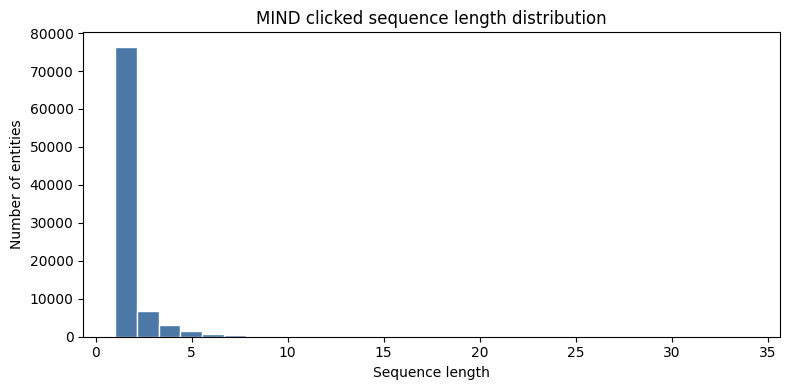

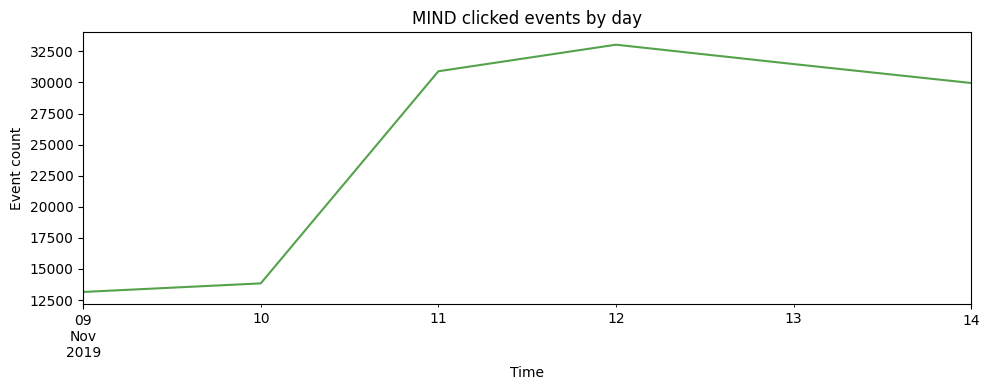

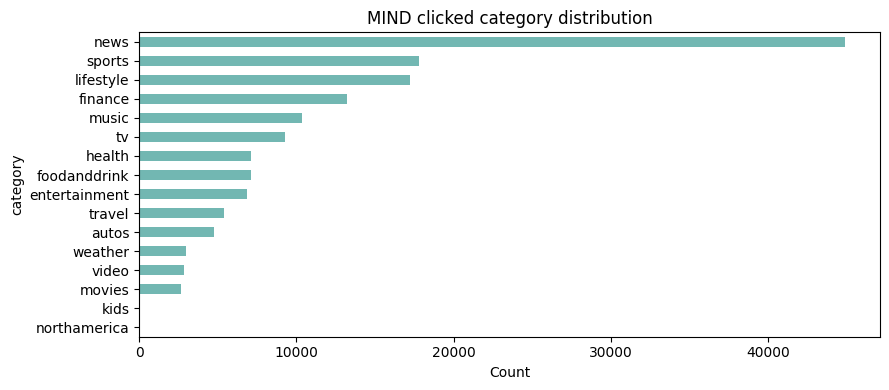

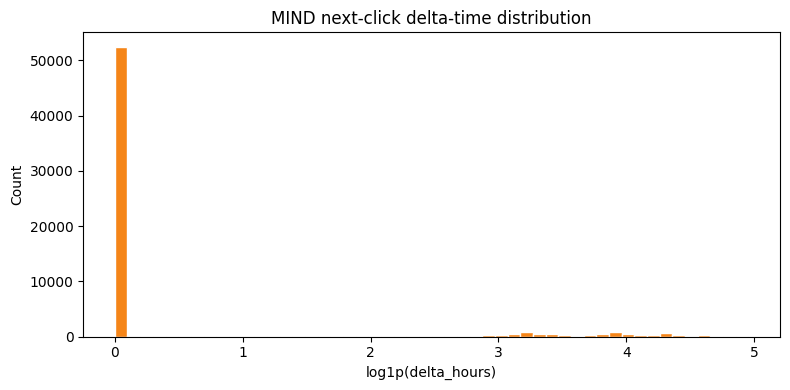

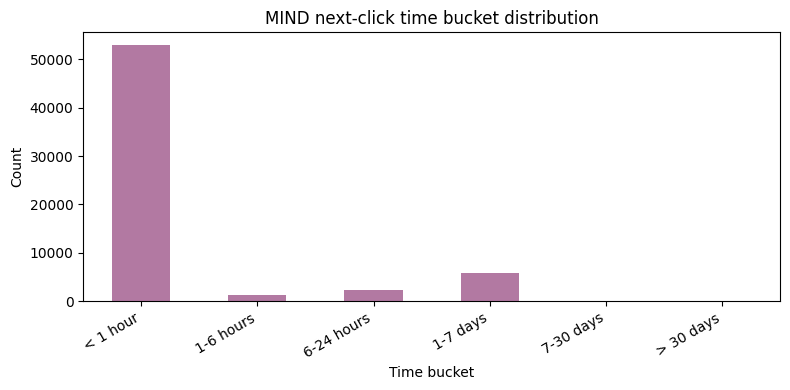

In [37]:
if not mind_clicked.empty:
    plot_sequence_lengths(mind_lengths, "MIND clicked sequence length distribution")
    plot_events_over_time(mind_clicked, "datetime", "MIND clicked events by day", freq="D")
    if not mind_clicked_with_meta.empty and "category" in mind_clicked_with_meta.columns:
        plot_top_value_counts(mind_clicked_with_meta["category"], "MIND clicked category distribution", top_n=20)
    if not mind_next.empty:
        plot_delta_distribution(mind_next["delta_hours"], "MIND next-click delta-time distribution")
        plot_time_bucket_distribution(mind_next, "MIND next-click time bucket distribution")

### Nhận xét về các phân phối của MIND

Các biểu đồ trên cho thấy MIND có thể được chuyển thành clicked-only sequence, nhưng cấu trúc này không phải hướng mạnh nhất của dataset.

Biểu đồ sequence length cho thấy phần lớn user chỉ có rất ít clicked events trong sample. Đa số user có sequence length bằng 1, trong khi số user có chuỗi dài hơn giảm rất nhanh. Điều này khớp với thống kê trước đó: median sequence length chỉ bằng 1.0, chỉ 34.421% user có ít nhất 2 clicks, 4.286% user có ít nhất 5 clicks, và chỉ 0.446% user có ít nhất 10 clicks. Vì vậy, nếu chỉ dùng clicked-only log để làm next-click sequence prediction, dữ liệu khá sparse.

Biểu đồ next-click time bucket cho thấy phần lớn target rơi vào bucket `< 1 hour`. Bên cạnh đó, vẫn có một lượng nhỏ target nằm ở các bucket dài hơn như `1-6 hours`, `6-24 hours` và `1-7 days`. Tuy nhiên, cần cẩn thận khi diễn giải thời gian trong MIND, vì timestamp gắn với impression/click log. Nhiều clicked events có thể cùng timestamp do thuộc cùng một impression hoặc cùng một phiên hiển thị news.

Biểu đồ delta-time cũng cho thấy phần lớn giá trị tập trung gần 0. Điều này củng cố rằng MIND không giống Last.fm. Trong Last.fm, các event gần nhau thường phản ánh hành vi nghe nhạc liên tục. Trong MIND, các click gần nhau có thể phản ánh nhiều clicked news trong cùng impression/session hoặc các impression xảy ra gần nhau. Vì vậy, `delta_time` trong MIND không nên được dùng như target chính cho next-time prediction.

Biểu đồ clicked events by day cho thấy dữ liệu trong sample tập trung trong một khoảng thời gian ngắn, khoảng vài ngày trong tháng 11/2019. Điều này phù hợp với bản chất của MIND benchmark, nhưng cũng có nghĩa là span thời gian hạn chế hơn so với Last.fm hoặc các e-commerce behavior datasets. Nếu dùng MIND, nên giữ split train/dev/test gốc hoặc temporal split theo benchmark, thay vì random split.

Tóm lại, MIND có thể dùng để kiểm tra next-click sequence ở mức giới hạn, nhưng hướng chính hợp lý hơn vẫn là `user history + candidate impressions -> clicked candidate`. Dataset này đặc biệt phù hợp với click prediction, ranking và content-aware news recommendation nhờ có candidate set, click label và metadata như category, subcategory, title, abstract.

## 13. RetailRocket Exploration

RetailRocket là e-commerce behavior dataset với các event như `view`, `addtocart` và `transaction`. Dataset này phù hợp trực tiếp với hướng purchase-aware recommendation vì timestamp gắn với hành vi thật trên website, không phải rating/review timestamp. Mục tiêu phần này là kiểm tra khả năng tạo sequence, next-event target, và feasibility cho các bài toán purchase-related như next transaction, will-buy và time-to-buy.

### 13.1 RetailRocket Load

Đọc event log chính, category tree và item properties nếu tồn tại. Event log được chuẩn hóa về `user_id`, `item_id`, `event_type`, `transaction_id`, và `datetime`. Các file event/item properties có thể lớn, nên notebook dùng `RETAILROCKET_EVENTS_SAMPLE_NROWS` và `RETAILROCKET_ITEM_PROPERTIES_SAMPLE_NROWS` mặc định; đặt thành `None` để đọc full.


In [38]:
retailrocket = safe_read_file(
    PATHS["retailrocket_events"],
    pd.read_csv,
    dataset_name="RetailRocket events",
    nrows=RETAILROCKET_EVENTS_SAMPLE_NROWS,
)
retailrocket_category_tree = safe_read_file(PATHS["retailrocket_category_tree"], pd.read_csv, dataset_name="RetailRocket category tree")
retailrocket_item_properties = None
retailrocket_sequence_summary = pd.DataFrame()
retailrocket_lengths = pd.Series(dtype="int64")
retailrocket_next_behavior = pd.DataFrame()
retailrocket_time_summary = pd.DataFrame()
retailrocket_temporal_report = {}
rr_transition_counts = pd.DataFrame()

if retailrocket is not None:
    display(pd.DataFrame([{"events_sample_nrows_limit": RETAILROCKET_EVENTS_SAMPLE_NROWS, "loaded_event_rows": len(retailrocket)}]))
    retailrocket = retailrocket.rename(columns={
        "visitorid": "user_id",
        "itemid": "item_id",
        "event": "event_type",
        "transactionid": "transaction_id",
    })
    if "timestamp" in retailrocket.columns:
        retailrocket["datetime"] = pd.to_datetime(retailrocket["timestamp"], unit="ms", errors="coerce")
    display(retailrocket.head(10))
    display(summarize_dataframe(retailrocket))

if retailrocket_category_tree is not None:
    display(retailrocket_category_tree.head(10))

item_prop_frames = []
for prop_path in [PATHS["retailrocket_item_properties_part1"], PATHS["retailrocket_item_properties_part2"]]:
    prop_df = safe_read_file(
        prop_path,
        pd.read_csv,
        dataset_name=f"RetailRocket {prop_path.name}",
        nrows=RETAILROCKET_ITEM_PROPERTIES_SAMPLE_NROWS,
    )
    if prop_df is not None:
        item_prop_frames.append(prop_df)

if item_prop_frames:
    display(pd.DataFrame([{"item_properties_sample_nrows_limit_per_file": RETAILROCKET_ITEM_PROPERTIES_SAMPLE_NROWS}]))
    retailrocket_item_properties = pd.concat(item_prop_frames, ignore_index=True)
    retailrocket_item_properties = retailrocket_item_properties.rename(columns={"itemid": "item_id"})
    if "timestamp" in retailrocket_item_properties.columns:
        retailrocket_item_properties["datetime"] = pd.to_datetime(retailrocket_item_properties["timestamp"], unit="ms", errors="coerce")
    display(retailrocket_item_properties.head(10))

[OK] RetailRocket events: 2,000,000 rows, 5 columns
[OK] RetailRocket category tree: 1,669 rows, 2 columns


,events_sample_nrows_limit,loaded_event_rows
0,2000000,2000000


,timestamp,user_id,event_type,item_id,transaction_id,datetime
0,1433221332117,257597,view,355908,NaN,2015-06-02 05:02:12.117
1,1433224214164,992329,view,248676,NaN,2015-06-02 05:50:14.164
2,1433221999827,111016,view,318965,NaN,2015-06-02 05:13:19.827
3,1433221955914,483717,view,253185,NaN,2015-06-02 05:12:35.914
4,1433221337106,951259,view,367447,NaN,2015-06-02 05:02:17.106
5,1433224086234,972639,view,22556,NaN,2015-06-02 05:48:06.234
6,1433221923240,810725,view,443030,NaN,2015-06-02 05:12:03.240
7,1433223291897,794181,view,439202,NaN,2015-06-02 05:34:51.897
8,1433220899221,824915,view,428805,NaN,2015-06-02 04:54:59.221
9,1433221204592,339335,view,82389,NaN,2015-06-02 05:00:04.592


,column,dtype,missing,missing_pct,n_unique,example_value
0,timestamp,int64,0,0.000,1996087,1433221332117
1,user_id,int64,0,0.000,1038165,257597
2,event_type,object,0,0.000,3,view
3,item_id,int64,0,0.000,209833,355908
4,transaction_id,float64,1983765,99.188,12905,4000.0
5,datetime,datetime64[ns],0,0.000,1996087,2015-06-02 05:02:12.117000


,categoryid,parentid
0,1016,213.0
1,809,169.0
2,570,9.0
3,1691,885.0
4,536,1691.0
5,231,NaN
6,542,378.0
7,1146,542.0
8,1140,542.0
9,1479,1537.0


[OK] RetailRocket item_properties_part1.csv: 500,000 rows, 4 columns
[OK] RetailRocket item_properties_part2.csv: 500,000 rows, 4 columns


,item_properties_sample_nrows_limit_per_file
0,500000


,timestamp,item_id,property,value,datetime
0,1435460400000,460429,categoryid,1338,2015-06-28 03:00:00
1,1441508400000,206783,888,1116713 960601 n277.200,2015-09-06 03:00:00
2,1439089200000,395014,400,n552.000 639502 n720.000 424566,2015-08-09 03:00:00
3,1431226800000,59481,790,n15360.000,2015-05-10 03:00:00
4,1431831600000,156781,917,828513,2015-05-17 03:00:00
5,1436065200000,285026,available,0,2015-07-05 03:00:00
6,1434250800000,89534,213,1121373,2015-06-14 03:00:00
7,1431831600000,264312,6,319724,2015-05-17 03:00:00
8,1433646000000,229370,202,1330310,2015-06-07 03:00:00
9,1434250800000,98113,451,1141052 n48.000,2015-06-14 03:00:00


### Nhận xét về RetailRocket Load và Schema

RetailRocket được load thành công với 2,000,000 event rows trong sample hiện tại. Event log đã được chuẩn hóa về các cột chính gồm `user_id`, `item_id`, `event_type`, `transaction_id` và `datetime`. Đây là schema rất phù hợp cho purchase-aware recommendation vì mỗi dòng biểu diễn một hành vi thật của user trên website tại một thời điểm cụ thể.

Khác với MovieLens, timestamp trong RetailRocket không phải thời điểm nhập rating; và khác với Amazon review sample, timestamp cũng không phải thời điểm viết review. Ở đây, timestamp gắn trực tiếp với hành vi như `view`, `addtocart` hoặc `transaction`, nên có ý nghĩa tốt hơn cho các bài toán temporal behavior và time-to-buy prediction.

Cột `event_type` có ba loại hành vi chính: `view`, `addtocart` và `transaction`. Trong đó, `view` và `addtocart` có thể được dùng làm input behavior, còn `transaction` có thể được xem là positive purchase event. Vì vậy, RetailRocket phù hợp với các task như `next_behavior prediction`, `will_buy prediction`, `next_transaction_item`, hoặc `time_to_transaction`.

Cột `transaction_id` có tỷ lệ missing rất cao, nhưng đây không phải lỗi dữ liệu. Lý do là chỉ các event thuộc loại `transaction` mới có transaction id, còn các event `view` và `addtocart` không có giá trị này. Do đó, tỷ lệ missing cao của `transaction_id` phản ánh việc purchase event là minority class trong behavior log.

Ngoài event log, notebook cũng load được `category_tree.csv` và item properties. Các bảng này có thể dùng để bổ sung item metadata như category, availability hoặc property-value features. Tuy nhiên, với bước feasibility hiện tại, `events.csv` là phần quan trọng nhất để đánh giá sequence, next-event target và purchase feasibility.

### 13.2 RetailRocket Schema and Event Summary

`view` và `addtocart` có thể dùng làm input behavior; `transaction` là positive purchase event. Đây là dataset phù hợp hơn Amazon review cho buy-event prediction vì timestamp là hành vi trên site thay vì thời điểm viết review.

In [39]:
if retailrocket is not None and not retailrocket.empty:
    display(summarize_dataframe(retailrocket))
    retailrocket_event_counts = retailrocket["event_type"].value_counts().reset_index()
    retailrocket_event_counts.columns = ["event_type", "count"]
    display(retailrocket_event_counts)
    retailrocket_basic_summary = pd.DataFrame([{
        "n_events": len(retailrocket),
        "n_users": retailrocket["user_id"].nunique(),
        "n_items": retailrocket["item_id"].nunique(),
        "n_event_types": retailrocket["event_type"].nunique(),
        "n_view_events": int((retailrocket["event_type"] == "view").sum()),
        "n_addtocart_events": int((retailrocket["event_type"] == "addtocart").sum()),
        "n_transaction_events": int((retailrocket["event_type"] == "transaction").sum()),
        "transaction_event_rate_pct": round(float((retailrocket["event_type"] == "transaction").mean() * 100), 4),
        "n_transaction_users": retailrocket.loc[retailrocket["event_type"] == "transaction", "user_id"].nunique(),
    }])
    display(retailrocket_basic_summary)

,column,dtype,missing,missing_pct,n_unique,example_value
0,timestamp,int64,0,0.000,1996087,1433221332117
1,user_id,int64,0,0.000,1038165,257597
2,event_type,object,0,0.000,3,view
3,item_id,int64,0,0.000,209833,355908
4,transaction_id,float64,1983765,99.188,12905,4000.0
5,datetime,datetime64[ns],0,0.000,1996087,2015-06-02 05:02:12.117000


,event_type,count
0,view,1933214
1,addtocart,50551
2,transaction,16235


,n_events,n_users,n_items,n_event_types,n_view_events,n_addtocart_events,n_transaction_events,transaction_event_rate_pct,n_transaction_users
0,2000000,1038165,209833,3,1933214,50551,16235,0.8117,8674


### 13.3 RetailRocket Timestamp Analysis

Timestamp là thời điểm event xảy ra trên website. Cần sort theo `user_id`, `datetime` trước khi tạo sequence và nên dùng temporal split hoặc leave-last-out theo visitor.

In [40]:
if retailrocket is not None and not retailrocket.empty and "datetime" in retailrocket.columns:
    _, retailrocket_time_summary = analyze_timestamp(retailrocket, "datetime")
    display(retailrocket_time_summary)

,timestamp_col,unit,n_rows,missing_raw,invalid_or_missing_parsed,valid_rate,min_datetime,max_datetime,time_span_days,is_monotonic_in_file_order
0,datetime,datetime/string,2000000,0,0,1.0,2015-05-03 03:00:04.384,2015-09-18 02:59:47.788,138.0,False


### 13.4 RetailRocket Sequence Feasibility

Đo repeated behavior theo visitor để xem dataset có đủ sequence cho next-item, next-event-type và delta-time prediction hay không.

In [41]:
if retailrocket is not None and not retailrocket.empty:
    rr_events_for_sequence = retailrocket.dropna(subset=["user_id", "item_id", "datetime"]).copy()
    retailrocket_sequence_summary, retailrocket_lengths = analyze_sequence_feasibility(
        rr_events_for_sequence, "RetailRocket", "user_id", "item_id", "datetime", recommendation_like=True
    )
    display(retailrocket_sequence_summary)
    display(threshold_coverage_table(retailrocket_lengths))

,dataset,entity_col,item_col,time_col,n_rows,n_entities,n_items,median_sequence_length,entities_with_2plus_events_pct,entities_with_5plus_events_pct,can_create_next_item,can_create_next_time,main_limitation
0,RetailRocket,user_id,item_id,datetime,2000000,1038165,209833,1.0,28.547,5.595,Limited,Limited,"Repeated entities exist, but sample may be spa..."


,threshold,entities_count,entities_pct
0,2,296360,28.547
1,3,144118,13.882
2,5,58089,5.595
3,10,16408,1.580


### 13.5 RetailRocket Next-Behavior Target Construction

Target không chỉ là next item mà còn là `next_event_type`. Ta có thể học các transition như `view -> addtocart`, `addtocart -> transaction`, hoặc `view -> transaction`.

In [42]:
if retailrocket is not None and not retailrocket.empty:
    retailrocket_next_behavior = create_next_behavior_targets(
        retailrocket.dropna(subset=["user_id", "item_id", "datetime", "event_type"]),
        entity_col="user_id", item_col="item_id", time_col="datetime", event_col="event_type",
    )
    retailrocket_next_behavior = add_time_bucket(retailrocket_next_behavior)
    display(target_quality_summary(retailrocket_next_behavior))
    if not retailrocket_next_behavior.empty:
        display(retailrocket_next_behavior[[
            "user_id", "history_length", "event_type", "item_id", "datetime",
            "next_event_type", "next_item_or_event", "next_time", "delta_hours", "time_bucket",
        ]].head(10))

,target_rows,median_delta_hours,p90_delta_hours,max_delta_days,n_time_buckets
0,961835,0.0361,47.8523,136.4288,6


,user_id,history_length,event_type,item_id,datetime,next_event_type,next_item_or_event,next_time,delta_hours,time_bucket
0,0,1,view,285930,2015-09-11 20:49:49.439,view,357564.0,2015-09-11 20:52:39.591,0.047264,< 1 hour
1,0,2,view,357564,2015-09-11 20:52:39.591,view,67045.0,2015-09-11 20:55:17.175,0.043773,< 1 hour
2,2,1,view,325215,2015-08-07 17:51:44.567,view,325215.0,2015-08-07 17:53:33.790,0.030340,< 1 hour
3,2,2,view,325215,2015-08-07 17:53:33.790,view,259884.0,2015-08-07 17:56:52.664,0.055243,< 1 hour
4,2,3,view,259884,2015-08-07 17:56:52.664,view,216305.0,2015-08-07 18:01:08.920,0.071182,< 1 hour
5,2,4,view,216305,2015-08-07 18:01:08.920,view,342816.0,2015-08-07 18:08:25.669,0.121319,< 1 hour
6,2,5,view,342816,2015-08-07 18:08:25.669,view,342816.0,2015-08-07 18:17:24.375,0.149641,< 1 hour
7,2,6,view,342816,2015-08-07 18:17:24.375,view,216305.0,2015-08-07 18:17:43.170,0.005221,< 1 hour
8,2,7,view,216305,2015-08-07 18:17:43.170,view,325215.0,2015-08-07 18:20:57.845,0.054076,< 1 hour
9,6,1,addtocart,65273,2015-08-30 06:03:48.202,view,253615.0,2015-08-30 06:39:38.318,0.597254,< 1 hour


### 13.6 RetailRocket Purchase Feasibility

Trước khi tạo label time-to-buy đầy đủ, kiểm tra tỷ lệ transaction user/item/event và top transition. Nếu transaction event quá sparse, task `will_buy` sẽ bị class imbalance; dù vậy event type có semantic rõ nên dataset vẫn rất phù hợp.

In [43]:
if retailrocket is not None and not retailrocket.empty:
    rr_transactions = retailrocket[retailrocket["event_type"] == "transaction"].copy()
    n_users = retailrocket["user_id"].nunique()
    n_items = retailrocket["item_id"].nunique()
    rr_purchase_feasibility = pd.DataFrame([{
        "n_users": n_users,
        "n_transaction_users": rr_transactions["user_id"].nunique(),
        "transaction_user_pct": round(float(rr_transactions["user_id"].nunique() / n_users * 100), 3) if n_users else np.nan,
        "n_items": n_items,
        "n_transaction_items": rr_transactions["item_id"].nunique(),
        "transaction_item_pct": round(float(rr_transactions["item_id"].nunique() / n_items * 100), 3) if n_items else np.nan,
        "n_transaction_events": len(rr_transactions),
        "transaction_event_rate_pct": round(float((retailrocket["event_type"] == "transaction").mean() * 100), 4),
    }])
    display(rr_purchase_feasibility)
    if not retailrocket_next_behavior.empty:
        rr_transition_counts = (retailrocket_next_behavior.groupby(["event_type", "next_event_type"], observed=True).size().reset_index(name="count").sort_values("count", ascending=False))
        display(rr_transition_counts.head(20))

,n_users,n_transaction_users,transaction_user_pct,n_items,n_transaction_items,transaction_item_pct,n_transaction_events,transaction_event_rate_pct
0,1038165,8674,0.836,209833,9630,4.589,16235,0.8117


,event_type,next_event_type,count
8,view,view,868795
6,view,addtocart,37891
2,addtocart,view,22657
1,addtocart,transaction,9080
0,addtocart,addtocart,8249
5,transaction,view,7832
7,view,transaction,3680
4,transaction,transaction,3387
3,transaction,addtocart,264


### Nhận xét về RetailRocket Schema, Sequence, Next-Behavior và Purchase Feasibility

RetailRocket có schema rất phù hợp cho purchase-aware recommendation. Event log gồm các cột chính như `user_id`, `item_id`, `event_type`, `transaction_id` và `datetime`. Khác với MovieLens hoặc Amazon review, timestamp trong RetailRocket là thời điểm hành vi thật xảy ra trên website, nên phù hợp hơn cho các bài toán temporal behavior, next-event prediction và time-to-buy prediction.

Phân phối `event_type` cho thấy dataset có ba loại hành vi chính: `view`, `addtocart` và `transaction`. Trong sample hiện tại có 2,000,000 events, trong đó `view` chiếm phần lớn với 1,933,214 events, `addtocart` có 50,551 events và `transaction` có 16,235 events. Tỷ lệ transaction event chỉ khoảng 0.8117%, cho thấy purchase là một lớp rất nhỏ so với toàn bộ hành vi. Điều này phản ánh đúng đặc trưng của e-commerce funnel: rất nhiều lượt xem sản phẩm, ít lượt thêm giỏ hơn, và ít giao dịch mua hàng hơn.

Cột `transaction_id` có tỷ lệ missing rất cao, khoảng 99.188%, nhưng đây không phải lỗi dữ liệu. Lý do là chỉ các event thuộc loại `transaction` mới có transaction id, trong khi các event `view` và `addtocart` không có giá trị này. Do đó, missing rate cao của `transaction_id` phản ánh việc purchase event là minority class trong behavior log.

Timestamp của RetailRocket hợp lệ hoàn toàn trong sample hiện tại, với `valid_rate = 1.0`. Dữ liệu trải dài từ tháng 5/2015 đến tháng 9/2015, tương ứng khoảng 138 ngày. Tuy nhiên, dữ liệu gốc không được sắp xếp theo thời gian (`is_monotonic_in_file_order = False`), nên trước khi tạo sequence hoặc modeling cần sort theo `user_id` và `datetime`. Khi đánh giá model, nên dùng temporal split hoặc leave-last-out theo visitor để tránh leakage từ tương lai.

Phần sequence feasibility cho thấy RetailRocket có số lượng event rất lớn nhưng khá sparse theo visitor. Sample có 1,038,165 users và 209,833 items, nhưng median sequence length chỉ bằng 1.0. Chỉ 28.547% user có ít nhất 2 events, 5.595% có ít nhất 5 events, và 1.580% có ít nhất 10 events. Điều này cho thấy RetailRocket không phải dataset lý tưởng cho long user-history sequence modeling. Tuy nhiên, nó vẫn rất phù hợp với short-session behavior prediction và purchase-aware modeling, vì các event có ý nghĩa hành vi rõ ràng.

Phần next-behavior target construction tạo được 961,835 mẫu `current behavior -> next behavior`. Target không chỉ gồm item kế tiếp mà còn có `next_event_type`, cho phép phân tích các transition như `view -> view`, `view -> addtocart`, `addtocart -> transaction`, hoặc `view -> transaction`. Median `delta_hours` khoảng 0.0361, tương đương khoảng 2.17 phút, cho thấy nhiều event xảy ra trong cùng session. Tuy nhiên, p90 khoảng 47.85 giờ, cho thấy vẫn tồn tại các khoảng cách dài hơn giữa các hành vi của cùng visitor. Vì vậy, RetailRocket có thể hỗ trợ cả within-session behavior prediction và các bài toán temporal gap dài hơn.

Phần purchase feasibility cho thấy trong 1,038,165 users, chỉ có 8,674 users từng có transaction, tương đương 0.836% users. Trong 209,833 items, có 9,630 items từng được transaction, tương đương 4.589% items. Tổng số transaction events là 16,235, chiếm 0.8117% toàn bộ events. Các con số này cho thấy purchase signal có tồn tại và có ý nghĩa, nhưng rất sparse. Vì vậy, nếu xây dựng bài toán `will_buy`, `next_transaction`, hoặc `time_to_transaction`, cần xử lý class imbalance và không nên dùng accuracy làm metric chính. Các metric phù hợp hơn gồm precision, recall, F1, PR-AUC, Recall@K hoặc HitRate@K.

Transition analysis cho thấy hành vi phổ biến nhất là `view -> view` với 868,795 transitions. Điều này hợp lý vì phần lớn user thường xem nhiều sản phẩm liên tiếp trước khi có hành động mạnh hơn. Transition `view -> addtocart` có 37,891 lần, cho thấy có tín hiệu chuyển đổi từ xem sang thêm giỏ. Transition `addtocart -> transaction` có 9,080 lần, là một tín hiệu rất quan trọng cho purchase-aware recommendation vì nó phản ánh đường đi trực tiếp từ ý định mua sang giao dịch. Ngoài ra còn có `view -> transaction` với 3,680 lần, cho thấy một số user có thể mua ngay sau khi xem sản phẩm mà không có event add-to-cart được ghi nhận trong chuỗi.

Các transition như `transaction -> view` và `transaction -> transaction` cũng xuất hiện, lần lượt với 7,832 và 3,387 lần. Điều này có thể phản ánh việc user tiếp tục duyệt sản phẩm sau khi mua hoặc mua nhiều item gần nhau. Tuy nhiên, khi modeling cần cẩn thận: nếu mục tiêu là dự đoán transaction đầu tiên trong một session, có thể cần tách session hoặc giới hạn lịch sử trước transaction để tránh việc các transaction sau cùng session làm nhiễu target.

Tóm lại, RetailRocket là candidate mạnh cho purchase-aware recommendation. Dataset này phù hợp với các bài toán như `next_behavior prediction`, `will_buy prediction`, `next_transaction_item`, `time_to_transaction`, và phân tích transition trong e-commerce funnel. Hạn chế chính là nhiều visitor chỉ có một event và transaction event khá sparse, nên cần thiết kế task cẩn thận, xử lý class imbalance, và dùng split theo thời gian hoặc leave-last-out để tránh leakage.

### 13.7 RetailRocket Plots

Các plot kiểm tra event mix, sequence length, next-behavior delta-time, time bucket, event volume theo ngày và transition count top 20.

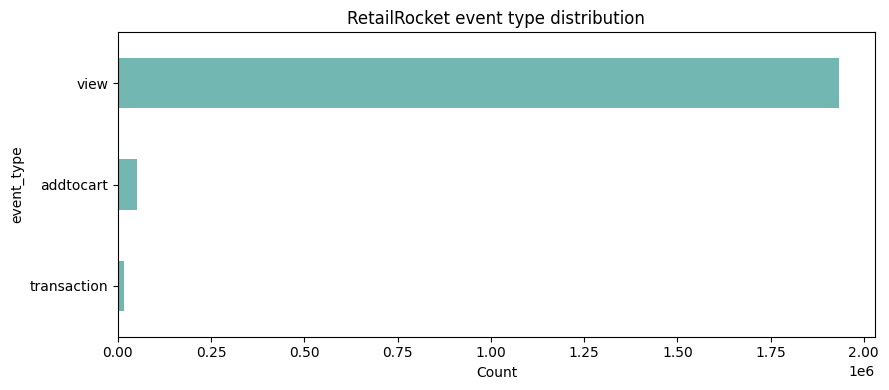

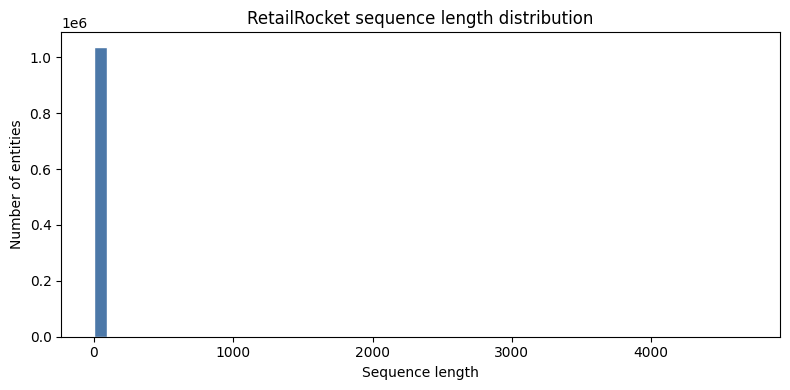

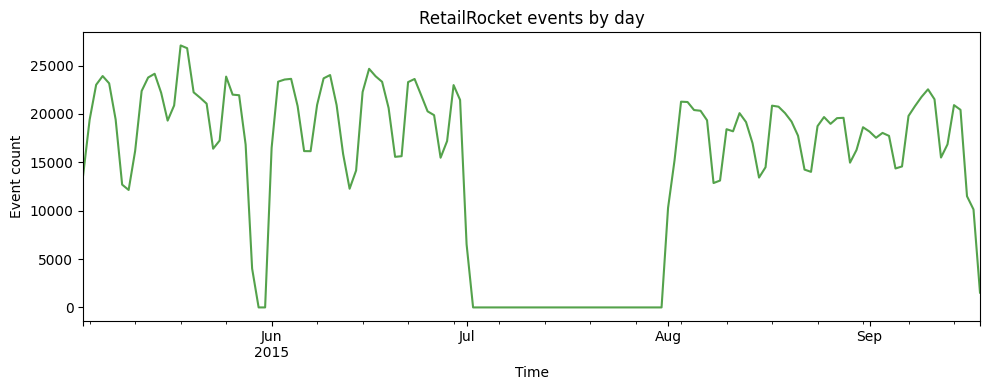

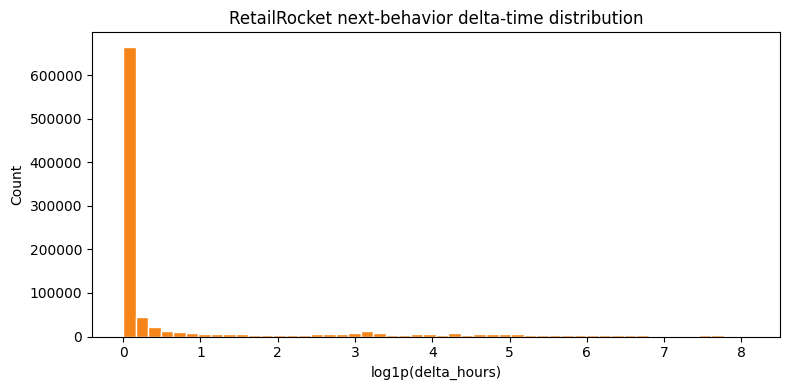

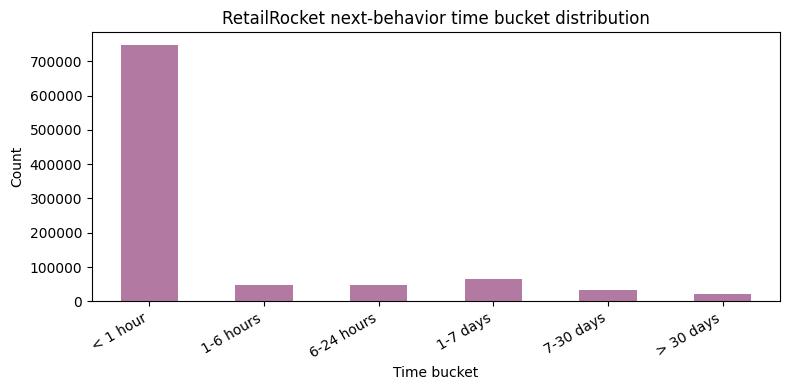

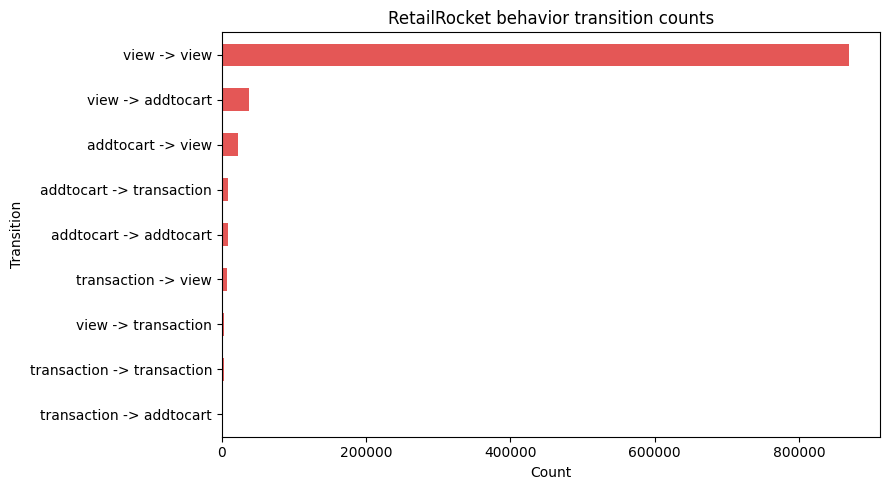

In [44]:
if retailrocket is not None and not retailrocket.empty:
    plot_top_value_counts(retailrocket["event_type"], "RetailRocket event type distribution", top_n=20)
    plot_sequence_lengths(retailrocket_lengths, "RetailRocket sequence length distribution")
    plot_events_over_time(retailrocket, "datetime", "RetailRocket events by day", freq="D")
    if not retailrocket_next_behavior.empty:
        plot_delta_distribution(retailrocket_next_behavior["delta_hours"], "RetailRocket next-behavior delta-time distribution")
        plot_time_bucket_distribution(retailrocket_next_behavior, "RetailRocket next-behavior time bucket distribution")
        plot_transition_counts(retailrocket_next_behavior, "RetailRocket behavior transition counts", top_n=20)

### Nhận xét về các phân phối của RetailRocket

Các biểu đồ trên cho thấy RetailRocket có cấu trúc rất phù hợp với purchase-aware recommendation, nhưng cũng có các đặc điểm cần xử lý cẩn thận khi chuyển sang modeling.

Biểu đồ `event_type distribution` cho thấy dữ liệu bị mất cân bằng rất mạnh theo loại hành vi. Phần lớn event là `view`, trong khi `addtocart` và đặc biệt là `transaction` ít hơn rất nhiều. Điều này phản ánh đúng e-commerce funnel: user thường xem rất nhiều sản phẩm, chỉ một phần nhỏ thêm vào giỏ, và chỉ một phần nhỏ hơn nữa tạo giao dịch mua hàng. Vì vậy, nếu xây dựng bài toán `will_buy` hoặc `next_transaction`, cần xem đây là bài toán class imbalance thay vì classification cân bằng.

Biểu đồ `sequence length distribution` cho thấy phần lớn visitor chỉ có rất ít event trong sample, đa số nằm ở sequence length thấp. Điều này khớp với bảng sequence feasibility trước đó, trong đó median sequence length chỉ bằng 1.0. Như vậy, RetailRocket không phải dataset lý tưởng cho long-term user history modeling, nhưng lại phù hợp với short-session hoặc short-history behavior prediction, ví dụ dự đoán hành vi kế tiếp từ vài event gần nhất.

Biểu đồ `next-behavior delta-time distribution` cho thấy phần lớn event kế tiếp xảy ra rất nhanh, với nhiều giá trị tập trung gần 0 trên thang `log1p(delta_hours)`. Điều này cho thấy nhiều hành vi thuộc cùng một phiên truy cập website. Tuy nhiên, phân phối vẫn có đuôi dài, nghĩa là một số visitor quay lại sau nhiều giờ hoặc nhiều ngày. Do đó, RetailRocket có thể hỗ trợ cả within-session behavior modeling và return behavior modeling, nhưng hai setting này nên được tách rõ nếu đi vào modeling.

Biểu đồ `next-behavior time bucket distribution` cho thấy bucket `< 1 hour` chiếm ưu thế, nhưng các bucket dài hơn như `1-6 hours`, `6-24 hours`, `1-7 days`, `7-30 days` và `> 30 days` vẫn có số lượng đáng kể. Điều này khác với Last.fm, nơi phần lớn event gần như hoàn toàn nằm trong listening session ngắn. Với RetailRocket, khoảng cách thời gian có ý nghĩa hơn cho các bài toán như `time_to_next_behavior` hoặc `time_to_transaction`, đặc biệt khi tách within-session và cross-session behavior.

Biểu đồ `behavior transition counts` cho thấy transition phổ biến nhất là `view -> view`, vượt xa các transition còn lại. Điều này hợp lý vì user thường xem nhiều sản phẩm liên tiếp. Các transition như `view -> addtocart`, `addtocart -> transaction` và `view -> transaction` tuy ít hơn nhưng rất quan trọng, vì chúng biểu diễn các bước chuyển đổi trong purchase funnel. Đặc biệt, `addtocart -> transaction` là tín hiệu mạnh cho purchase intent, còn `view -> transaction` cho thấy một số giao dịch có thể xảy ra ngay sau khi xem sản phẩm mà không có event add-to-cart được ghi nhận.

Tóm lại, RetailRocket là candidate mạnh cho purchase-aware recommendation vì có event type rõ ràng, timestamp hành vi thật và transaction signal. Tuy nhiên, dataset bị mất cân bằng mạnh: `view` áp đảo, `transaction` sparse và nhiều visitor có sequence ngắn. Vì vậy, các task phù hợp nhất là `next_behavior prediction`, `view/addtocart -> transaction prediction`, `will_buy`, `next_transaction_item` và `time_to_transaction`, với điều kiện phải xử lý class imbalance, sessionization và temporal leakage cẩn thận.

## 14. Taobao UserBehavior Exploration

Taobao UserBehavior là e-commerce multi-behavior dataset với các hành vi như `pv`, `cart`, `fav` và `buy`. Dataset này rất phù hợp với hướng purchase-aware recommendation vì có cả hành vi xem, thêm giỏ, yêu thích và mua hàng. Do dataset có thể lớn, phần exploration đọc sample có kiểm soát để tránh quá tải bộ nhớ.

### 14.1 Taobao Load

File thường không có header và gồm `user_id,item_id,category_id,behavior_type,timestamp`. Cell này đọc sample có kiểm soát bằng `TAOBAO_SAMPLE_NROWS`; muốn full exploration có thể tăng biến này, đặt thành `None`, hoặc đọc chunk.


In [45]:
taobao = None
TAOBAO_SAMPLE_NROWS = globals().get("TAOBAO_SAMPLE_NROWS", 2_000_000)
taobao_sequence_summary = pd.DataFrame()
taobao_lengths = pd.Series(dtype="int64")
taobao_next_behavior = pd.DataFrame()
taobao_time_summary = pd.DataFrame()
taobao_temporal_report = {}
taobao_transition_counts = pd.DataFrame()
taobao_to_buy_transitions = pd.DataFrame()

if PATHS["taobao_user_behavior"].exists():
    taobao = pd.read_csv(
        PATHS["taobao_user_behavior"],
        names=["user_id", "item_id", "category_id", "behavior_type", "timestamp"],
        nrows=TAOBAO_SAMPLE_NROWS,
    )
    taobao["datetime"] = pd.to_datetime(taobao["timestamp"], unit="s", errors="coerce")
    display(taobao.head(10))
    display(summarize_dataframe(taobao))
else:
    print(f"[WARN] Missing Taobao UserBehavior file: {PATHS['taobao_user_behavior']}")

,user_id,item_id,category_id,behavior_type,timestamp,datetime
0,1,2268318,2520377,pv,1511544070,2017-11-24 17:21:10
1,1,2333346,2520771,pv,1511561733,2017-11-24 22:15:33
2,1,2576651,149192,pv,1511572885,2017-11-25 01:21:25
3,1,3830808,4181361,pv,1511593493,2017-11-25 07:04:53
4,1,4365585,2520377,pv,1511596146,2017-11-25 07:49:06
5,1,4606018,2735466,pv,1511616481,2017-11-25 13:28:01
6,1,230380,411153,pv,1511644942,2017-11-25 21:22:22
7,1,3827899,2920476,pv,1511713473,2017-11-26 16:24:33
8,1,3745169,2891509,pv,1511725471,2017-11-26 19:44:31
9,1,1531036,2920476,pv,1511733732,2017-11-26 22:02:12


,column,dtype,missing,missing_pct,n_unique,example_value
0,user_id,int64,0,0.0,19544,1
1,item_id,int64,0,0.0,629096,2268318
2,category_id,int64,0,0.0,6494,2520377
3,behavior_type,object,0,0.0,4,pv
4,timestamp,int64,0,0.0,627028,1511544070
5,datetime,datetime64[ns],0,0.0,627028,2017-11-24 17:21:10


### 14.2 Taobao Schema and Behavior Summary

`pv` = page view, `cart` = add to cart, `fav` = favorite, và `buy` = purchase. Taobao phù hợp với multi-behavior purchase prediction.

In [46]:
if taobao is not None and not taobao.empty:
    display(summarize_dataframe(taobao))
    taobao_behavior_counts = taobao["behavior_type"].value_counts().reset_index()
    taobao_behavior_counts.columns = ["behavior_type", "count"]
    display(taobao_behavior_counts)
    taobao_basic_summary = pd.DataFrame([{
        "n_events_sample": len(taobao),
        "sample_nrows_limit": TAOBAO_SAMPLE_NROWS,
        "n_users": taobao["user_id"].nunique(),
        "n_items": taobao["item_id"].nunique(),
        "n_categories": taobao["category_id"].nunique(),
        "n_behavior_types": taobao["behavior_type"].nunique(),
        "n_pv_events": int((taobao["behavior_type"] == "pv").sum()),
        "n_cart_events": int((taobao["behavior_type"] == "cart").sum()),
        "n_fav_events": int((taobao["behavior_type"] == "fav").sum()),
        "n_buy_events": int((taobao["behavior_type"] == "buy").sum()),
        "buy_event_rate_pct": round(float((taobao["behavior_type"] == "buy").mean() * 100), 4),
        "n_buy_users": taobao.loc[taobao["behavior_type"] == "buy", "user_id"].nunique(),
    }])
    display(taobao_basic_summary)

,column,dtype,missing,missing_pct,n_unique,example_value
0,user_id,int64,0,0.0,19544,1
1,item_id,int64,0,0.0,629096,2268318
2,category_id,int64,0,0.0,6494,2520377
3,behavior_type,object,0,0.0,4,pv
4,timestamp,int64,0,0.0,627028,1511544070
5,datetime,datetime64[ns],0,0.0,627028,2017-11-24 17:21:10


,behavior_type,count
0,pv,1791216
1,cart,111015
2,fav,57526
3,buy,40243


,n_events_sample,sample_nrows_limit,n_users,n_items,n_categories,n_behavior_types,n_pv_events,n_cart_events,n_fav_events,n_buy_events,buy_event_rate_pct,n_buy_users
0,2000000,2000000,19544,629096,6494,4,1791216,111015,57526,40243,2.0122,13330


### Nhận xét về Taobao Load và Schema

Taobao UserBehavior được load thành công với sample 2,000,000 events. Dataset có schema rất phù hợp cho purchase-aware recommendation, gồm các cột chính: `user_id`, `item_id`, `category_id`, `behavior_type`, `timestamp` và `datetime`. Không có cột nào bị missing trong sample hiện tại, nên dữ liệu khá sạch ở mức schema.

Cột `behavior_type` có 4 loại hành vi: `pv`, `cart`, `fav` và `buy`. Trong đó, `pv` là page view, `cart` là add-to-cart, `fav` là favorite, và `buy` là purchase. Đây là điểm mạnh lớn của Taobao so với các dataset chỉ có rating hoặc review, vì nó mô tả đầy đủ hơn hành trình hành vi của user trước khi mua hàng.

Trong sample hiện tại, phần lớn event là `pv` với 1,791,216 events. Các hành vi mạnh hơn xuất hiện ít hơn: `cart` có 111,015 events, `fav` có 57,526 events, và `buy` có 40,243 events. Tỷ lệ buy event khoảng 2.0122%, cao hơn RetailRocket trong sample trước đó. Điều này cho thấy Taobao có purchase signal rõ hơn và có thể phù hợp hơn cho các bài toán như `will_buy`, `next_buy_item`, hoặc `time_to_buy`.

Dataset cũng có độ phủ entity khá tốt: sample 2,000,000 dòng chứa 19,544 users, 629,096 items và 6,494 categories. So với RetailRocket, Taobao có ít user hơn trong sample nhưng mỗi user có xu hướng có nhiều event hơn. Điều này có lợi cho sequence modeling vì có thể tạo lịch sử hành vi dài hơn theo từng user.

Cột `category_id` là một lợi thế quan trọng. Nó cho phép xây dựng feature ở mức category, ví dụ user thường xem hoặc mua category nào, category nào có tỷ lệ chuyển đổi cao, hoặc item/category nào thường xuất hiện trước hành vi `buy`. Vì vậy, Taobao không chỉ phù hợp với next-item prediction mà còn phù hợp với category-aware và behavior-aware recommendation.

Tóm lại, Taobao là candidate rất mạnh cho multi-behavior purchase prediction. Dataset này phù hợp với các bài toán `next_behavior prediction`, `next_item prediction`, `will_buy prediction`, `next_buy_item`, và `time_to_buy`. So với RetailRocket, Taobao có thêm hành vi `fav` và tỷ lệ buy cao hơn trong sample, nên có thể giàu tín hiệu hơn cho purchase-aware modeling. Hạn chế chính là dataset có thể rất lớn, nên cần sampling/chunking hợp lý và phải ghi rõ chiến lược sample khi đưa vào báo cáo.

### 14.3 Taobao Timestamp Analysis

Timestamp là Unix seconds. Cần sort theo user/time; nếu đọc sample đầu file, temporal distribution có thể không đại diện toàn dataset.

In [47]:
if taobao is not None and not taobao.empty:
    _, taobao_time_summary = analyze_timestamp(taobao, "datetime")
    display(taobao_time_summary)

,timestamp_col,unit,n_rows,missing_raw,invalid_or_missing_parsed,valid_rate,min_datetime,max_datetime,time_span_days,is_monotonic_in_file_order
0,datetime,datetime/string,2000000,0,0,1.0,1970-01-01 12:13:36,2018-08-28 10:27:12,17770.926,False


### 14.4 Taobao Sequence Feasibility

Đo repeated behavior theo user trong sample để đánh giá khả năng tạo next-item, next-behavior và delta-time targets.

In [48]:
if taobao is not None and not taobao.empty:
    taobao_events_for_sequence = taobao.dropna(subset=["user_id", "item_id", "datetime"]).copy()
    taobao_sequence_summary, taobao_lengths = analyze_sequence_feasibility(
        taobao_events_for_sequence, "Taobao UserBehavior sample", "user_id", "item_id", "datetime", recommendation_like=True
    )
    display(taobao_sequence_summary)
    display(threshold_coverage_table(taobao_lengths))

,dataset,entity_col,item_col,time_col,n_rows,n_entities,n_items,median_sequence_length,entities_with_2plus_events_pct,entities_with_5plus_events_pct,can_create_next_item,can_create_next_time,main_limitation
0,Taobao UserBehavior sample,user_id,item_id,datetime,2000000,19544,629096,76.0,99.995,99.872,Yes,Yes,Usable for next-event targets; still requires ...


,threshold,entities_count,entities_pct
0,2,19543,99.995
1,3,19539,99.974
2,5,19519,99.872
3,10,19183,98.153


### 14.5 Taobao Next-Behavior Target Construction

Target có thể là next item, next behavior type, delta-time và time bucket. Đặc biệt quan tâm các transition đi đến `buy`.

In [49]:
if taobao is not None and not taobao.empty:
    taobao_next_behavior = create_next_behavior_targets(
        taobao.dropna(subset=["user_id", "item_id", "datetime", "behavior_type"]),
        entity_col="user_id", item_col="item_id", time_col="datetime", event_col="behavior_type",
    )
    taobao_next_behavior = add_time_bucket(taobao_next_behavior)
    display(target_quality_summary(taobao_next_behavior))
    if not taobao_next_behavior.empty:
        display(taobao_next_behavior[[
            "user_id", "history_length", "behavior_type", "item_id", "datetime",
            "next_event_type", "next_item_or_event", "next_time", "delta_hours", "time_bucket",
        ]].head(10))

,target_rows,median_delta_hours,p90_delta_hours,max_delta_days,n_time_buckets
0,1980456,0.0206,3.239,17494.6834,6


,user_id,history_length,behavior_type,item_id,datetime,next_event_type,next_item_or_event,next_time,delta_hours,time_bucket
0,1,1,pv,2268318,2017-11-24 17:21:10,pv,2333346.0,2017-11-24 22:15:33,4.906389,1-6 hours
1,1,2,pv,2333346,2017-11-24 22:15:33,pv,2576651.0,2017-11-25 01:21:25,3.097778,1-6 hours
2,1,3,pv,2576651,2017-11-25 01:21:25,pv,3830808.0,2017-11-25 07:04:53,5.724444,1-6 hours
3,1,4,pv,3830808,2017-11-25 07:04:53,pv,4365585.0,2017-11-25 07:49:06,0.736944,< 1 hour
4,1,5,pv,4365585,2017-11-25 07:49:06,pv,4606018.0,2017-11-25 13:28:01,5.648611,1-6 hours
5,1,6,pv,4606018,2017-11-25 13:28:01,pv,230380.0,2017-11-25 21:22:22,7.905833,6-24 hours
6,1,7,pv,230380,2017-11-25 21:22:22,pv,3827899.0,2017-11-26 16:24:33,19.036389,6-24 hours
7,1,8,pv,3827899,2017-11-26 16:24:33,pv,3745169.0,2017-11-26 19:44:31,3.332778,1-6 hours
8,1,9,pv,3745169,2017-11-26 19:44:31,pv,1531036.0,2017-11-26 22:02:12,2.294722,1-6 hours
9,1,10,pv,1531036,2017-11-26 22:02:12,pv,2266567.0,2017-11-27 00:11:11,2.149722,1-6 hours


### 14.6 Taobao Buy Feasibility

Nếu `buy` sparse, classification sẽ imbalance. Tuy nhiên có `pv/cart/fav/buy`, nên dataset rất hợp cho purchase-aware modeling như `will_buy`, `next_buy_item`, hoặc `time_to_buy`.

In [50]:
if taobao is not None and not taobao.empty:
    taobao_buy_events = taobao[taobao["behavior_type"] == "buy"].copy()
    n_users = taobao["user_id"].nunique()
    n_items = taobao["item_id"].nunique()
    taobao_buy_feasibility = pd.DataFrame([{
        "n_users": n_users,
        "n_buy_users": taobao_buy_events["user_id"].nunique(),
        "buy_user_pct": round(float(taobao_buy_events["user_id"].nunique() / n_users * 100), 3) if n_users else np.nan,
        "n_items": n_items,
        "n_bought_items": taobao_buy_events["item_id"].nunique(),
        "bought_item_pct": round(float(taobao_buy_events["item_id"].nunique() / n_items * 100), 3) if n_items else np.nan,
        "n_buy_events": len(taobao_buy_events),
        "buy_event_rate_pct": round(float((taobao["behavior_type"] == "buy").mean() * 100), 4),
    }])
    display(taobao_buy_feasibility)
    if not taobao_next_behavior.empty:
        taobao_transition_counts = (taobao_next_behavior.groupby(["behavior_type", "next_event_type"], observed=True).size().reset_index(name="count").sort_values("count", ascending=False))
        display(taobao_transition_counts.head(20))
        taobao_to_buy_transitions = taobao_transition_counts[taobao_transition_counts["next_event_type"] == "buy"].copy()
        display(taobao_to_buy_transitions.head(20))

,n_users,n_buy_users,buy_user_pct,n_items,n_bought_items,bought_item_pct,n_buy_events,buy_event_rate_pct
0,19544,13330,68.205,629096,32485,5.164,40243,2.0122


,behavior_type,next_event_type,count
15,pv,pv,1614438
7,cart,pv,86955
13,pv,cart,86744
11,fav,pv,43971
14,pv,fav,43666
12,pv,buy,29905
3,buy,pv,28768
5,cart,cart,19449
10,fav,fav,10928
0,buy,buy,7328


,behavior_type,next_event_type,count
12,pv,buy,29905
0,buy,buy,7328
4,cart,buy,1698
8,fav,buy,620


### Nhận xét về Taobao Schema, Sequence, Next-Behavior và Buy Feasibility

Taobao UserBehavior là một trong các dataset phù hợp nhất cho hướng purchase-aware recommendation trong notebook này. Dataset có schema rõ ràng gồm `user_id`, `item_id`, `category_id`, `behavior_type`, `timestamp` và `datetime`. Mỗi dòng biểu diễn một hành vi thật của user trên nền tảng e-commerce tại một thời điểm cụ thể. Không có missing value trong các cột chính của sample hiện tại, nên dữ liệu khá sạch ở mức schema.

Cột `behavior_type` có bốn loại hành vi: `pv`, `cart`, `fav` và `buy`. Trong đó, `pv` là page view, `cart` là add-to-cart, `fav` là favorite, và `buy` là purchase. Đây là điểm mạnh lớn của Taobao so với MovieLens, Amazon review hoặc MIND. Taobao không chỉ ghi nhận item được tương tác, mà còn mô tả mức độ mạnh yếu của hành vi trong purchase funnel. Vì vậy, dataset này phù hợp với các bài toán như `next_behavior prediction`, `will_buy prediction`, `next_buy_item`, và `time_to_buy`.

Trong sample 2,000,000 events, phần lớn event là `pv` với 1,791,216 events. Các hành vi mạnh hơn ít hơn: `cart` có 111,015 events, `fav` có 57,526 events và `buy` có 40,243 events. Tỷ lệ buy event khoảng 2.0122%, cao hơn RetailRocket trong sample trước đó. Điều này cho thấy buy signal trong Taobao rõ hơn và giàu hơn cho purchase-aware modeling, dù vẫn có sự mất cân bằng giữa `pv` và `buy`.

Dataset cũng có độ phủ tốt về entity và item. Sample hiện tại có 19,544 users, 629,096 items và 6,494 categories. So với RetailRocket, Taobao có ít users hơn trong sample nhưng mỗi user có nhiều event hơn. Điều này đặc biệt quan trọng cho sequence modeling vì model có thể học được lịch sử hành vi dài hơn của từng user. Cột `category_id` cũng là lợi thế lớn vì có thể dùng để xây dựng category-aware features, ví dụ user thường xem/mua category nào hoặc category nào có tỷ lệ chuyển đổi cao.

Phần timestamp analysis cho thấy `datetime` parse thành công với `valid_rate = 1.0`. Tuy nhiên, kết quả cũng xuất hiện `min_datetime = 1970-01-01`, trong khi phần lớn dữ liệu Taobao thường nằm quanh năm 2017. Đây là dấu hiệu có thể tồn tại timestamp outlier hoặc giá trị timestamp bất thường trong sample. Vì vậy, trước khi modeling nghiêm túc, cần thêm bước lọc hoặc diagnostic timestamp, ví dụ kiểm tra phân vị thời gian, loại bỏ timestamp quá xa khoảng thời gian chính, hoặc giới hạn theo khoảng ngày hợp lệ. Nếu không xử lý, các outlier này có thể làm méo `delta_time`, `time_bucket` và temporal split.

Phần sequence feasibility cho thấy Taobao rất mạnh cho sequence-based recommendation. Sample có 2,000,000 events, 19,544 users và median sequence length đạt 76.0. Gần như toàn bộ user có lịch sử đủ dài: 99.995% user có ít nhất 2 events, 99.872% user có ít nhất 5 events và 98.153% user có ít nhất 10 events. Đây là kết quả tốt hơn RetailRocket và Amazon sample rất nhiều. Điều này cho thấy Taobao có thể tạo dữ liệu dạng `current behavior -> next behavior` hoặc `history -> next behavior` một cách ổn định.

Phần next-behavior target construction tạo được 1,980,456 mẫu target. Con số này gần bằng tổng số events trừ đi số user, vì mỗi user có `n` events sẽ tạo được `n - 1` mẫu next-event. Target không chỉ gồm item kế tiếp mà còn gồm `next_event_type`, `delta_hours` và `time_bucket`. Điều này cho phép xây dựng nhiều bài toán khác nhau: dự đoán item kế tiếp, dự đoán hành vi kế tiếp, dự đoán khoảng cách thời gian đến event kế tiếp, hoặc dự đoán bucket thời gian.

Kết quả temporal target cho thấy `median_delta_hours = 0.0206`, tương đương khoảng 1.24 phút, và `p90_delta_hours = 3.239`, tương đương khoảng 3.24 giờ. Điều này cho thấy nhiều hành vi xảy ra gần nhau trong cùng một session, nhưng vẫn có một phần đáng kể event cách nhau nhiều giờ. Tuy nhiên, `max_delta_days = 17494.6834` là bất thường và nhiều khả năng liên quan đến timestamp outlier đã thấy ở phần timestamp analysis. Vì vậy, trước khi dùng `delta_time` hoặc `time_bucket` làm target modeling, cần lọc timestamp outlier để tránh làm sai lệch phân phối thời gian.

Phần buy feasibility cho thấy buy signal của Taobao khá mạnh. Trong 19,544 users, có 13,330 users từng có hành vi `buy`, tương đương 68.205% users. Trong 629,096 items, có 32,485 items từng được mua, tương đương 5.164% items. Tổng số buy events là 40,243, chiếm 2.0122% toàn bộ events. So với RetailRocket, tỷ lệ user có buy trong Taobao cao hơn rất nhiều, cho thấy Taobao phù hợp hơn cho các bài toán purchase-aware ở mức user sequence.

Transition analysis cũng cho thấy các chuyển tiếp hành vi có ý nghĩa rõ. Transition phổ biến nhất là `pv -> pv` với 1,614,438 lần, phản ánh việc user xem nhiều item liên tiếp. Các transition như `pv -> cart`, `pv -> fav`, `cart -> pv`, `fav -> pv` cho thấy user thường chuyển qua lại giữa xem, thêm giỏ và yêu thích. Đặc biệt, các transition đi tới `buy` rất quan trọng: `pv -> buy` có 29,905 lần, `cart -> buy` có 1,698 lần và `fav -> buy` có 620 lần. Điều này cho thấy hành vi mua có thể xảy ra trực tiếp sau page view, hoặc sau các tín hiệu ý định mạnh hơn như cart/favorite.

Một điểm đáng chú ý là `buy -> buy` cũng xuất hiện 7,328 lần. Điều này có thể phản ánh việc user mua nhiều item gần nhau trong cùng một phiên hoặc có nhiều purchase events liên tiếp. Khi modeling, cần xác định rõ mục tiêu: nếu muốn dự đoán first purchase trong session, cần tách session và chỉ dùng lịch sử trước purchase đầu tiên; nếu muốn dự đoán next behavior nói chung, có thể giữ toàn bộ transition.

Tóm lại, Taobao là candidate rất mạnh cho multi-behavior purchase-aware recommendation. So với RetailRocket, Taobao có sequence dài hơn, buy-user coverage cao hơn và thêm hành vi `fav`, giúp mô hình học được nhiều mức độ ý định mua hàng hơn. Hạn chế chính là dataset lớn, cần sampling/chunking hợp lý, và sample hiện tại có dấu hiệu timestamp outlier. Trước khi modeling, nên lọc timestamp bất thường, dùng temporal split hoặc leave-last-out theo user, và tính các feature tổng hợp như item popularity, category popularity hoặc buy rate chỉ trên train set để tránh leakage.

### 14.7 Taobao Plots

Các plot kiểm tra behavior mix, sequence length, next-behavior delta-time, time bucket, event volume theo ngày, top transitions và transitions to buy.

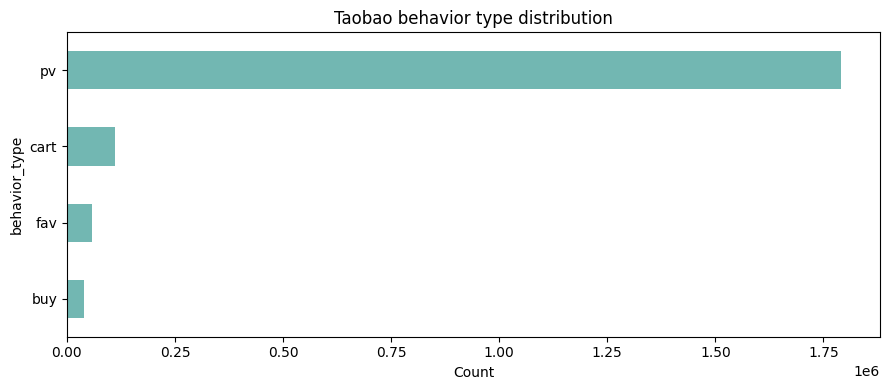

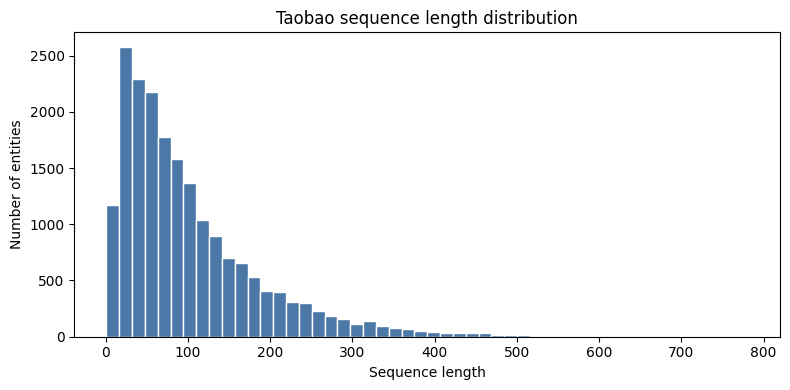

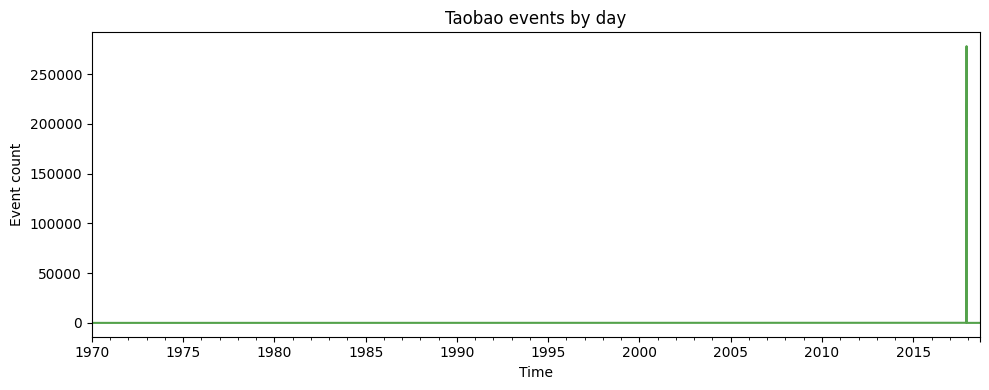

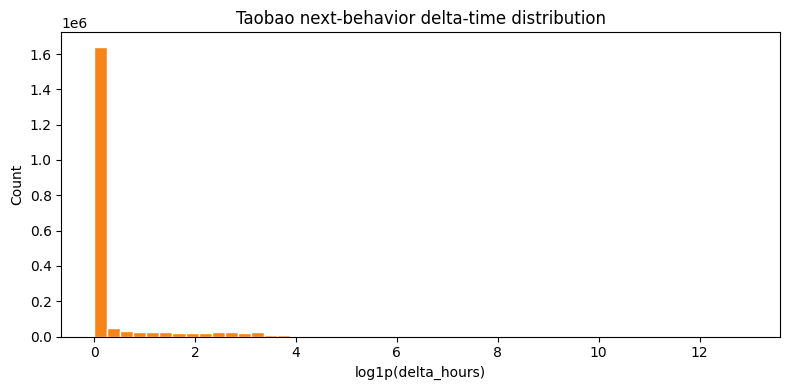

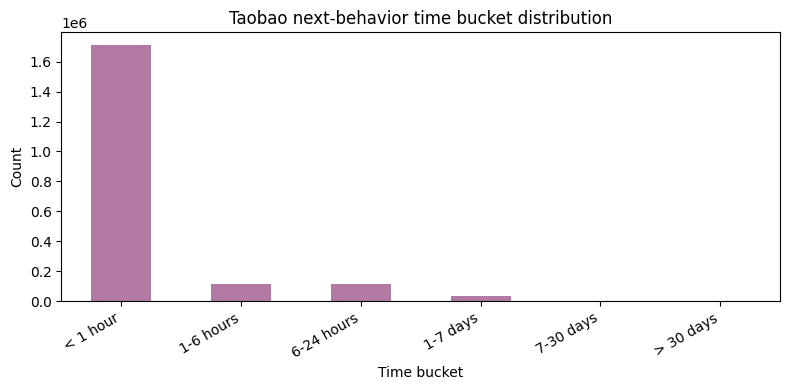

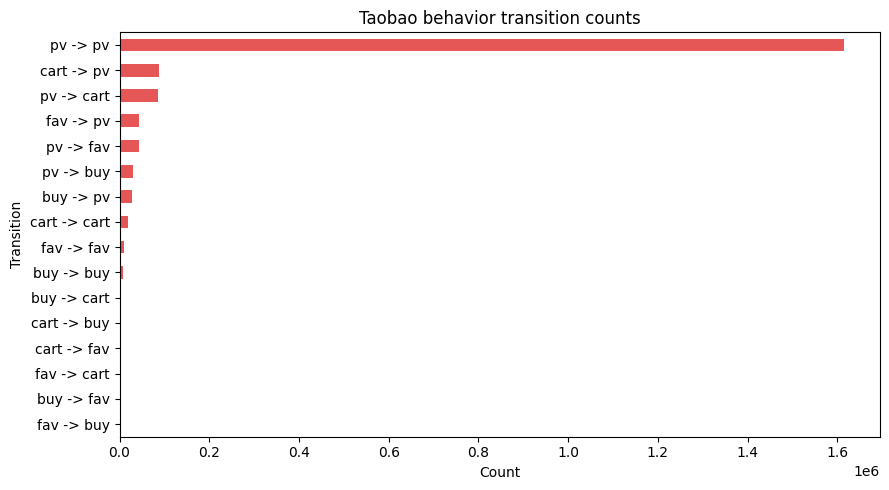

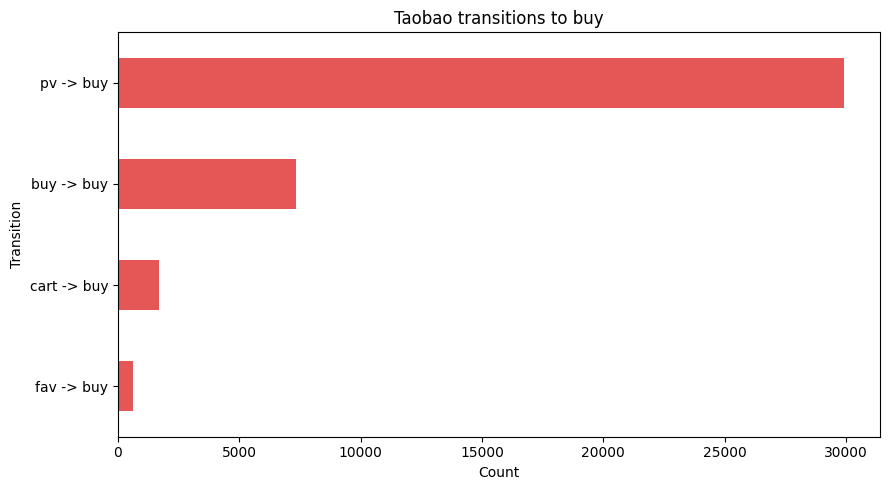

In [51]:
if taobao is not None and not taobao.empty:
    plot_top_value_counts(taobao["behavior_type"], "Taobao behavior type distribution", top_n=20)
    plot_sequence_lengths(taobao_lengths, "Taobao sequence length distribution")
    plot_events_over_time(taobao, "datetime", "Taobao events by day", freq="D")
    if not taobao_next_behavior.empty:
        plot_delta_distribution(taobao_next_behavior["delta_hours"], "Taobao next-behavior delta-time distribution")
        plot_time_bucket_distribution(taobao_next_behavior, "Taobao next-behavior time bucket distribution")
        plot_transition_counts(taobao_next_behavior, "Taobao behavior transition counts", top_n=20)
        plot_transition_counts(taobao_next_behavior[taobao_next_behavior["next_event_type"] == "buy"], "Taobao transitions to buy", top_n=20)

### Nhận xét về các phân phối của Taobao

Các biểu đồ trên cho thấy Taobao là dataset rất mạnh cho multi-behavior purchase-aware recommendation. Dataset có đầy đủ các hành vi `pv`, `cart`, `fav` và `buy`, trong đó `pv` là page view, `cart` là add-to-cart, `fav` là favorite, và `buy` là purchase.

Biểu đồ `behavior type distribution` cho thấy dữ liệu bị mất cân bằng theo hành vi. Phần lớn event là `pv`, trong khi `cart`, `fav` và `buy` ít hơn nhiều. Điều này phản ánh đúng purchase funnel trong e-commerce: user thường xem rất nhiều item, chỉ một phần nhỏ thêm vào giỏ, yêu thích hoặc mua hàng. Tuy nhiên, so với RetailRocket, Taobao có buy signal rõ hơn trong sample hiện tại, với tỷ lệ buy event khoảng 2.0122%.

Biểu đồ `sequence length distribution` cho thấy Taobao có sequence theo user tốt hơn RetailRocket. Phần lớn user có nhiều event, và median sequence length đạt 76.0. Đây là điểm rất mạnh cho sequence modeling, vì model có thể dùng lịch sử hành vi của user thay vì chỉ dựa trên một vài event ngắn. Điều này làm Taobao phù hợp với các bài toán `history -> next behavior`, `history -> next item`, hoặc `history -> next buy`.

Biểu đồ `next-behavior delta-time distribution` và `next-behavior time bucket distribution` cho thấy phần lớn event kế tiếp xảy ra trong khoảng thời gian ngắn, đặc biệt là bucket `< 1 hour`. Điều này cho thấy nhiều hành vi thuộc cùng một session hoặc cùng một chuỗi duyệt sản phẩm ngắn hạn. Tuy nhiên, vẫn có một phần event nằm ở các bucket dài hơn như `1-6 hours`, `6-24 hours` và `1-7 days`, nên Taobao cũng có thể hỗ trợ các bài toán dự đoán khoảng cách thời gian ở mức thô như `time_bucket`.

Biểu đồ `behavior transition counts` cho thấy transition phổ biến nhất là `pv -> pv`, vượt xa các transition khác. Điều này hợp lý vì user thường xem nhiều item liên tiếp trước khi có hành vi mạnh hơn. Các transition như `pv -> cart`, `pv -> fav`, `cart -> pv` và `fav -> pv` cho thấy user có thể chuyển qua lại giữa xem, thêm giỏ và yêu thích trước khi mua.

Biểu đồ `transitions to buy` đặc biệt quan trọng cho purchase-aware modeling. Transition lớn nhất đi tới buy là `pv -> buy`, với khoảng 29,905 lần. Điều này cho thấy nhiều purchase xảy ra ngay sau page view trong chuỗi event được ghi nhận. Ngoài ra còn có `cart -> buy` và `fav -> buy`, tuy ít hơn nhưng có ý nghĩa mạnh vì chúng phản ánh các hành vi có purchase intent rõ ràng. Transition `buy -> buy` cũng xuất hiện đáng kể, có thể do user mua nhiều item gần nhau trong cùng một phiên hoặc nhiều purchase events được ghi nhận liên tiếp.

Tuy nhiên, biểu đồ `events by day` cho thấy một vấn đề dữ liệu quan trọng: có event xuất hiện ở mốc năm 1970, trong khi phần lớn dữ liệu tập trung quanh năm 2017. Điều này cho thấy tồn tại timestamp outlier hoặc giá trị timestamp bất thường. Outlier này cũng giải thích vì sao `max_delta_days` trong phần target construction rất lớn. Vì vậy, trước khi dùng Taobao cho modeling, cần lọc timestamp bất thường, ví dụ chỉ giữ khoảng thời gian chính quanh năm 2017 hoặc lọc theo phân vị `p01` đến `p99`.

Tóm lại, Taobao là candidate rất mạnh cho purchase-aware recommendation vì có sequence dài, nhiều user có repeated behavior, event type phong phú và buy signal rõ. Dataset này phù hợp với các bài toán `next_behavior prediction`, `next_item prediction`, `will_buy prediction`, `next_buy_item`, và `time_to_buy`. Tuy nhiên, cần xử lý timestamp outlier, class imbalance giữa `pv` và `buy`, và dùng temporal split hoặc leave-last-out để tránh leakage.

## 15. Cross-Dataset Feasibility Summary

Bảng này chuẩn hóa feasibility giữa MovieLens, Amazon, CASAS, Last.fm, MIND, RetailRocket và Taobao theo các tiêu chí phù hợp với next-event, next-item, next-time, time-aware recommendation và purchase-aware recommendation.


In [52]:
dataset_feasibility_summary = pd.DataFrame([
    {"dataset": "MovieLens", "entity": "user_id", "item_or_event": "item_id", "timestamp_quality": "Rating submission timestamp", "sequence_feasibility": "Yes", "next_item_feasibility": "Yes", "next_time_feasibility": "Limited", "purchase_feasibility": "No", "rs_benchmark": "Yes", "main_limitation": "Baseline truyền thống, không phù hợp main temporal task vì timestamp là rating submission time.", "recommended_role": "Traditional RS baseline."},
    {"dataset": "Amazon Appliances sample", "entity": "user_id", "item_or_event": "item_id / asin", "timestamp_quality": "Review timestamp", "sequence_feasibility": "Limited", "next_item_feasibility": "Limited by sparsity", "next_time_feasibility": "Limited", "purchase_feasibility": "No direct buy event", "rs_benchmark": "Yes", "main_limitation": "Review timestamp, schema tốt nhưng sparse.", "recommended_role": "Pipeline/schema validation unless filtered repeated users are sufficient."},
    {"dataset": "CASAS", "entity": "source_home", "item_or_event": "sensor_id", "timestamp_quality": "Real sensor event timestamp", "sequence_feasibility": "Yes", "next_item_feasibility": "Yes for sensor event", "next_time_feasibility": "Yes", "purchase_feasibility": "No", "rs_benchmark": "No", "main_limitation": "Event-time mạnh, nhưng không phải RS benchmark.", "recommended_role": "Auxiliary event-time prediction dataset."},
    {"dataset": "Last.fm 1K", "entity": "user_id", "item_or_event": "track_id / artist_id", "timestamp_quality": "Real listening timestamp", "sequence_feasibility": "Yes", "next_item_feasibility": "Yes", "next_time_feasibility": "Yes/Limited by session bursts", "purchase_feasibility": "No", "rs_benchmark": "Yes", "main_limitation": "Rất tốt cho real listening next-event/time; may contain dense within-session listening events.", "recommended_role": "Main candidate for temporal consumption recommendation."},
    {"dataset": "MIND", "entity": "user_id", "item_or_event": "news_id", "timestamp_quality": "Impression/click timestamp", "sequence_feasibility": "Limited/Depends on repeated clicks", "next_item_feasibility": "Yes for next-click, stronger for ranking", "next_time_feasibility": "Limited", "purchase_feasibility": "No", "rs_benchmark": "Yes", "main_limitation": "Tốt cho click/ranking/content-aware news recommendation; pure next-time is less natural.", "recommended_role": "Content/click recommendation candidate."},
    {"dataset": "RetailRocket", "entity": "visitorid / user_id", "item_or_event": "itemid / event_type", "timestamp_quality": "Real e-commerce behavior timestamp", "sequence_feasibility": "Yes/Limited depending repeated visitors", "next_item_feasibility": "Yes", "next_time_feasibility": "Yes", "purchase_feasibility": "Yes", "rs_benchmark": "Yes", "main_limitation": "No explicit session id in events.csv; transaction events may be sparse.", "recommended_role": "Main candidate for purchase-aware recommendation."},
    {"dataset": "Taobao UserBehavior", "entity": "user_id", "item_or_event": "item_id / behavior_type", "timestamp_quality": "Real e-commerce behavior timestamp", "sequence_feasibility": "Yes on sampled/filtered data", "next_item_feasibility": "Yes", "next_time_feasibility": "Yes", "purchase_feasibility": "Yes", "rs_benchmark": "Yes", "main_limitation": "Large dataset; requires sampling/chunking and careful temporal split.", "recommended_role": "Strong candidate for multi-behavior purchase prediction."},
])

display(dataset_feasibility_summary)


,dataset,entity,item_or_event,timestamp_quality,sequence_feasibility,next_item_feasibility,next_time_feasibility,purchase_feasibility,rs_benchmark,main_limitation,recommended_role
0,MovieLens,user_id,item_id,Rating submission timestamp,Yes,Yes,Limited,No,Yes,"Baseline truyền thống, không phù hợp main temp...",Traditional RS baseline.
1,Amazon Appliances sample,user_id,item_id / asin,Review timestamp,Limited,Limited by sparsity,Limited,No direct buy event,Yes,"Review timestamp, schema tốt nhưng sparse.",Pipeline/schema validation unless filtered rep...
2,CASAS,source_home,sensor_id,Real sensor event timestamp,Yes,Yes for sensor event,Yes,No,No,"Event-time mạnh, nhưng không phải RS benchmark.",Auxiliary event-time prediction dataset.
3,Last.fm 1K,user_id,track_id / artist_id,Real listening timestamp,Yes,Yes,Yes/Limited by session bursts,No,Yes,Rất tốt cho real listening next-event/time; ma...,Main candidate for temporal consumption recomm...
4,MIND,user_id,news_id,Impression/click timestamp,Limited/Depends on repeated clicks,"Yes for next-click, stronger for ranking",Limited,No,Yes,Tốt cho click/ranking/content-aware news recom...,Content/click recommendation candidate.
5,RetailRocket,visitorid / user_id,itemid / event_type,Real e-commerce behavior timestamp,Yes/Limited depending repeated visitors,Yes,Yes,Yes,Yes,No explicit session id in events.csv; transact...,Main candidate for purchase-aware recommendation.
6,Taobao UserBehavior,user_id,item_id / behavior_type,Real e-commerce behavior timestamp,Yes on sampled/filtered data,Yes,Yes,Yes,Yes,Large dataset; requires sampling/chunking and ...,Strong candidate for multi-behavior purchase p...


### Nhận xét tổng hợp về mức độ phù hợp của các dataset

Bảng tổng hợp cho thấy không có một dataset nào phù hợp cho tất cả các mục tiêu. Mỗi dataset phù hợp với một nhóm bài toán khác nhau.

MovieLens phù hợp với recommender system truyền thống như rating prediction, next-item prediction hoặc sequence recommendation baseline. Tuy nhiên, timestamp của MovieLens chủ yếu là thời điểm user nhập rating, không chắc là thời điểm user thật sự xem phim. Vì vậy, MovieLens không nên được dùng làm dataset chính cho bài toán next-time hoặc time-aware recommendation.

Amazon Appliances sample có schema gần với user-item recommendation và timestamp là thời điểm review. Tuy nhiên, sample hiện tại sparse theo user, nhiều user chỉ có ít interaction nên khả năng tạo sequence và next-event target bị hạn chế. Dataset này phù hợp hơn để kiểm tra schema/pipeline, trừ khi dùng bản lớn hơn hoặc lọc các user có nhiều interaction.

CASAS có timestamp rất tốt và sequence cực dài, nhưng không phải recommender-system benchmark truyền thống. Entity là `source_home`, item-like token là `sensor_id`, nên dataset này phù hợp với event-time prediction hoặc IoT sensor-event modeling hơn là user-item recommendation. CASAS nên được xem là auxiliary event-time dataset.

Last.fm 1K là candidate mạnh nhất cho temporal consumption recommendation. Timestamp gần với thời điểm nghe nhạc thực tế, sequence dài và có thể tạo nhiều target cho `next_artist`, `next_track`, `delta_time` hoặc `time_bucket`. Tuy nhiên, phần lớn event có thể nằm trong cùng listening session, nên cần tách rõ within-session next-item prediction và cross-session return-time prediction. Ngoài ra, nếu notebook chỉ đọc sample đầu file, cần chú ý sampling bias theo user.

MIND phù hợp nhất với click prediction, candidate ranking và content-aware news recommendation. Dataset này có `history`, `impressions`, click label và metadata nội dung như category, subcategory, title và abstract. Tuy nhiên, MIND không phải chuỗi tiêu thụ tự nhiên như Last.fm; timestamp gắn với impression/click session. Vì vậy, MIND không nên là dataset chính cho pure next-time prediction.

RetailRocket là candidate mạnh cho purchase-aware recommendation vì có event thật trên website gồm `view`, `addtocart` và `transaction`. Dataset này phù hợp với các bài toán như `next_behavior prediction`, `will_buy`, `next_transaction_item` và `time_to_transaction`. Hạn chế chính là transaction event khá sparse và nhiều visitor chỉ có sequence ngắn.

Taobao UserBehavior là candidate mạnh nhất cho multi-behavior purchase prediction. Dataset có `pv`, `cart`, `fav`, `buy`, category information và sequence theo user dài hơn RetailRocket trong sample hiện tại. Taobao phù hợp với `next_behavior`, `next_item`, `will_buy`, `next_buy_item` và `time_to_buy`. Tuy nhiên, dataset lớn nên cần sampling/chunking hợp lý, đồng thời cần xử lý timestamp outlier trước khi modeling.

Tóm lại, hướng dataset nên chia thành ba nhóm. Với temporal consumption recommendation, Last.fm là lựa chọn chính. Với purchase-aware recommendation, RetailRocket và Taobao là hai lựa chọn mạnh nhất, trong đó RetailRocket phù hợp để bắt đầu còn Taobao mạnh hơn cho multi-behavior modeling. Với content-aware click/ranking recommendation, MIND là lựa chọn phù hợp nhất. MovieLens chỉ nên giữ vai trò baseline truyền thống, Amazon dùng để kiểm tra pipeline/schema, và CASAS dùng như auxiliary event-time dataset.

### Optional Export of Summary Tables

Export chỉ lưu summary/sample nhỏ vào `data/processed/exploration/`. Notebook không export full dataframe lớn để tránh tạo artifact nặng không cần thiết.

In [53]:
if not dataset_feasibility_summary.empty:
    save_sample_csv(dataset_feasibility_summary, PROCESSED_DIR / "dataset_feasibility_summary.csv")
if not movielens_next_event_sample.empty:
    save_sample_csv(movielens_next_event_sample, PROCESSED_DIR / "movielens_next_event_sample.csv")
if not amazon_next_event_sample.empty:
    save_sample_csv(amazon_next_event_sample, PROCESSED_DIR / "amazon_next_event_sample.csv")
if not casas_next_event_sample.empty:
    save_sample_csv(casas_next_event_sample, PROCESSED_DIR / "casas_next_event_sample.csv")
if not lastfm_next_event_sample.empty:
    save_sample_csv(lastfm_next_event_sample, PROCESSED_DIR / "lastfm_next_event_sample.csv")
if not mind_next_event_sample.empty:
    save_sample_csv(mind_next_event_sample, PROCESSED_DIR / "mind_next_event_sample.csv")
if not retailrocket_next_behavior.empty:
    save_sample_csv(retailrocket_next_behavior, PROCESSED_DIR / "retailrocket_next_behavior_sample.csv", n=10)
if not taobao_next_behavior.empty:
    save_sample_csv(taobao_next_behavior, PROCESSED_DIR / "taobao_next_behavior_sample.csv", n=10)


Saved 7 rows -> Y:\Recommender-System-Dashboard\data\processed\exploration\dataset_feasibility_summary.csv
Saved 10 rows -> Y:\Recommender-System-Dashboard\data\processed\exploration\movielens_next_event_sample.csv
Saved 10 rows -> Y:\Recommender-System-Dashboard\data\processed\exploration\amazon_next_event_sample.csv
Saved 10 rows -> Y:\Recommender-System-Dashboard\data\processed\exploration\casas_next_event_sample.csv
Saved 10 rows -> Y:\Recommender-System-Dashboard\data\processed\exploration\lastfm_next_event_sample.csv
Saved 10 rows -> Y:\Recommender-System-Dashboard\data\processed\exploration\mind_next_event_sample.csv
Saved 10 rows -> Y:\Recommender-System-Dashboard\data\processed\exploration\retailrocket_next_behavior_sample.csv
Saved 10 rows -> Y:\Recommender-System-Dashboard\data\processed\exploration\taobao_next_behavior_sample.csv


## 16. Temporal Split and Leakage Notes

Với dữ liệu có timestamp, không nên dùng random split một cách trực tiếp. Random split có thể khiến model nhìn thấy thông tin từ tương lai trong train set, sau đó đánh giá trên các event xảy ra trước hoặc gần thời điểm đó trong validation/test. Điều này tạo temporal leakage và làm kết quả đánh giá cao hơn thực tế.

Đối với các bài toán next-event, next-item, next-time hoặc purchase-aware recommendation, nên ưu tiên một trong hai cách split. Cách thứ nhất là temporal split: dùng giai đoạn sớm để train, giai đoạn giữa để validation và giai đoạn muộn để test. Cách thứ hai là leave-last-out theo entity: với mỗi user/visitor/entity, dùng các event đầu làm train, event gần cuối làm validation và event cuối làm test. Cách thứ hai đặc biệt phù hợp với sequence recommendation vì mỗi entity vẫn có lịch sử trước khi dự đoán event kế tiếp.

Cần tránh leakage từ các feature tổng hợp toàn cục. Các feature như `item_popularity`, `category_popularity`, `user_activity_count`, `item_buy_count`, `conversion_rate`, `average_rating`, hoặc `behavior_transition_rate` không được tính trên toàn bộ dataset trước khi split. Các feature này phải được tính chỉ trên train set, sau đó mapping sang validation/test. Nếu tính trên toàn bộ dữ liệu, feature sẽ chứa thông tin từ tương lai và làm sai lệch đánh giá.

Với sequence feature, input tại thời điểm `t_i` chỉ được phép dùng các event xảy ra trước hoặc tại `t_i`. Không được dùng `next_item`, `next_event_type`, `next_time`, `time_to_transaction`, hoặc bất kỳ thông tin nào từ `t_{i+1}` trở đi làm input feature. Các cột này chỉ được dùng làm target.

Với Last.fm, nên dùng temporal split hoặc leave-last-out theo user. Artist/track popularity phải được tính trên train set. Nếu tạo session bằng ngưỡng thời gian, sessionization cũng phải dựa trên lịch sử đã quan sát, không dùng future event để tạo feature cho event hiện tại. Vì phần lớn event là within-session, nên nên tách rõ within-session next-track/artist prediction và cross-session return-time prediction.

Với MIND, nếu dùng benchmark setting thì nên giữ split train/dev/test có sẵn. Không dùng click label của dev/test để tạo feature. Cột `history` có thể được xem là lịch sử quá khứ do dataset cung cấp, nhưng các feature như news popularity, category click rate hoặc user-category preference vẫn phải tính từ train set. Với ranking task, negative candidates nên lấy từ `impressions` của từng impression, không tự trộn negative từ toàn dataset nếu không kiểm soát thời gian.

Với RetailRocket, nên dùng temporal split hoặc leave-last-out theo visitor. Không tính item popularity, item conversion rate, user transaction count hoặc transition rate trên toàn bộ dataset trước khi split. Nếu tạo target `time_to_transaction`, target được phép nhìn tới transaction tương lai, nhưng input feature tại event hiện tại chỉ được dùng thông tin quá khứ. Do transaction event sparse, cần giữ phân phối train/validation/test đủ transaction để đánh giá có ý nghĩa.

Với Taobao, nếu dùng sample thì phải ghi rõ sampling strategy, ví dụ đọc `nrows`, sample theo user, hoặc sample theo thời gian. Trước khi split cần sort theo timestamp và xử lý timestamp outlier. Các feature như item buy count, category popularity, user behavior count, category conversion rate hoặc behavior transition rate phải được tính train-only. Nếu tạo transition feature, chỉ dùng các event trước thời điểm hiện tại.

Tóm lại, khi chuyển từ exploration sang modeling, nguyên tắc quan trọng nhất là: target có thể được tạo từ event tương lai, nhưng mọi input feature phải chỉ dựa trên quá khứ. Đồng thời, mọi thống kê tổng hợp phải được fit trên train set, không fit trên toàn bộ dataset.

In [54]:
temporal_reports = {}
if ratings is not None and "datetime" in ratings.columns:
    movielens_temporal_report = temporal_split_report(ratings, "user_id", "datetime")
    temporal_reports["MovieLens"] = movielens_temporal_report
if amazon is not None and {"user_id", "datetime"}.issubset(amazon.columns):
    amazon_temporal_report = temporal_split_report(amazon, "user_id", "datetime")
    temporal_reports["Amazon Appliances"] = amazon_temporal_report
if not casas.empty and {"source_home", "datetime"}.issubset(casas.columns):
    casas_temporal_report = temporal_split_report(casas, "source_home", "datetime")
    temporal_reports["CASAS combined"] = casas_temporal_report
if lastfm is not None and {"user_id", "datetime"}.issubset(lastfm.columns):
    lastfm_temporal_report = temporal_split_report(lastfm, "user_id", "datetime")
    temporal_reports["Last.fm 1K"] = lastfm_temporal_report
if not mind_clicked.empty and {"user_id", "datetime"}.issubset(mind_clicked.columns):
    mind_temporal_report = temporal_split_report(mind_clicked, "user_id", "datetime")
    temporal_reports["MIND clicked news"] = mind_temporal_report
if retailrocket is not None and {"user_id", "datetime"}.issubset(retailrocket.columns):
    retailrocket_temporal_report = temporal_split_report(retailrocket, "user_id", "datetime")
    temporal_reports["RetailRocket"] = retailrocket_temporal_report
if taobao is not None and {"user_id", "datetime"}.issubset(taobao.columns):
    taobao_temporal_report = temporal_split_report(taobao, "user_id", "datetime")
    temporal_reports["Taobao UserBehavior sample"] = taobao_temporal_report

if temporal_reports:
    temporal_report_df = pd.DataFrame.from_dict(temporal_reports, orient="index").reset_index(names="dataset")
    display(temporal_report_df)
else:
    print("No temporal split reports available.")


,dataset,global_80pct_cutoff,global_90pct_cutoff,global_train_rows,global_validation_rows,global_test_rows,global_entities_seen_in_train,global_entities_seen_in_validation,global_entities_seen_in_test,leave_last_out_entities_valid_2plus,leave_last_out_entities_valid_3plus_train_val_test
0,MovieLens,2000-12-02 14:52:18.000000000,2000-12-29 23:42:56.400000000,800168,100020,100021,5400,1134,1209,6040,6040
1,Amazon Appliances,2021-11-30 18:09:33.220400128,2022-07-27 18:57:48.010899968,4000,500,500,2639,398,401,903,379
2,CASAS combined,2011-02-16 14:41:32.234967808,2011-04-14 20:19:46.906615296,3558656,444832,444832,5,1,1,5,5
3,Last.fm 1K,2008-09-19 07:32:01.600000000,2009-01-16 07:44:25.300000000,800000,100000,100000,40,35,41,41,41
4,MIND clicked news,2019-11-13 21:57:12.000000000,2019-11-14 10:43:13.800000000,121877,15235,15235,73788,9455,9880,31014,13721
5,RetailRocket,2015-08-26 18:10:57.644600064,2015-09-07 03:19:45.484400128,1600000,200000,200000,827759,115877,115397,296360,144118
6,Taobao UserBehavior sample,2017-12-02 09:33:35.000000000,2017-12-03 03:35:53.000000000,1600001,200000,199999,19544,15386,16516,19543,19539


### Nhận xét về khả năng temporal split và leave-last-out

Bảng trên kiểm tra khả năng chia dữ liệu theo thời gian và theo leave-last-out cho từng dataset. `global_80pct_cutoff` và `global_90pct_cutoff` là hai mốc thời gian dùng để chia global temporal split theo tỷ lệ 80/10/10. Các cột `global_train_rows`, `global_validation_rows` và `global_test_rows` cho biết số lượng event rơi vào từng phần. Các cột `leave_last_out_entities_valid_2plus` và `leave_last_out_entities_valid_3plus_train_val_test` cho biết có bao nhiêu entity đủ event để dùng leave-last-out.

Với MovieLens, global temporal split tạo được train/validation/test khá lớn, nhưng số user xuất hiện trong validation/test thấp hơn nhiều so với tổng số user. Ngược lại, leave-last-out khả thi hơn vì toàn bộ 6,040 user đều có ít nhất 3 events, đủ để tạo train/validation/test theo từng user. Tuy nhiên, do timestamp MovieLens là thời điểm nhập rating, dataset này vẫn chỉ nên dùng làm baseline truyền thống, không nên là dataset chính cho next-time prediction.

Amazon Appliances có thể split global theo thời gian nhưng dữ liệu sample khá nhỏ và sparse. Chỉ có 903 users đủ ít nhất 2 events và 379 users đủ ít nhất 3 events để tạo train/validation/test theo leave-last-out. Vì vậy, Amazon sample hiện tại chỉ phù hợp để kiểm tra pipeline hoặc schema, chưa phù hợp làm benchmark chính nếu không lấy bản lớn hơn hoặc lọc repeated users.

CASAS có số lượng event rất lớn, nhưng chỉ có 5 entities tương ứng với 5 homes. Global temporal split có thể tạo được nhiều rows, nhưng validation/test chỉ có 1 entity do phân bố thời gian theo home không đồng đều. Leave-last-out vẫn khả thi cho cả 5 homes. Điều này củng cố rằng CASAS phù hợp với event-time prediction theo smart-home, nhưng không phải recommender-system benchmark truyền thống.

Last.fm có global temporal split khá tốt về số lượng rows, nhưng sample hiện tại chỉ có 41 users do notebook đọc 1,000,000 dòng đầu. Leave-last-out khả thi cho toàn bộ 41 users trong sample, nhưng kết quả này chưa đại diện cho toàn bộ Last.fm 1K nếu file được sắp theo user. Khi modeling, nên đọc full dataset hoặc sample theo user. Last.fm vẫn là candidate mạnh cho temporal consumption recommendation.

MIND clicked news có train/validation/test rows đủ lớn nếu split global theo thời gian, nhưng clicked-only sequence vẫn sparse theo user. Có 31,014 users đủ ít nhất 2 clicks, nhưng chỉ 13,721 users đủ ít nhất 3 clicks để tạo train/validation/test theo leave-last-out. Điều này khớp với kết luận trước đó: MIND có thể tạo next-click sequence ở mức giới hạn, nhưng hướng chính vẫn nên là impression-based ranking/click prediction với split train/dev/test gốc.

RetailRocket có global temporal split rất lớn, nhưng số visitor xuất hiện trong validation/test thấp hơn nhiều so với tổng số visitor do nhiều visitor chỉ có ít event. Leave-last-out có 296,360 visitors đủ ít nhất 2 events và 144,118 visitors đủ ít nhất 3 events, nên vẫn có thể xây dựng sequence task trên nhóm repeated visitors. Tuy nhiên, vì transaction sparse, các split cần đảm bảo validation/test vẫn có đủ transaction để đánh giá purchase-aware task.

Taobao UserBehavior sample có kết quả tốt nhất cho sequence split. Global temporal split tạo được số lượng rows lớn ở cả train, validation và test. Số entity xuất hiện ở train/validation/test cũng cao, và gần như toàn bộ users có đủ event cho leave-last-out: 19,543 users có ít nhất 2 events và 19,539 users có ít nhất 3 events. Điều này xác nhận Taobao rất mạnh cho sequence-based và purchase-aware modeling. Tuy nhiên, cần xử lý timestamp outlier trước khi dùng temporal split chính thức.

Tóm lại, nếu chuyển sang modeling, Last.fm nên dùng cho temporal consumption recommendation với leave-last-out hoặc temporal split theo user; RetailRocket nên dùng cho purchase-aware task nhưng cần lọc repeated visitors và đảm bảo transaction coverage; Taobao là lựa chọn mạnh nhất cho multi-behavior sequence và purchase prediction sau khi xử lý timestamp outlier. MIND nên giữ split benchmark train/dev/test cho ranking task, còn MovieLens và Amazon không nên là dataset chính cho next-time prediction.

## 17. Final Recommendation

Cell cuối trả lời trực tiếp dataset nào tách được `X`, `Y_item`, `Y_time`, dataset nào phù hợp cho hướng nghiên cứu time-aware recommender system, và dataset nào chỉ là auxiliary event-time data.


In [56]:
final_recommendation_table = pd.DataFrame([
    {
        "group": "Temporal consumption recommendation",
        "best_dataset": "Last.fm 1K",
        "recommendation": (
            "Candidate mạnh nhất cho temporal consumption vì timestamp gần với thời điểm nghe nhạc thực tế; "
            "phù hợp next-track/artist, delta-time và session-aware modeling. "
            "Cần chú ý session burst và sampling bias nếu chỉ đọc 1M dòng đầu."
        ),
    },
    {
        "group": "Purchase-aware recommendation",
        "best_dataset": "RetailRocket",
        "recommendation": (
            "Candidate gọn và phù hợp để bắt đầu vì có `view`, `addtocart`, `transaction` "
            "với timestamp hành vi thật trên website. Hạn chế chính là transaction sparse "
            "và nhiều visitor có sequence ngắn."
        ),
    },
    {
        "group": "Purchase-aware recommendation",
        "best_dataset": "Taobao UserBehavior",
        "recommendation": (
            "Candidate mạnh nhất cho multi-behavior purchase modeling vì có `pv`, `cart`, `fav`, `buy`, "
            "sequence theo user dài và buy-user coverage tốt. Cần sampling/chunking, lọc timestamp outlier "
            "và temporal split cẩn thận."
        ),
    },
    {
        "group": "Content/click recommendation",
        "best_dataset": "MIND",
        "recommendation": (
            "Phù hợp với news click prediction, candidate ranking và content-aware recommendation. "
            "Không nên dùng làm dataset chính cho pure next-time prediction."
        ),
    },
    {
        "group": "Baseline / auxiliary",
        "best_dataset": "MovieLens, Amazon sample, CASAS",
        "recommendation": (
            "MovieLens là baseline truyền thống nhưng timestamp là rating submission time; "
            "Amazon review sample dùng kiểm tra schema/pipeline vì sparse theo user; "
            "CASAS là auxiliary event-time dataset, không phải RS benchmark trực tiếp."
        ),
    },
])

display(final_recommendation_table)

summary_lines = [
    "Temporal consumption recommendation: Last.fm 1K là candidate mạnh nhất vì timestamp gần với hành vi nghe nhạc thực tế, nhưng cần chú ý session burst và sampling bias.",
    "Purchase-aware recommendation: RetailRocket là candidate gọn để bắt đầu với `view/addtocart/transaction`, nhưng transaction sparse.",
    "Purchase-aware recommendation: Taobao là candidate mạnh nhất cho multi-behavior `pv/cart/fav/buy`, nhưng cần sampling/chunking, lọc timestamp outlier và temporal split cẩn thận.",
    "Content/click recommendation: MIND phù hợp với news click prediction, candidate ranking và content-aware recommendation hơn pure next-time prediction.",
    "MovieLens chỉ nên giữ vai trò baseline truyền thống hoặc minh họa hạn chế của rating timestamp.",
    "Amazon review sample chỉ nên dùng để kiểm tra schema/pipeline vì sparse theo user.",
    "CASAS nên dùng như auxiliary event-time dataset, không phải recommender-system benchmark trực tiếp.",
]

display(Markdown("\n".join(f"- {line}" for line in summary_lines)))

,group,best_dataset,recommendation
0,Temporal consumption recommendation,Last.fm 1K,Candidate mạnh nhất cho temporal consumption v...
1,Purchase-aware recommendation,RetailRocket,Candidate gọn và phù hợp để bắt đầu vì có `vie...
2,Purchase-aware recommendation,Taobao UserBehavior,Candidate mạnh nhất cho multi-behavior purchas...
3,Content/click recommendation,MIND,"Phù hợp với news click prediction, candidate r..."
4,Baseline / auxiliary,"MovieLens, Amazon sample, CASAS",MovieLens là baseline truyền thống nhưng times...


- Temporal consumption recommendation: Last.fm 1K là candidate mạnh nhất vì timestamp gần với hành vi nghe nhạc thực tế, nhưng cần chú ý session burst và sampling bias.
- Purchase-aware recommendation: RetailRocket là candidate gọn để bắt đầu với `view/addtocart/transaction`, nhưng transaction sparse.
- Purchase-aware recommendation: Taobao là candidate mạnh nhất cho multi-behavior `pv/cart/fav/buy`, nhưng cần sampling/chunking, lọc timestamp outlier và temporal split cẩn thận.
- Content/click recommendation: MIND phù hợp với news click prediction, candidate ranking và content-aware recommendation hơn pure next-time prediction.
- MovieLens chỉ nên giữ vai trò baseline truyền thống hoặc minh họa hạn chế của rating timestamp.
- Amazon review sample chỉ nên dùng để kiểm tra schema/pipeline vì sparse theo user.
- CASAS nên dùng như auxiliary event-time dataset, không phải recommender-system benchmark trực tiếp.